In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
import pickle

sys.path.append(os.path.abspath("../analysis_tools/"))
from utils import * 

# load first few rows from parquet
import fastparquet

import scipy.stats as ss
from scipy.special import logit

# kernel ridge regression
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, roc_auc_score, confusion_matrix

# make cell crops
import skimage.io

# upset plots
from upsetplot import generate_counts, plot
from upsetplot import UpSet

# coloring legends
from matplotlib.patches import Patch
import matplotlib.lines as mlines

# venn
from matplotlib_venn import venn3, venn3_circles


In [ ]:
# Import other datasets/
# import splice filtered variants + AlphaMissense scores
spliceAI_filtered_variants = \
    pd.read_csv('../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/PTEN_AM_CV.csv')
spliceAI_filtered_variants = \
    spliceAI_filtered_variants.rename(columns={'protein_variant':'Variant'})\
    [['Variant','am_pathogenicity']]
spliceAI_filtered_variants = (
    spliceAI_filtered_variants
    .groupby('Variant', as_index=False)
    .agg({'am_pathogenicity': 'mean'})
)

# import ClinVAR data
clinvar_variants_annotated_PTENT3 = \
    pd.read_csv('../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/clinvar_result_PTENT3_annotated_conflictingresolvednewest.csv')

# import COSMIC data 
cosmic_variants_pten = \
    pd.read_csv('../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/COSMIC_PTEN_121224.tsv', sep='\t')

# import Mighell activity scan data (Yeast phosphatase assay)
activity_yeast_data = \
    pd.read_excel('../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/1-s2.0-S0002929718301071-mmc2.xlsx', sheet_name='Table S2', skiprows=[0])

# import Matreyek abundance scan data (VAMPseq)
abundance_HEK_data = \
    pd.read_csv('../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/13073_2021_984_MOESM2_ESM.tsv', sep='\t')

# Define one way to color variants, use when highlighting specific variants
variant_type_palette = \
    {'Missense':'grey',
     'Synonymous':'darkgreen',
     'Frameshift':'purple', 
     '3nt Deletion':'blue', 
     'Nonsense':'red', 
     'Other':'brown'}
mutation_types = ['Missense',
                  'Synonymous', 
                  'Nonsense',
                  '3nt Deletion',
                  'Frameshift', 
                  'Other']


In [3]:
# information about pten
start_pos=112
end_pos=172
PTEN_domain_map = {}
for pos in range(start_pos, end_pos+1):
    if ((pos>=123) & (pos<=130)):
        PTEN_domain_map[pos] = "P loop"
    elif ((pos>=165) & (pos<=171)):
        PTEN_domain_map[pos] = "TI loop"
    else:
        PTEN_domain_map[pos] = "Phosphatase Domain"
PTEN_domain_coloring = {
    'Phosphatase Domain':'grey',
    'P loop':'lightcoral',
    'TI loop':'powderblue'
}
pymol_ptenview3 = \
'''set_view (\
    -0.839138746,   -0.157006517,   -0.520763457,\
     0.174852356,    0.828741431,   -0.531615376,\
     0.515042126,   -0.537154317,   -0.667978406,\
    -0.000375278,    0.000023644, -226.242431641,\
   109.331817627,  166.696105957,  124.016159058,\
    47.521118164,  404.805816650,  -20.000000000 )
'''


In [ ]:
# Import Gwen's AUC values from xgboost training
roc_auc_pten_ipsc = pd.read_csv("../VISseq_summarydata_v0.2/PTEN_VIS-seq/AUROCiPSC/results/train_results.csv")
roc_auc_pten_ipsc = \
    roc_auc_pten_ipsc[['aaChanges','test_roc_auc','Example Count']]\
        .rename(columns={'aaChanges':'Variant','test_roc_auc':'AUC ROC iPSC'})
roc_auc_pten_ipsc_controls = \
    pd.read_csv("../VISseq_summarydata_v0.2/PTEN_VIS-seq/AUROCiPSC/results-control/train_results.csv")
roc_auc_pten_ipsc_controls = \
    roc_auc_pten_ipsc_controls[['aaChanges','test_roc_auc']].rename(columns={'aaChanges':'Variant','test_roc_auc':'AUC ROC iPSC'})

roc_auc_pten_neuron = pd.read_csv("../VISseq_summarydata_v0.2/PTEN_VIS-seq/AUROCneuron/results/train_results.csv")
roc_auc_pten_neuron = \
    roc_auc_pten_neuron[['aaChanges','test_roc_auc','Example Count']]\
        .rename(columns={'aaChanges':'Variant','test_roc_auc':'AUC ROC neuron'})
roc_auc_pten_neuron_controls = \
    pd.read_csv("../VISseq_summarydata_v0.2/PTEN_VIS-seq/AUROCneuron/results-control/train_results.csv")
roc_auc_pten_neuron_controls = \
    roc_auc_pten_neuron_controls[['aaChanges','test_roc_auc']].rename(columns={'aaChanges':'Variant','test_roc_auc':'AUC ROC neuron'})


In [6]:
# Process COSMIC data - thresholding and splice filtering
somatic_cancer_count_filter=10
cosmic_variants_pten_missense = \
    cosmic_variants_pten\
        .query('Type in ["Substitution - Nonsense", "Substitution - Missense"]')
cosmic_variants_pten_missense['Variant'] = \
    cosmic_variants_pten_missense['AA Mutation'].str.replace("p.","")
cosmic_variants_pten_missense_t3 = \
    cosmic_variants_pten_missense\
        .query('Position >= @start_pos and Position <= @end_pos')
# filter out spliceAI high variants
cosmic_variants_pten_missense_t3_splicefilt = \
    cosmic_variants_pten_missense_t3\
        .query('Variant in @spliceAI_filtered_variants["Variant"]')
#print(str(len(cosmic_variants_pten_missense_t3_splicefilt)) + ' variants after spliceAI filtering.')
cosmic_variants_pten_missense_t3_sum = \
    cosmic_variants_pten_missense_t3_splicefilt[['Variant','Count']]\
        .groupby('Variant')\
        .agg('sum')\
        .reset_index()\
        .rename(columns={'Count':'COSMIC Count'})
cosmic_variants_pten_missense_t3_sum['COSMIC High'] = \
    cosmic_variants_pten_missense_t3_sum['COSMIC Count']\
        .map(lambda x: 'Y' if x >= somatic_cancer_count_filter else 'N')
cosmic_variants_pten_missense_t3_sum['COSMIC Low'] = \
    cosmic_variants_pten_missense_t3_sum['COSMIC Count']\
        .map(lambda x: 'N' if x >= somatic_cancer_count_filter else 'Y')

# Process ClinVAR data - splice filtering
clinvar_variants_annotated_PTENT3['Variant'] = \
    clinvar_variants_annotated_PTENT3['Protein change'].map(lambda x: x.split(',')[0] \
                                                                if int(x.split(',')[0][1:-1]) >= start_pos and \
                                                                   int(x.split(',')[0][1:-1]) <= end_pos \
                                                                else x.split(',')[1])
clinvar_variants_annotated_PTENT3_splicefilt = \
    clinvar_variants_annotated_PTENT3\
        .query('Variant in @spliceAI_filtered_variants["Variant"]')\
        [['Variant','Clinvar label']]

# Define priority logic as a function
def resolve_clinvar_labels(labels):
    labels = set(labels)
    
    # Rule 1: VUS and LP/P → keep LP or P
    if 'VUS' in labels and ('P' in labels or 'LP' in labels):
        return 'P' if 'P' in labels else 'LP'
    
    # Rule 2: VUS and LB/B → keep LB or B
    if 'VUS' in labels and ('LB' in labels or 'B' in labels):
        return 'B' if 'B' in labels else 'LB'
    
    # Rule 3: LB/B and LP/P → classify as VUS
    if any(x in labels for x in ['LB', 'B']) and any(x in labels for x in ['LP', 'P']):
        return 'VUS'
    
    # Otherwise, take the most severe label
    priority = ['P', 'LP', 'VUS', 'LB', 'B']
    for label in priority:
        if label in labels:
            return label
    return None  # fallback

# Apply deduplication and resolution
clinvar_variants_annotated_PTENT3_splicefilt = (
    clinvar_variants_annotated_PTENT3_splicefilt
    .groupby('Variant')['Clinvar label']
    .apply(resolve_clinvar_labels)
    .reset_index()
)


In [ ]:
# Load Abbye's combined variant curations
pten_probands_AM = pd.read_csv('../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/PTEN_probands_AM_051325.csv')
pten_probands_AM['ASD/DD'] = \
    pten_probands_AM.apply(lambda row: 'Yes' if (row['Autism']=='Yes' or row['DD/ID']=='Yes') else 'No', axis=1)
pten_probands_AM['PHTS'] = \
    pten_probands_AM.apply(lambda row: 'Yes' if (row['PHTS']=='Yes' or row['CS']=='Yes' or row['BRRS']=='Yes') else 'No', axis=1)

# 1) Three‐letter ⇒ one‐letter map
aa_map = {
    'Ala':'A','Arg':'R','Asn':'N','Asp':'D','Cys':'C',
    'Glu':'E','Gln':'Q','Gly':'G','His':'H','Ile':'I',
    'Leu':'L','Lys':'K','Met':'M','Phe':'F','Pro':'P',
    'Ser':'S','Thr':'T','Trp':'W','Tyr':'Y','Val':'V'
}

# assume your DataFrame is named pten_probands_AM
df = pten_probands_AM[['Variant','PHTS', 'ASD/DD']].copy()

# 2) extract the AA change like Arg130Gln → R130Q
pattern = r'([A-Za-z]{3})(\d+)([A-Za-z]{3})'
df['Variant_short'] = (
    df['Variant']
      .str.extract(pattern)
      .apply(lambda x: f"{aa_map[x[0]]}{x[1]}{aa_map[x[2]]}", axis=1)
)

# 3) select and binarize the phenotypes
phenos = ['PHTS','ASD/DD']
# map Yes→1, everything else→0
df_bin = (
    df[['Variant_short'] + phenos]
      .replace({'Yes': 1, 'No': 0, 'Unknown': 0})
)
# 4) group and average to get fractions
pten_variantbyphenotype_AM = \
(
    df_bin
      .groupby('Variant_short', as_index=False)
      .mean()
      .rename(columns={'Variant_short':'Variant'})
)

# 5) remove splicing variants
pten_variantbyphenotype_AM_splicefilt = \
    pten_variantbyphenotype_AM\
        .query('Variant in @spliceAI_filtered_variants["Variant"]')


In [ ]:
# Load gnomad dataset
gnomad_PTEN_df = \
    pd.read_csv('../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/gnomAD_v4.1.0_ENSG00000171862_2025_05_14_08_18_37.csv')
gnomad_PTEN_df = \
    gnomad_PTEN_df[['Protein Consequence','VEP Annotation','ClinVar Germline Classification','Allele Count','Allele Frequency']]

# Remove path/LP
gnomad_PTEN_filt_df = \
    gnomad_PTEN_df[~(gnomad_PTEN_df['ClinVar Germline Classification'].str.contains("Likely path|Path", na=False))]

# Remove deletions
gnomad_PTEN_filt_df = \
    gnomad_PTEN_filt_df[~gnomad_PTEN_filt_df['Protein Consequence'].str.contains("del")]

# Convert variant format
def to_short(hgvs):
    """
    Convert e.g. "p.Tyr88Phe" → "Y88F".
    Returns None if it doesn’t match the expected pattern.
    """
    m = re.match(r'^p\.([A-Za-z]{3})(\d+)([A-Za-z]{3})$', hgvs)
    if not m:
        return None
    start_3, pos, end_3 = m.groups()
    return f"{aa_map[start_3]}{pos}{aa_map[end_3]}"
gnomad_PTEN_filt_df['Variant'] = \
    gnomad_PTEN_filt_df['Protein Consequence'].apply(to_short)

# Remove splicing variants
gnomad_PTEN_filt_df = \
    gnomad_PTEN_filt_df\
        .query('Variant in @spliceAI_filtered_variants["Variant"]')
gnomad_PTEN_filt_df = gnomad_PTEN_filt_df[['Variant','Allele Frequency']]


In [ ]:
# EVE variants
pten_variants_EVE = \
    pd.read_csv('../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/PTEN_HUMAN.csv')
pten_variants_EVE = pten_variants_EVE[['wt_aa','position','mt_aa','EVE_scores_ASM','uncertainty_ASM','EVE_classes_75_pct_retained_ASM']]
pten_variants_EVE = pten_variants_EVE.dropna(axis=0)
pten_variants_EVE['Variant'] = \
    pten_variants_EVE.apply(lambda row: row['wt_aa']+str(row['position']) + row['mt_aa'], axis=1)
pten_variants_EVE = pten_variants_EVE[['Variant','EVE_scores_ASM','uncertainty_ASM','EVE_classes_75_pct_retained_ASM']]


In [ ]:
# REVEL variants
pten_variants_REVEL = \
    pd.read_csv('../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/REVEL_PTEN.csv')
pten_variants_REVEL = \
    pten_variants_REVEL[pten_variants_REVEL['tag'].isin(['CCDS'])]

# 2. Load the GTF for GRCh38 (replace with your GTF filename)
gtf = pd.read_csv(
    '../LMNA/Homo_sapiens.GRCh38.104.gtf.gz', #see LMNA ipynb for download link
    sep='\t',
    comment='#',
    header=None,
    names=['chrom','source','feature','start','end','score','strand','frame','attribute']
)

# 3. Filter to the CDS exons of the MANE Select transcript
transcript_id = 'ENST00000371953'
mask = (
    (gtf['feature'] == 'CDS') &
    (gtf['attribute'].str.contains(f'transcript_id "{transcript_id}"')) &
    (gtf['chrom'].isin([10,'10','chr10']))
)
cds = gtf[mask].copy()

# 4. Order exons in transcript order
strand = cds['strand'].iat[0]
cds = cds.sort_values('start', ascending=(strand == '+'))
intervals = cds[['start','end']].values.tolist()

# 5. Map a genomic position to its 1‑based protein residue number
def genomic_to_residue(pos):
    cds_pos = 0
    for start, end in intervals:
        if pos < start:
            continue
        if pos > end:
            cds_pos += (end - start + 1)
            continue
        # pos is within this exon
        cds_pos += (pos - start + 1)
        return ((cds_pos - 1) // 3) + 1
    return None

# 6. Apply to get the residue number, dropping rows where it is NaN
pten_variants_REVEL['aa_pos'] = pd.to_numeric(pten_variants_REVEL['grch38_pos'].apply(genomic_to_residue), errors='coerce')
pten_variants_REVEL = pten_variants_REVEL.dropna(subset=['aa_pos']).copy()

# 7. Build the variant label
pten_variants_REVEL['Variant'] = pten_variants_REVEL['aaref'] + pten_variants_REVEL['aa_pos'].astype(int).astype(str) + pten_variants_REVEL['aaalt']
pten_variants_REVEL = pten_variants_REVEL[['Variant','REVEL']]


In [13]:
## Read merged profiles
df_profiles_merged = pd.read_csv('./PTENT3.merged.consensusprofiles.withimpact.053025.csv')
df_profiles_merged.drop(columns='Unnamed: 0', inplace=True)
df_profiles_merged['Variant_Class'] = \
    pd.Categorical(df_profiles_merged['Variant'].astype(str).apply(variant_classification),
                   categories=mutation_types, ordered=True)


In [14]:
# Plot AUROC score vs number of example cells
graph_auc_examples(
    df_profiles_merged.merge(roc_auc_pten_ipsc, on='Variant', how='inner'),
    graph_column  = "AUC ROC iPSC",
    y_label = 'iPSC Distinguishability',
    img_save_path = "./consensus_plots_postreview/PTENT3.iPSC.auc_roc.trainingexamples.061225.pdf",
    log_axis = True,
    xlim = (200,10000),
    ylim = (0.45,1),
    rx = 0.03,
    ry = 0.9,
)
plt.close()
graph_auc_examples(
    df_profiles_merged.merge(roc_auc_pten_neuron, on='Variant', how='inner'),
    graph_column  = "AUC ROC neuron",
    y_label = 'Neuron Distinguishability',
    img_save_path = "./consensus_plots_postreview/PTENT3.neuron.auc_roc.trainingexamples.061225.pdf",
    log_axis = True,
    xlim = (150,8000),
    ylim = (0.4,1),
    rx = 0.03,
    ry = 0.9,
)
plt.close()

In [15]:
# Create a palette excluding 'Missense' for the hue-mapping plot
#other_palette = {k: v for k, v in variant_type_palette.items() if k != 'Missense'}

# Create subplots with 2 columns.
fig, axs = plt.subplots(figsize=(8, 4), ncols=2)

######################
# Plot for iPSC (left panel)
######################
# Split iPSC data: grey points vs other classes.
subset_grey_iPSC = df_profiles_merged[df_profiles_merged['Variant_Class'] == 'Missense']
subset_color_iPSC = df_profiles_merged[df_profiles_merged['Variant_Class'] != 'Missense']

# Plot grey points in the background
sns.scatterplot(
    data=subset_grey_iPSC, 
    x='UMAP1 iPSC', 
    y='UMAP2 iPSC', 
    color='grey', 
    alpha=0.3,
    s=40, 
    ax=axs[0]
)

# Plot the remaining variant types on top.
sns.scatterplot(
    data=subset_color_iPSC, 
    x='UMAP1 iPSC', 
    y='UMAP2 iPSC', 
    hue='Variant_Class',
    palette=variant_type_palette,
    s=40,
    ax=axs[0],
    legend=False  # No legend on this panel.
)

# Remove ticks and set axis labels.
axs[0].set_xticks([])
axs[0].set_yticks([])
axs[0].set_xlabel('UMAP 1 iPSC', fontsize=16)
axs[0].set_ylabel('UMAP 2 iPSC', fontsize=16)

######################
# Plot for neuron (right panel)
######################
# Split neuron data: grey points vs other classes.
subset_grey_neuron = df_profiles_merged[df_profiles_merged['Variant_Class'] == 'Missense']
subset_color_neuron = df_profiles_merged[df_profiles_merged['Variant_Class'] != 'Missense']

# Plot grey points in the background with alpha=0.3.
sns.scatterplot(
    data=subset_grey_neuron, 
    x='UMAP1 neuron', 
    y='UMAP2 neuron', 
    color='grey', 
    s=40, 
    alpha=0.3,
    ax=axs[1],
    legend=False
)

# Plot the remaining variant types on top.
sns.scatterplot(
    data=subset_color_neuron, 
    x='UMAP1 neuron', 
    y='UMAP2 neuron', 
    hue='Variant_Class',
    palette=variant_type_palette,
    s=40,
    ax=axs[1],
    legend=False  # We will add a custom legend.
)

# Remove ticks and set axis labels.
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[1].set_xlabel('UMAP 1 neuron', fontsize=16)
axs[1].set_ylabel('UMAP 2 neuron', fontsize=16)

# Create custom legend handles that include Missense with a lower alpha.
# handles = []
# handles.append(mlines.Line2D([], [], color='grey', marker='o', linestyle='',
#                              markersize=6, alpha=0.3, label='Missense'))
# # Add the other classes
# for key in ['Synonymous', 'Frameshift', '3nt Deletion', 'Nonsense', 'Other']:
#     handles.append(mlines.Line2D([], [], color=variant_type_palette[key], marker='o', linestyle='',
#                                  markersize=6, label=key))

# # Add the legend to the neuron axis.
# axs[1].legend(handles=handles, loc='best', markerscale=2,
#               title='Variant Type', title_fontsize=12, fontsize=10)

plt.tight_layout()
fig.savefig('./consensus_plots_postreview/PTENT3.allumaps.UMAP.041225.pdf', dpi=600)
plt.close()


In [16]:
# Plot against clinvar designation
variants_assayed_umap_toplot = \
    df_profiles_merged.copy()
variants_assayed_umap_toplot = pd.merge(variants_assayed_umap_toplot, 
                                        clinvar_variants_annotated_PTENT3_splicefilt\
                                            [['Variant','Clinvar label']],
                                        on='Variant', 
                                        how='left')
variant_anno = \
    variants_assayed_umap_toplot\
        .query('Variant_Class == "Missense"')\
        .query('~`Clinvar label`.isna()')
variant_anno['zorder'] = \
    variant_anno['Clinvar label'].map({'VUS':0,'LB':1,'LP':2,'P':3})
variant_anno.sort_values(by='zorder', inplace=True)
variant_anno.rename(columns={'Clinvar label':'ClinVar'}, inplace=True)

# Plot
fig,axs=plt.subplots(figsize=(8,4),ncols=2)
sns.scatterplot(data=variants_assayed_umap_toplot, 
                x='UMAP1 iPSC',
                y='UMAP2 iPSC', 
                hue='Variant_Class', 
                color='lightgrey',
                alpha=1,
                palette={'Synonymous':'darkgreen',
                         'Missense':'lightgrey',
                         'Frameshift':'lightgrey', 
                         '3nt Deletion':'lightgrey', 
                         'Nonsense':'lightgrey', 
                         'Other':'lightgrey'},
                s=25,
                ax=axs[0],
                legend=False
               )

sns.scatterplot(data=variant_anno,
                x='UMAP1 iPSC',
                y='UMAP2 iPSC', 
                hue='ClinVar', 
                palette={'VUS':'yellow',
                         'LB':'blue',
                         'LP':'red',
                         'P':'darkred'},
                s=200,
                marker="^",
                ax=axs[0],
                legend=True
               )
axs[0].set_xticks([])
axs[0].set_yticks([])

sns.scatterplot(data=variants_assayed_umap_toplot, 
                x='UMAP1 neuron',
                y='UMAP2 neuron', 
                hue='Variant_Class', 
                #color='lightgrey',
                alpha=1,
                palette={'Synonymous':'darkgreen',
                         'Missense':'lightgrey',
                         'Frameshift':'lightgrey', 
                         '3nt Deletion':'lightgrey', 
                         'Nonsense':'lightgrey', 
                         'Other':'lightgrey'},
                s=25,
                ax=axs[1],
                legend=False
               )

sns.scatterplot(data=variant_anno,
                x='UMAP1 neuron',
                y='UMAP2 neuron', 
                hue='ClinVar', 
                palette={'VUS':'yellow',
                         'LB':'blue',
                         'LP':'red',
                         'P':'darkred'},
                s=200,
                marker="^",
                ax=axs[1],
                legend=False
               )
axs[1].set_xticks([])
axs[1].set_yticks([])


axs[0].legend(title='',loc='lower left',title_fontsize=14,fontsize=12)

axs[0].set_xlabel('UMAP 1 iPSC', fontsize=16)
axs[0].set_ylabel('UMAP 2 iPSC', fontsize=16)
axs[1].set_xlabel('UMAP 1 neuron', fontsize=16)
axs[1].set_ylabel('UMAP 2 neuron', fontsize=16)

plt.tight_layout()
plt.close()

fig.savefig('./consensus_plots_postreview/PTENT3.UMAP.clinvarvariants.011625.pdf', dpi=600)


In [17]:
# Plot correlation between NCells for replicates
# Compute correlation plot 
# Compute linear regression parameters

# remove outlier
outlier_val=3000
r1_ncells_iPSC_filt = df_profiles_merged\
    .query('NCells_iPSC_R1 <= @outlier_val & NCells_neuron_R1 <= @outlier_val')\
    ['NCells_iPSC_R1']
r1_ncells_neuron_filt = df_profiles_merged\
    .query('NCells_iPSC_R1 <= @outlier_val & NCells_neuron_R1 <= @outlier_val')\
    ['NCells_neuron_R1']
r2_ncells_iPSC_filt = df_profiles_merged\
    .query('NCells_iPSC_R2 <= @outlier_val & NCells_neuron_R2 <= @outlier_val')\
    ['NCells_iPSC_R2']
r2_ncells_neuron_filt = df_profiles_merged\
    .query('NCells_iPSC_R2 <= @outlier_val & NCells_neuron_R2 <= @outlier_val')\
    ['NCells_neuron_R2']

fig,axs=plt.subplots(figsize=(10,5),ncols=2)

# line for R1
slope, intercept, r_value, p_value, std_err = ss.linregress(r1_ncells_iPSC_filt, r1_ncells_neuron_filt)
r_squared = r_value**2

# Prepare line values for the best-fit line
line_x = np.linspace(r1_ncells_iPSC_filt.min(), r1_ncells_neuron_filt.max(), 100)
line_y = slope * line_x + intercept

# Plot R1
sns.scatterplot(data=df_profiles_merged.sort_values(by='Variant_Class'),
                x='NCells_iPSC_R1', 
                y='NCells_neuron_R1', 
                hue='Variant_Class',
                palette=variant_type_palette,
                ax=axs[0],
                legend=True
               )
#axs[0].plot(line_x, line_y, color='black', label='_nolegend_')

# Add labels
axs[0].set_xlabel('# Cells per Variant iPSC Replicate 1', fontsize=14)
axs[0].set_ylabel('# Cells per Variant Neuron Replicate 1', fontsize=14)
axs[0].tick_params(labelsize=12)

# Display R^2 on the plot
axs[0].text(
    0.05, 0.9, 
    f'$R = {r_value:.2f}$', 
    transform=axs[0].transAxes, 
    fontsize=20, 
    bbox=dict(facecolor='white', alpha=0.5)
)

# Show legend and plot
#ax.legend(loc='upper left', bbox_to_anchor=(0.6,0.5))
axs[0].set_xlim(0,outlier_val)
axs[0].set_ylim(0,outlier_val)

# line for R2
slope, intercept, r_value, p_value, std_err = ss.linregress(r2_ncells_iPSC_filt, r2_ncells_neuron_filt)
r_squared = r_value**2

# Prepare line values for the best-fit line
line_x = np.linspace(r1_ncells_iPSC_filt.min(), r1_ncells_neuron_filt.max(), 100)
line_y = slope * line_x + intercept

# Plot R1
sns.scatterplot(data=df_profiles_merged.sort_values(by='Variant_Class'),
                x='NCells_iPSC_R2', 
                y='NCells_neuron_R2', 
                hue='Variant_Class',
                palette=variant_type_palette,
                ax=axs[1],
                legend=False
               )
#axs[1].plot(line_x, line_y, color='black', label='_nolegend_')

# Add labels
axs[1].set_xlabel('# Cells per Variant iPSC Replicate 2', fontsize=14)
axs[1].set_ylabel('# Cells per Variant Neuron Replicate 2', fontsize=14)
axs[1].tick_params(labelsize=12)

# Display R^2 on the plot
axs[1].text(
    0.05, 0.9, 
    f'$R = {r_value:.2f}$', 
    transform=axs[1].transAxes, 
    fontsize=20, 
    bbox=dict(facecolor='white', alpha=0.5)
)

# Show legend and plot
axs[1].set_xlim(0,outlier_val)
axs[1].set_ylim(0,1500)
axs[0].legend(loc='lower right', markerscale=2, title='Variant Type', title_fontsize=14, fontsize=12)
fig.tight_layout()

fig.savefig('./consensus_plots_postreview/PTENT3.iPSvsneuron.ncellspervariant.correlationbetweencelltypes.011525.pdf', dpi=600)
plt.close()


In [ ]:
# import variant medians merged
variant_medians_merged = \
    pd.read_csv('../VISseq_summarydata_v0.2/PTEN_VIS-seq/Merged/PTEN.merged.featuremedians.011525.csv')
variant_medians_merged\
    .drop(columns='Unnamed: 0', inplace=True)
variant_medians_merged['Variant_Class'] = \
    pd.Categorical(variant_medians_merged['Variant'].astype(str).apply(variant_classification),
                   categories=mutation_types, ordered=True)


In [ ]:
# import variant medians EMD
variant_EMD_merged = \
    pd.read_csv('../VISseq_summarydata_v0.2/PTEN_VIS-seq/Merged/PTEN.merged.featureEMD.051825.csv')
variant_EMD_merged\
    .drop(columns='Unnamed: 0', inplace=True)
variant_EMD_merged['Variant_Class'] = \
    pd.Categorical(variant_EMD_merged['Variant'].astype(str).apply(variant_classification),
                   categories=mutation_types, ordered=True)


In [20]:
# Set umap coords
umap_coords = \
    df_profiles_merged[[
                        'Variant',
                        'UMAP1 iPSC','UMAP2 iPSC',
                        'UMAP1 neuron','UMAP2 neuron'
                      ]]

# Highlight biochemical controls
biochemical_controls = ['C124S','Y138L','G129E']
neuron_localization_controls = ['E157G', 'H123Q']
other_neuron_controls = ['E150G','T167N']
intensity_controls = ['I135R']
total_controls = biochemical_controls + neuron_localization_controls + intensity_controls
umap_coords['Highlight'] = \
    umap_coords['Variant'].map(lambda x: True if x in total_controls else False)
umap_coords['HighlightClass'] = \
    umap_coords['Variant'].map(lambda x: 'Biochemical' if x in biochemical_controls \
                                            else 'Neuron Localization' if x in neuron_localization_controls \
                                            else 'Intensity' if x in intensity_controls \
                                            else np.nan)


In [21]:
# Make subfolders to save into
!mkdir consensus_plots_postreview/distributions
!mkdir consensus_plots_postreview/heatmap
!mkdir consensus_plots_postreview/umap
!mkdir consensus_plots_postreview/pdb


In [ ]:
# Look at specific features
# VAMPseq 
feature_to_heatmap = 'Intensity_MeanIntensity_CH1_iPSC'
feature_scores,pymol_command = \
    plot_feature(variant_medians_merged,
                 umap_coords,
                 feature_to_heatmap,
                 "PTEN iPSC Tile 3 PTEN Abundance",
                 "PTENT3.iPSC.vampseq",
                 dis_path='./consensus_plots_postreview/distributions/',
                 heatmap_path='./consensus_plots_postreview/heatmap/',
                 umap_path='./consensus_plots_postreview/umap/',
                 pdb_path='./consensus_plots_postreview/pdb/',
                 highlight_variants=False,
                 pdb_plot=True,
                 save_plots=True,
                 show_plots=False,
                 threentdels=True,
                 syn_zscore=False,
                 domain_map=PTEN_domain_map,
                 domain_colors=PTEN_domain_coloring,
                 extra_pymol="show sticks, sele; show surface, sele; set transparency=0.5; color green, resi 1352\n",
                 umap1_col=['UMAP1 iPSC','UMAP1 neuron'],
                 umap2_col=['UMAP2 iPSC','UMAP2 neuron'],
                 pymol_view=pymol_ptenview3,
                 image_size=(4000,3000),
                 input_pdb="../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/1d5r.pdb"
                )
#!{pymol_command}


In [ ]:
# Look at specific features
# VAMPseq 
feature_to_heatmap = 'Intensity_MeanIntensity_CH1_neuron'
feature_scores,pymol_command = \
    plot_feature(variant_medians_merged,
                 umap_coords,
                 feature_to_heatmap,
                 "PTEN Neuron Tile 3 PTEN Abundance",
                 "PTENT3.neuron.vampseq",
                 dis_path='./consensus_plots_postreview/distributions/',
                 heatmap_path='./consensus_plots_postreview/heatmap/',
                 umap_path='./consensus_plots_postreview/umap/',
                 pdb_path='./consensus_plots_postreview/pdb/',
                 highlight_variants=False,
                 pdb_plot=True,
                 save_plots=True,
                 show_plots=False,
                 threentdels=True,
                 syn_zscore=False,
                 domain_map=PTEN_domain_map,
                 domain_colors=PTEN_domain_coloring,
                 extra_pymol="show sticks, sele; show surface, sele; set transparency=0.5; color green, resi 1352\n",
                 umap1_col=['UMAP1 iPSC','UMAP1 neuron'],
                 umap2_col=['UMAP2 iPSC','UMAP2 neuron'],
                 pymol_view=pymol_ptenview3,
                 image_size=(4000,3000),
                 input_pdb="../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/1d5r.pdb"
                )
#!{pymol_command}


In [ ]:
# Look at specific features
# Activity 
feature_to_heatmap = 'Intensity_MeanIntensity_CH3_Corrected_iPSC'
feature_scores,pymol_command = \
    plot_feature(variant_medians_merged,
                 umap_coords,
                 feature_to_heatmap,
                 "PTEN iPSC Tile 3 pAKT",
                 "PTENT3.iPSC.activity",
                 dis_path='./consensus_plots_postreview/distributions/',
                 heatmap_path='./consensus_plots_postreview/heatmap/',
                 umap_path='./consensus_plots_postreview/umap/',
                 pdb_path='./consensus_plots_postreview/pdb/',
                 highlight_variants=False,
                 pdb_plot=True,
                 save_plots=True,
                 show_plots=False,
                 threentdels=True,
                 syn_zscore=False,
                 domain_map=PTEN_domain_map,
                 domain_colors=PTEN_domain_coloring,
                 extra_pymol="show sticks, sele; show surface, sele; set transparency=0.5; color green, resi 1352\n",
                 umap1_col=['UMAP1 iPSC','UMAP1 neuron'],
                 umap2_col=['UMAP2 iPSC','UMAP2 neuron'],
                 pymol_view=pymol_ptenview3,
                 image_size=(4000,3000),
                 input_pdb="../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/1d5r.pdb"
                )
#!{pymol_command}


In [ ]:
# Look at specific features
# Activity 
feature_to_heatmap = 'Intensity_MeanIntensity_CH3_Corrected_neuron'
feature_scores,pymol_command = \
    plot_feature(variant_medians_merged,
                 umap_coords,
                 feature_to_heatmap,
                 "PTEN Neuron Tile 3 pAKT",
                 "PTENT3.neuron.activity",
                 dis_path='./consensus_plots_postreview/distributions/',
                 heatmap_path='./consensus_plots_postreview/heatmap/',
                 umap_path='./consensus_plots_postreview/umap/',
                 pdb_path='./consensus_plots_postreview/pdb/',
                 highlight_variants=False,
                 pdb_plot=True,
                 save_plots=True,
                 show_plots=False,
                 threentdels=True,
                 syn_zscore=False,
                 domain_map=PTEN_domain_map,
                 domain_colors=PTEN_domain_coloring,
                 extra_pymol="show sticks, sele; show surface, sele; set transparency=0.5; color green, resi 1352\n",
                 umap1_col=['UMAP1 iPSC','UMAP1 neuron'],
                 umap2_col=['UMAP2 iPSC','UMAP2 neuron'],
                 pymol_view=pymol_ptenview3,
                 image_size=(4000,3000),
                 input_pdb="../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/1d5r.pdb"
                )
#!{pymol_command}


In [ ]:
# Look at specific features
# N/C Ratio 
feature_to_heatmap = 'Nuc/Cyto_Intensity_CH1_iPSC'
feature_scores,pymol_command = \
    plot_feature(variant_medians_merged,
                 umap_coords,
                 feature_to_heatmap,
                 "PTEN iPSC Tile 3 N/C Ratio",
                 "PTENT3.iPSC.PTENnuctocyto",
                 dis_path='./consensus_plots_postreview/distributions/',
                 heatmap_path='./consensus_plots_postreview/heatmap/',
                 umap_path='./consensus_plots_postreview/umap/',
                 pdb_path='./consensus_plots_postreview/pdb/',
                 highlight_variants=False,
                 pdb_plot=True,
                 save_plots=True,
                 show_plots=False,
                 threentdels=True,
                 syn_zscore=False,
                 domain_map=PTEN_domain_map,
                 domain_colors=PTEN_domain_coloring,
                 extra_pymol="show sticks, sele; show surface, sele; set transparency=0.5; color green, resi 1352\n",
                 umap1_col=['UMAP1 iPSC','UMAP1 neuron'],
                 umap2_col=['UMAP2 iPSC','UMAP2 neuron'],
                 vmin=-10,
                 vmax=10,
                 pymol_view=pymol_ptenview3,
                 image_size=(4000,3000),
                 input_pdb="../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/1d5r.pdb"
                )
#!{pymol_command}


In [ ]:
# Look at specific features
# N/C Ratio 
feature_to_heatmap = 'Nuc/Cyto_Intensity_CH1_neuron'
feature_scores,pymol_command = \
    plot_feature(variant_medians_merged,
                 umap_coords,
                 feature_to_heatmap,
                 "PTEN neuron Tile 3 N/C Ratio",
                 "PTENT3.neuron.PTENnuctocyto",
                 dis_path='./consensus_plots_postreview/distributions/',
                 heatmap_path='./consensus_plots_postreview/heatmap/',
                 umap_path='./consensus_plots_postreview/umap/',
                 pdb_path='./consensus_plots_postreview/pdb/',
                 highlight_variants=False,
                 pdb_plot=True,
                 save_plots=True,
                 show_plots=False,
                 threentdels=True,
                 syn_zscore=False,
                 domain_map=PTEN_domain_map,
                 domain_colors=PTEN_domain_coloring,
                 extra_pymol="show sticks, sele; show surface, sele; set transparency=0.5; color green, resi 1352\n",
                 umap1_col=['UMAP1 iPSC','UMAP1 neuron'],
                 umap2_col=['UMAP2 iPSC','UMAP2 neuron'],
                 vmin=-6,
                 vmax=6,
                 pymol_view=pymol_ptenview3,
                 image_size=(4000,3000),
                 input_pdb="../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/1d5r.pdb"
                )
#!{pymol_command}


In [ ]:
# Look at specific features
# DAPI-PTEN
feature_to_heatmap = 'Correlation_Correlation_CH0_CH1_iPSC'
feature_scores,pymol_command = \
    plot_feature(variant_medians_merged,
                 umap_coords,
                 feature_to_heatmap,
                 "PTEN iPSC Tile 3 DAPI-PTEN Correlation",
                 "PTENT3.iPSC.DAPIPTENcorrelation",
                 dis_path='./consensus_plots_postreview/distributions/',
                 heatmap_path='./consensus_plots_postreview/heatmap/',
                 umap_path='./consensus_plots_postreview/umap/',
                 pdb_path='./consensus_plots_postreview/pdb/',
                 highlight_variants=False,
                 pdb_plot=True,
                 save_plots=True,
                 show_plots=False,
                 threentdels=True,
                 syn_zscore=False,
                 domain_map=PTEN_domain_map,
                 domain_colors=PTEN_domain_coloring,
                 extra_pymol="show sticks, sele; show surface, sele; set transparency=0.5; color green, resi 1352\n",
                 umap1_col=['UMAP1 iPSC','UMAP1 neuron'],
                 umap2_col=['UMAP2 iPSC','UMAP2 neuron'],
                 vmin=-10,
                 vmax=10,
                 pymol_view=pymol_ptenview3,
                 image_size=(4000,3000),
                 input_pdb="../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/1d5r.pdb"
                )
#!{pymol_command}


In [ ]:
# Look at specific features
# DAPI-PTEN
feature_to_heatmap = 'Correlation_Correlation_CH0_CH1_neuron'
feature_scores,pymol_command = \
    plot_feature(variant_medians_merged,
                 umap_coords,
                 feature_to_heatmap,
                 "PTEN neuron Tile 3 DAPI-PTEN Correlation",
                 "PTENT3.neuron.DAPIPTENcorrelation",
                 dis_path='./consensus_plots_postreview/distributions/',
                 heatmap_path='./consensus_plots_postreview/heatmap/',
                 umap_path='./consensus_plots_postreview/umap/',
                 pdb_path='./consensus_plots_postreview/pdb/',
                 highlight_variants=False,
                 pdb_plot=True,
                 save_plots=True,
                 show_plots=False,
                 threentdels=True,
                 syn_zscore=False,
                 domain_map=PTEN_domain_map,
                 domain_colors=PTEN_domain_coloring,
                 extra_pymol="show sticks, sele; show surface, sele; set transparency=0.5; color green, resi 1352\n",
                 umap1_col=['UMAP1 iPSC','UMAP1 neuron'],
                 umap2_col=['UMAP2 iPSC','UMAP2 neuron'],
                 vmin=-10,
                 vmax=10,
                 pymol_view=pymol_ptenview3,
                 image_size=(4000,3000),
                 input_pdb="../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/1d5r.pdb"
                )
#!{pymol_command}


In [33]:
# Plot iPSC and Neuron Act vs Abu colored by Correlation
fig,axs = plt.subplots(figsize=(9,4), ncols=2)
norm = mcolors.Normalize(vmin=-10, vmax=10)
sm = plt.cm.ScalarMappable(norm=norm, cmap="bwr")
sm.set_array([])

# iPSC
sns.scatterplot(
    data=variant_medians_merged,
    x="Intensity_MeanIntensity_CH1_iPSC",
    y="Intensity_MeanIntensity_CH3_Corrected_iPSC",
    hue="Correlation_Correlation_CH0_CH1_iPSC",
    palette='bwr',
    hue_norm=norm,
    ax=axs[0],
    legend=False
)
# Add dashed lines at x=0 and y=0
axs[0].axhline(y=0, color='grey', linestyle='--', linewidth=1)
axs[0].axvline(x=0, color='grey', linestyle='--', linewidth=1)
axs[0].tick_params(axis='both',labelsize=10)
axs[0].set_xlabel("iPSC PTEN Abundance", fontsize=14)
axs[0].set_ylabel("iPSC pAKT Intensity", fontsize=14)
axs[0].set_xlim(-8,2)
axs[0].set_ylim(-4,18)

# neuron
sns.scatterplot(
    data=variant_medians_merged,
    x="Intensity_MeanIntensity_CH1_neuron",
    y="Intensity_MeanIntensity_CH3_Corrected_neuron",
    hue="Correlation_Correlation_CH0_CH1_neuron",
    palette='bwr',
    hue_norm=norm,
    ax=axs[1],
    legend=False
)
# Add dashed lines at x=0 and y=0
axs[1].axhline(y=0, color='grey', linestyle='--', linewidth=1)
axs[1].axvline(x=0, color='grey', linestyle='--', linewidth=1)
axs[1].tick_params(axis='both',labelsize=10)
axs[1].set_xlabel("Neuron PTEN Abundance", fontsize=14)
axs[1].set_ylabel("Neuron pAKT Intensity", fontsize=14)
axs[1].set_xlim(-8,4)
axs[1].set_ylim(-2,9)


# Set colorbar
cbar = plt.colorbar(sm, 
                    ax=axs[-1], 
                    fraction=0.04, 
                    pad=0.04, 
                    orientation='vertical'
                   )
cbar.ax.tick_params(labelsize=14)
cbar.set_label("iPSC/Neuron DAPI-PTEN Correlation", fontsize=14)
plt.tight_layout()
plt.savefig('./consensus_plots_postreview/abundancevsactivity.coloredbycorrelation.iPSCneuron.061025.pdf')
plt.close()


In [34]:
# Plot the three major features against each other for iPS and neurons
feature_list_toplot = \
    ['Intensity_MeanIntensity_CH1_iPSC', 
     'Intensity_MeanIntensity_CH3_Corrected_iPSC',
     'Correlation_Correlation_CH0_CH1_iPSC']

axis_lims_features = \
    {
        'Intensity_MeanIntensity_CH1_iPSC':(-8,2),
        'Intensity_MeanIntensity_CH3_Corrected_iPSC':(-2,17),
        'Correlation_Correlation_CH0_CH1_iPSC':(-16,22)
    }

feature_rename = \
    {
        'Intensity_MeanIntensity_CH1_iPSC':'iPSC PTEN Mean Intensity',
        'Intensity_MeanIntensity_CH3_Corrected_iPSC':'iPSC pAKT Mean Intensity',
        'Correlation_Correlation_CH0_CH1_iPSC':'iPSC DAPI-PTEN Correlation'
    }

feature_pairs_toplot = list(itertools.combinations(feature_list_toplot, 2))
fig,axs = plt.subplots(figsize=(5*len(feature_pairs_toplot)+4,5),ncols=len(feature_pairs_toplot))
for i,pair in enumerate(feature_pairs_toplot):
    sns.scatterplot(
        data=variant_medians_merged.sort_values(by='Variant_Class'),
        x=pair[0],
        y=pair[1],
        hue='Variant_Class',
        palette=variant_type_palette,
        ax=axs[i],
        legend=(i==(len(feature_pairs_toplot)-1))
    )
    axs[i].set_xlabel(feature_rename[pair[0]], fontsize=18)
    axs[i].set_ylabel(feature_rename[pair[1]], fontsize=18)
    axs[i].tick_params(axis='both',labelsize=14)
plt.legend(loc='upper left',
           title='Variant Type',
           markerscale=3,
           bbox_to_anchor=(1,1),
           fontsize=14,
           title_fontsize=16)
plt.close()
fig.savefig('./consensus_plots_postreview/PTENT3.iPSC.abundanceVSactivityVSDAPIPTENcorrelation.011725.pdf',
            bbox_inches='tight')


In [ ]:
# What are these _mislocalization-only_ positions? Plot on the structure
# Get counts of variants
z_thresh = 2.5
nuclearmislocalizedonly_variants = \
    variant_medians_merged[variant_medians_merged['Intensity_MeanIntensity_CH3_Corrected_iPSC'] <= 2.5]
nuclearmislocalizedonly_variants = \
    nuclearmislocalizedonly_variants[nuclearmislocalizedonly_variants['Correlation_Correlation_CH0_CH1_iPSC'] >= 2.5]
nuclearmislocalizedonly_variants['position'] = \
    nuclearmislocalizedonly_variants['Variant'].map(lambda x: int(x[1:-1]))
nuclearmislocalizedonly_counts = nuclearmislocalizedonly_variants['position'].value_counts().reset_index()
nuclearmislocalizedonly_counts.columns = ['position','count']

# Run pymol command
pymol_cmd = plot_structure_spheres(
    counts_df     = nuclearmislocalizedonly_counts,
    output_suffix = 'misloc_counts',
    start_pos     = pten_start_pos,
    end_pos       = pten_end_pos,
    input_pdb     = "../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/1d5r.pdb",
    output_dir    = "./consensus_plots_postreview/pdb/",
    pymol_exec    = "$HOME/pymol/pymol -c",
    dpi           = 1000,
    base_radius   = 0.3,
    scale_factor  = 0.1,
    pymol_view=pymol_ptenview3,
    image_size=(4000,3000)
)

#!{pymol_cmd}


1d5r


In [36]:
# Plot the three major features against each other for iPS and neurons
feature_list_toplot = \
    [
        'Intensity_MeanIntensity_CH1_neuron', 
        'Intensity_MeanIntensity_CH3_Corrected_neuron',
        'Correlation_Correlation_CH0_CH1_neuron'
    ]

axis_lims_features = \
    {
        'Intensity_MeanIntensity_CH1_neuron':(-8,4),
        'Intensity_MeanIntensity_CH3_Corrected_neuron':(-4,10),
        'Correlation_Correlation_CH0_CH1_neuron':(-10,8)
    }
feature_rename = \
    {
        'Intensity_MeanIntensity_CH1_neuron':'Neuron PTEN Mean Intensity',
        'Intensity_MeanIntensity_CH3_Corrected_neuron':'Neuron pAKT Mean Intensity',
        'Correlation_Correlation_CH0_CH1_neuron':'Neuron DAPI-PTEN Correlation'
    }

feature_pairs_toplot = list(itertools.combinations(feature_list_toplot, 2))
fig,axs = plt.subplots(figsize=(5*len(feature_pairs_toplot)+4,5),ncols=len(feature_pairs_toplot))
for i,pair in enumerate(feature_pairs_toplot):
    sns.scatterplot(
        data=variant_medians_merged.sort_values(by='Variant_Class'),
        x=pair[0],
        y=pair[1],
        hue='Variant_Class',
        palette=variant_type_palette,
        ax=axs[i],
        legend=(i==(len(feature_pairs_toplot)-1))
    )
    axs[i].set_xlabel(feature_rename[pair[0]], fontsize=18)
    axs[i].set_ylabel(feature_rename[pair[1]], fontsize=18)
    axs[i].set_xlim(axis_lims_features[pair[0]])
    axs[i].set_ylim(axis_lims_features[pair[1]])
    axs[i].tick_params(axis='both',labelsize=14)
plt.legend(loc='upper left',
           title='Variant Type',
           markerscale=3,
           bbox_to_anchor=(1,1),
           fontsize=14,
           title_fontsize=16)
plt.close()
fig.savefig('./consensus_plots_postreview/PTENT3.neuron.abundanceVSactivityVSDAPIPTENcorrelation.011725.pdf',
            bbox_inches='tight')


In [52]:
# Look at specific feature scatterplots against abundance and activity
abundance_iPSvsneuron = \
    plot_two_features_coloredbyactivityabundance(
        variant_medians_merged.sort_values(by='Variant_Class'),
        "Intensity_MeanIntensity_CH1_iPSC",
        "Intensity_MeanIntensity_CH1_neuron",
        color1='Intensity_MeanIntensity_CH3_Corrected_iPSC',
        color2='Intensity_MeanIntensity_CH3_Corrected_neuron',
        cbar_label="pAKT iPSC/neuron",
        legend_display='upper left',
        label1='iPSC PTEN Mean Intensity',
        label2='Neuron PTEN Mean Intensity',
        xlim=(-8,5),
        ylim=(-8,5),
        show_plots=False
    )
abundance_iPSvsneuron.savefig('./consensus_plots_postreview/PTENT3.iPSvsneuron.abundance.011725.pdf', bbox_inches='tight')


In [38]:
# 1a) Extract just the two columns of interest
cols = ["Intensity_MeanIntensity_CH1_iPSC",
        "Intensity_MeanIntensity_CH1_neuron"]
df_violin = variant_medians_merged[cols].dropna()  # drop rows with any NaNs

# 1b) Melt to “long” form so seaborn can split by cell type
df_long = df_violin.melt(var_name="CellType", value_name="Intensity")
df_long["CellType"] = df_long["CellType"].map({
    "Intensity_MeanIntensity_CH1_iPSC": "iPSC",
    "Intensity_MeanIntensity_CH1_neuron": "Neuron"
})

# 2) Run the two‐sample KS test
iPSC_vals   = df_violin["Intensity_MeanIntensity_CH1_iPSC"]
neuron_vals = df_violin["Intensity_MeanIntensity_CH1_neuron"]
ks_stat, p_val = ss.ks_2samp(iPSC_vals, neuron_vals)

# 3) Plot violins
plt.figure(figsize=(2,4))
ax = sns.violinplot(x="CellType",
                    y="Intensity",
                    data=df_long,
                    inner="quartile",
                    scale="width",
                    palette={'iPSC': '#1fbeb8', 'Neuron': '#4dbd05'},
                    cut=0)
ax.set_xlabel("")
ax.tick_params(labelsize=12)
ax.set_ylim(-8,8)
ax.set_ylabel("PTEN Abundance", fontsize=14)

# 4) Draw bracket
# positions of the categories on the x‐axis
x1, x2 = 0, 1  
# top of the violins
y_max = df_long["Intensity"].max()
# how high above the data to draw the bracket
h = 0.05 * y_max   
# vertical position of the bracket
y = y_max + h

# the “┌───┐” shape
ax.plot([x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=1.5, c='k')

# 5) Annotate p‐value centered above bracket
ax.text((x1 + x2) / 2, 
        y + h * 1, 
        f"***" if p_val<0.001 else "",
        ha='center', 
        va='bottom',
        fontsize=12)

plt.tight_layout()
plt.savefig('consensus_plots_postreview/PTENT3.iPSvsneuron.PTENabundance.violin.061025.pdf')
plt.close()

In [53]:
# Look at specific feature scatterplots against abundance and activity
pAKT_iPSvsneuron = \
    plot_two_features_coloredbyactivityabundance(
        variant_medians_merged.sort_values(by='Variant_Class'),
        "Intensity_MeanIntensity_CH3_Corrected_iPSC",
        "Intensity_MeanIntensity_CH3_Corrected_neuron",
        color1='Intensity_MeanIntensity_CH1_iPSC',
        color2='Intensity_MeanIntensity_CH1_neuron',
        cbar_label="Abundance iPSC/neuron",
        xlim=(-3,20),
        ylim=(-3,10),
        label1='iPSC pAKT Mean Intensity',
        label2='Neuron pAKT Mean Intensity',
        show_plots=False
    )
pAKT_iPSvsneuron.savefig('./consensus_plots_postreview/PTENT3.iPSvsneuron.pAKT.011725.pdf')


In [54]:
# Look at specific feature scatterplots against abundance and activity
nuctocyto_iPSvsneuron = \
    plot_two_features_coloredbyactivityabundance(
        variant_medians_merged.sort_values(by='Variant_Class'),
        "Nuc/Cyto_Intensity_CH1_iPSC",
        "Nuc/Cyto_Intensity_CH1_neuron",
        color1='Intensity_MeanIntensity_CH1_iPSC',
        color2='Intensity_MeanIntensity_CH3_Corrected_iPSC',
        cbar_label="Abundance/pAKT Score iPSC",
        xlim=(-10,15),
        ylim=(-6,6),
        label1='iPSC N/C Intensity Ratio',
        label2='Neuron N/C Intensity Ratio',
        show_plots=False
    )
nuctocyto_iPSvsneuron.savefig('./consensus_plots_postreview/PTENT3.iPSvsneuron.nuctocyto.011725.pdf')


In [55]:
# Look at specific feature scatterplots against abundance and activity
nuctocyto_vs_DAPIPTENcorrelation_iPS = \
    plot_two_features_coloredbyactivityabundance(
        variant_medians_merged.sort_values(by='Variant_Class'),
        "Nuc/Cyto_Intensity_CH1_iPSC",
        "Correlation_Correlation_CH0_CH1_iPSC",
        color1='Intensity_MeanIntensity_CH1_iPSC',
        color2='Intensity_MeanIntensity_CH3_Corrected_iPSC',
        cbar_label="Abundance/pAKT Score iPSC",
        xlim=(-10,15),
        ylim=(-20,25),
        label1='iPSC N/C Intensity Ratio',
        label2='iPSC DAPI-PTEN Correlation',
        show_plots=False
    )
nuctocyto_vs_DAPIPTENcorrelation_iPS.savefig('./consensus_plots_postreview/PTENT3.iPSC.DAPIPTENcorrelationvsnuctocyto.011725.pdf')


In [56]:
# Look at specific feature scatterplots against abundance and activity
DAPIPTENcorrelation_iPSvsneuron = \
    plot_two_features_coloredbyactivityabundance(
        variant_medians_merged.sort_values(by='Variant_Class'),
        "Correlation_Correlation_CH0_CH1_iPSC",
        "Correlation_Correlation_CH0_CH1_neuron",
        color1='Intensity_MeanIntensity_CH1_iPSC',
        color2='Intensity_MeanIntensity_CH3_Corrected_iPSC',
        cbar_label="Abundance/pAKT Score iPSC",
        xlim=(-20,25),
        ylim=(-10,10),
        label1='iPSC DAPI-PTEN Correlation',
        label2='Neuron DAPI-PTEN Correlation',
        show_plots=False
    )
DAPIPTENcorrelation_iPSvsneuron.savefig('./consensus_plots_postreview/PTENT3.iPSvsneuron.DAPIPTENcorrelation.011725.pdf')


In [ ]:
# 1a) Extract just the two columns of interest
cols = ["Correlation_Correlation_CH0_CH1_iPSC",
        "Correlation_Correlation_CH0_CH1_neuron"]
df_violin = variant_medians_merged[cols].dropna()  # drop rows with any NaNs

# 1b) Melt to “long” form so seaborn can split by cell type
df_long = df_violin.melt(var_name="CellType", value_name="DAPIPTENCorr")
df_long["CellType"] = df_long["CellType"].map({
    "Correlation_Correlation_CH0_CH1_iPSC": "iPSC",
    "Correlation_Correlation_CH0_CH1_neuron": "Neuron"
})

# 2) Run the two‐sample KS test
iPSC_vals   = df_violin["Correlation_Correlation_CH0_CH1_iPSC"]
neuron_vals = df_violin["Correlation_Correlation_CH0_CH1_neuron"]
ks_stat, p_val = ss.ks_2samp(iPSC_vals, neuron_vals)

# 3) Plot violins
plt.figure(figsize=(2,4))
ax = sns.violinplot(x="CellType",
                    y="DAPIPTENCorr",
                    data=df_long,
                    inner="quartile",
                    scale="width",
                    palette={'iPSC': '#1fbeb8', 'Neuron': '#4dbd05'},
                    cut=0)
ax.set_xlabel("")
ax.tick_params(labelsize=12)
ax.set_ylim(-18,27)
ax.set_ylabel("DAPI-PTEN Correlation", fontsize=14)

# 4) Draw bracket
# positions of the categories on the x‐axis
x1, x2 = 0, 1  
# top of the violins
y_max = df_long["DAPIPTENCorr"].max()
# how high above the data to draw the bracket
h = 0.05 * y_max   
# vertical position of the bracket
y = y_max + h

# the “┌───┐” shape
ax.plot([x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=1.5, c='k')

# 5) Annotate p‐value centered above bracket
ax.text((x1 + x2) / 2, 
        y + h * 1, 
        f"***" if p_val<0.001 else "",
        ha='center', 
        va='bottom',
        fontsize=12)

plt.tight_layout()
plt.savefig('consensus_plots_postreview/PTENT3.iPSvsneuron.DAPIPTENcorrelation.violin.061025.pdf')
plt.close()


In [57]:
# Look at specific feature scatterplots
# Look at specific feature scatterplots against abundance and activity
nuclearPTENvscytoPTEN_iPSC = \
    plot_two_features_coloredbyactivityabundance(
        variant_medians_merged.sort_values(by='Variant_Class'),
        "Mean_Nuclei_Intensity_MeanIntensity_CH1_iPSC",
        "Mean_Cytoplasm_Intensity_MeanIntensity_CH1_iPSC",
        color1='Intensity_MeanIntensity_CH1_iPSC',
        color2='Intensity_MeanIntensity_CH3_Corrected_iPSC',
        cbar_label="Abundance/pAKT Score iPSC",
        xlim=(-8,6),
        ylim=(-8,2),
        label1='iPSC Nuclear PTEN Mean Intensity',
        label2='iPSC Cyto PTEN Mean Intensity',
        show_plots=False
    )
plt.close()
nuclearPTENvscytoPTEN_iPSC.savefig('./consensus_plots_postreview/PTENT3.iPSC.nuclearvscytoPTEN.011725.pdf')


In [ ]:
# Regression of DAPI-PTEN Correlation against activity and abundance in iPSC
# perform KRR by function
def krr_on_rawfeatures(df,
                       xcols=[],
                       ycol='',
                       variant_type_col='Variant_Class',
                       pre_syn_zscore=True,
                       pre_zscore=False,
                       post_syn_zscore=False):
    # subset df
    y = df[ycol].values
    X = df[xcols].values

    # syn z-score
    if pre_syn_zscore:
        y_syn = y[df[variant_type_col]=="Synonymous"]
        y_synmean = np.mean(y_syn)
        y_synstd = np.std(y_syn)
        y_z = (y-y_synmean)/y_synstd
        X_syn = X[df[variant_type_col]=="Synonymous",:]
        X_synmean = np.mean(X_syn, axis=0)
        X_synstd = np.std(X_syn, axis=0)
        X_z = (X-X_synmean)/X_synstd
    elif pre_zscore:
        y_z = ss.zscore(y)
        X_z = ss.zscore(X)
    else:
        y_z = y
        X_z = X

    # perform KRR
    #kernel="rbf" is common; alpha, gamma are hyperparameters
    krr = KernelRidge(alpha=1.0, kernel="rbf", gamma=1.0)
    krr.fit(X_z, y_z)
    y_pred = krr.predict(X_z)
    residuals = y_z - y_pred
    if post_syn_zscore:
        residuals_syn = residuals[df[variant_type_col]=="Synonymous"]
        residuals_synmean = np.mean(residuals_syn)
        residuals_synstd = np.std(residuals_syn)
        residuals_z = (residuals-residuals_synmean)/residuals_synstd
    else:
        residuals_z = residuals

    return(residuals_z)

# Set columns to regress
y_col = "Correlation_Correlation_CH0_CH1_iPSC"
feature_cols = [
    #"Intensity_MeanIntensity_CH0_iPSC",
    "Intensity_MeanIntensity_CH1_iPSC",
    "Intensity_MeanIntensity_CH3_Corrected_iPSC"
]

# Plot on UMAP and heatmap
addtl_features_df = variant_medians_merged.copy()
feature_to_heatmap = "Correlation_Correlation_CH0_CH1_iPSC_residuals"
addtl_features_df[feature_to_heatmap] = \
    krr_on_rawfeatures(
        addtl_features_df,
        xcols=feature_cols,
        ycol=y_col,
        pre_syn_zscore=False)
localization_residual_scores,pymol_command = \
    plot_feature(addtl_features_df,
                 umap_coords,
                 feature_to_heatmap,
                 "PTEN iPSC Tile 3 DAPI-PTEN Correlation Residuals",
                 "PTENT3.iPSC.DAPIPTENcorrelationresiduals",
                 dis_path='./consensus_plots_postreview/distributions/',
                 heatmap_path='./consensus_plots_postreview/heatmap/',
                 umap_path='./consensus_plots_postreview/umap/',
                 pdb_path='./consensus_plots_postreview/pdb/',
                 highlight_variants=False,
                 pdb_plot=True,
                 save_plots=True,
                 show_plots=False,
                 threentdels=True,
                 syn_zscore=False,
                 domain_map=PTEN_domain_map,
                 domain_colors=PTEN_domain_coloring,
                 extra_pymol="show sticks, sele; show surface, sele; set transparency=0.5; color green, resi 1352\n",
                 umap1_col=['UMAP1 iPSC','UMAP1 neuron'],
                 umap2_col=['UMAP2 iPSC','UMAP2 neuron'],
                 vmin=-10,
                 vmax=10,
                 pymol_view=pymol_ptenview3,
                 image_size=(4000,3000),
                 input_pdb="../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/1d5r.pdb"
                )
#!{pymol_command}


In [ ]:
# Perform this by replicate
PTENiPSR1_feature_medians = \
        pd.read_parquet('../VISseq_summarydata_v0.2/PTEN_VIS-seq/Replicate1iPSC/PTENT3R1.iPSC.cellprofiler_121424.median.cellaggregated.parquet')
PTENiPSR1_feature_medians.index = PTENiPSR1_feature_medians['aaChanges']
PTENiPSR2_feature_medians = \
        pd.read_parquet('../VISseq_summarydata_v0.2/PTEN_VIS-seq/Replicate2iPSC/PTENT3R2.iPSC.cellprofiler_121424.median.cellaggregated.parquet')
PTENiPSR2_feature_medians.index = PTENiPSR2_feature_medians['aaChanges']
PTENiPSR1_feature_medians['Variant_Class'] = \
        pd.Categorical(PTENiPSR1_feature_medians['aaChanges'].astype(str).apply(variant_classification),
                       categories=mutation_types, ordered=True)
PTENiPSR2_feature_medians['Variant_Class'] = \
        pd.Categorical(PTENiPSR2_feature_medians['aaChanges'].astype(str).apply(variant_classification),
                       categories=mutation_types, ordered=True)

# Regression of DAPI-PTEN Correlation against activity and abundance in iPSC
y_col = "Correlation_Correlation_CH0_CH1"
feature_cols = [
    "Intensity_MeanIntensity_CH1",
    "Intensity_MeanIntensity_CH3_Corrected"
]

# Compute the residuals
r1_residuals = \
    krr_on_rawfeatures(
        PTENiPSR1_feature_medians.loc[df_profiles_merged['Variant'].values],
        feature_cols,
        y_col)
r2_residuals = \
    krr_on_rawfeatures(
        PTENiPSR2_feature_medians.loc[df_profiles_merged['Variant'].values],
        feature_cols,
        y_col)
df_toplot = df_profiles_merged.copy()
df_toplot['R1_KRR'] = r1_residuals
df_toplot['R2_KRR'] = r2_residuals

# Plot replicate residuals
fig,ax=plt.subplots(figsize=(5,4.5))
scatter_with_regression(
    ax=ax,
    data=df_toplot.query('Variant_Class in ["Synonymous","Missense"]').sort_values(by='Variant_Class'),
    x='R1_KRR',
    y='R2_KRR',
    hue='Variant_Class',
    palette=variant_type_palette,
    x_label='Mislocalization Score iPSC Rep 1',
    y_label='Mislocalization Score iPSC Rep 2',
    legend=False,
    show_line=False
)
plt.xlim(-10,15)
plt.ylim(-20,25)
#plt.legend(markerscale=2, bbox_to_anchor=(1,1), loc='upper left', title='Variant Type', title_fontsize=16, fontsize=12)
plt.tight_layout()
plt.close()
fig.savefig('./consensus_plots_postreview/mislocalization_score.iPSC.replicates.122125.pdf', dpi=600)


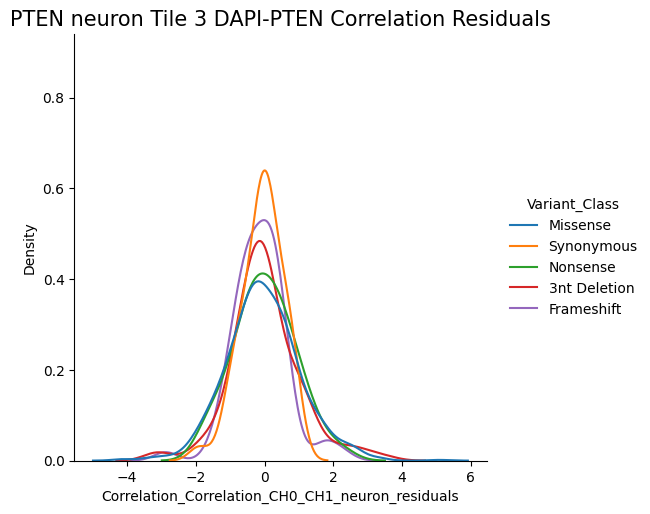

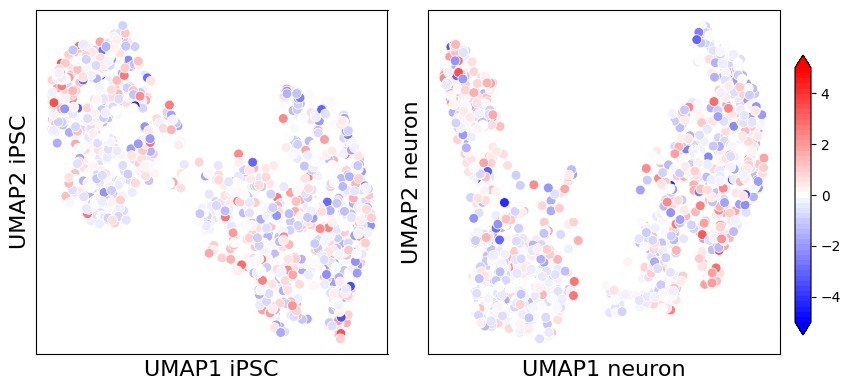

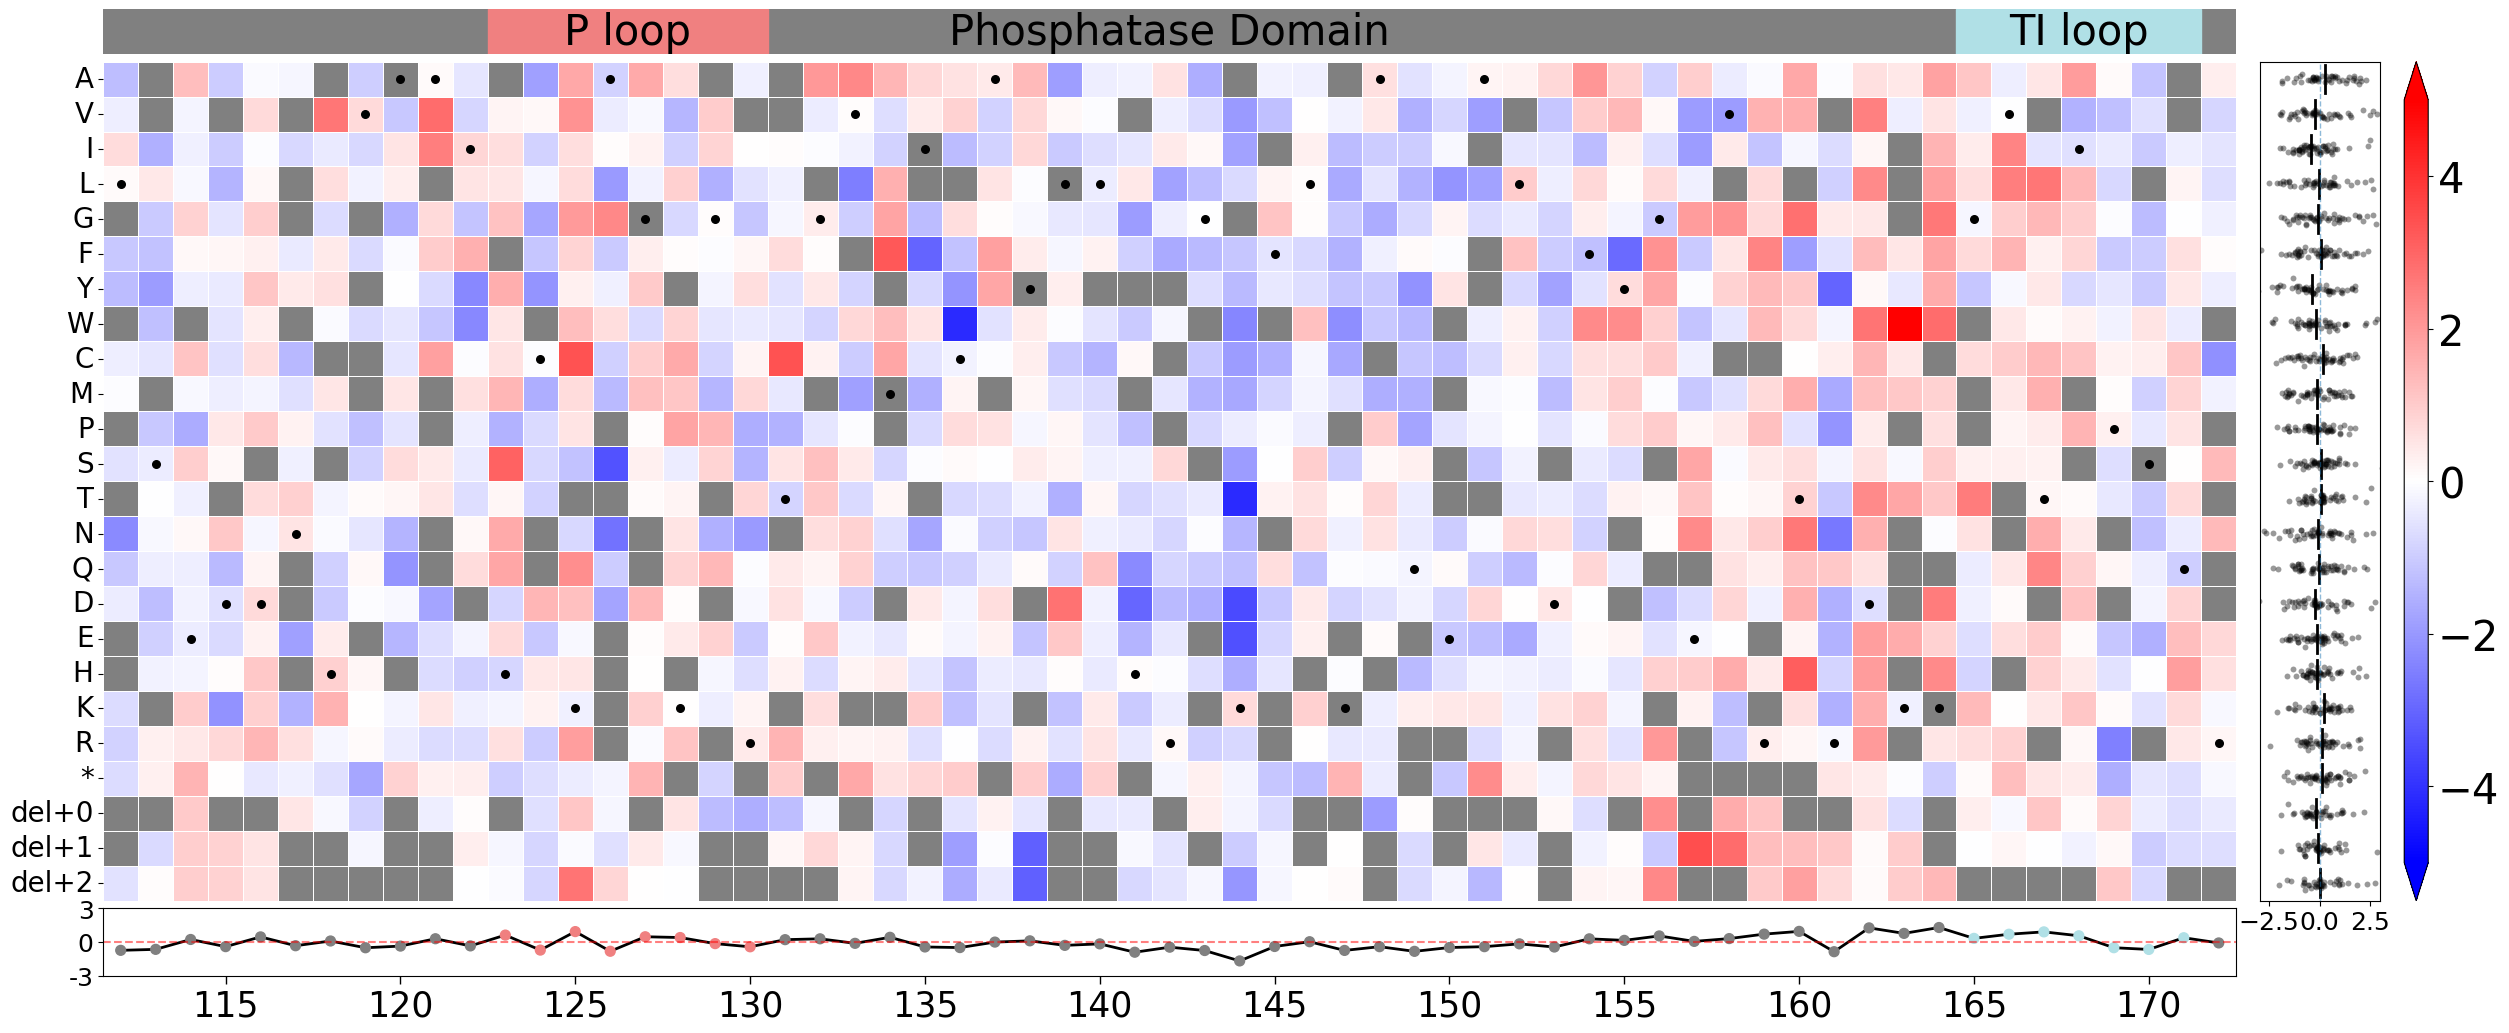

In [ ]:
# Regression of DAPI-PTEN Correlation against activity and abundance in neurons
# Set columns to regress
y_col = "Correlation_Correlation_CH0_CH1_neuron"
feature_cols = [
    #"Intensity_MeanIntensity_CH0_neuron",
    "Intensity_MeanIntensity_CH1_neuron",
    "Intensity_MeanIntensity_CH3_Corrected_neuron"
]

# Plot on UMAP and heatmap
feature_to_heatmap = "Correlation_Correlation_CH0_CH1_neuron_residuals"
addtl_features_df[feature_to_heatmap] = \
    krr_on_rawfeatures(
        addtl_features_df,
        xcols=feature_cols,
        ycol=y_col,
        pre_syn_zscore=False)
localization_residual_scores,pymol_command = \
    plot_feature(addtl_features_df,
                 umap_coords,
                 feature_to_heatmap,
                 "PTEN neuron Tile 3 DAPI-PTEN Correlation Residuals",
                 "PTENT3.neuron.DAPIPTENcorrelationresiduals",
                 dis_path='./consensus_plots_postreview/distributions/',
                 heatmap_path='./consensus_plots_postreview/heatmap/',
                 umap_path='./consensus_plots_postreview/umap/',
                 pdb_path='./consensus_plots_postreview/pdb/',
                 highlight_variants=False,
                 pdb_plot=True,
                 save_plots=False,
                 show_plots=True,
                 threentdels=True,
                 syn_zscore=False,
                 domain_map=PTEN_domain_map,
                 domain_colors=PTEN_domain_coloring,
                 extra_pymol="show sticks, sele; show surface, sele; set transparency=0.5; color green, resi 1352\n",
                 umap1_col=['UMAP1 iPSC','UMAP1 neuron'],
                 umap2_col=['UMAP2 iPSC','UMAP2 neuron'],
                 vmin=-5,
                 vmax=5,
                 pymol_view=pymol_ptenview3,
                 image_size=(4000,3000),
                 input_pdb="../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/1d5r.pdb"
                )
#!{pymol_command}


In [63]:
# Look at association between abundance/activity and scans
# abundance
mergedtoVAMPseq_toplot = \
    variant_medians_merged.copy()
mergedtoVAMPseq_toplot = \
    mergedtoVAMPseq_toplot\
        .merge(abundance_HEK_data[['variant','score_total']]\
                   .query('~score_total.isna()'),
               left_on='Variant', 
               right_on='variant',
               how='inner')

fig,axs=plt.subplots(figsize=(10,5), ncols=2, sharey=True)
# Call the scatter_with_regression function for iPSC
scatter_with_regression(
    ax=axs[0],
    data=mergedtoVAMPseq_toplot.sort_values(by='Variant_Class'),
    x='Intensity_MeanIntensity_CH1_iPSC',
    y='score_total',
    hue='Variant_Class',
    palette=variant_type_palette,
    x_label='iPSC PTEN Mean Abundance',
    y_label='VAMPseq Score',  # only put y_label on left subplot
    legend=False,  # you can set this True if you want a legend
    show_line=False
)

# Call the scatter_with_regression function for Neuron
scatter_with_regression(
    ax=axs[1],
    data=mergedtoVAMPseq_toplot.sort_values(by='Variant_Class'),
    x='Intensity_MeanIntensity_CH1_neuron',
    y='score_total',
    hue='Variant_Class',
    palette=variant_type_palette,
    x_label='Neuron PTEN Mean Abundance',
    y_label=None,  # sharey=True handles the scale, and label not needed
    legend=False,
    show_line=False,
)
#plt.tight_layout()
plt.close()
fig.savefig('./consensus_plots_postreview/PTENT3.VAMPseqcorrelation.011825.pdf')

# activity
mergedtoactivity_toplot = \
    variant_medians_merged.copy()
mergedtoactivity_toplot = \
    mergedtoactivity_toplot\
        .merge(activity_yeast_data[['Variant (one letter)','Cum_score']]\
                   .query('~Cum_score.isna()'),
               left_on='Variant', 
               right_on='Variant (one letter)',
               how='inner')

fig,axs=plt.subplots(figsize=(10,5), ncols=2, sharey=True)
# Call the scatter_with_regression function for iPSC (activity)
scatter_with_regression(
    ax=axs[0],
    data=mergedtoactivity_toplot.sort_values(by='Variant_Class'),
    x='Intensity_MeanIntensity_CH3_Corrected_iPSC',
    y='Cum_score',
    hue='Variant_Class',
    palette=variant_type_palette,
    x_label='iPSC PTEN Mean pAKT',
    y_label='Yeast Fitness Score',
    legend=False,
    r_xloc=0.5,
    r_yloc=0.9,
    show_line=False,
)

# Call the scatter_with_regression function for Neuron (activity)
scatter_with_regression(
    ax=axs[1],
    data=mergedtoactivity_toplot.sort_values(by='Variant_Class'),
    x='Intensity_MeanIntensity_CH3_Corrected_neuron',
    y='Cum_score',
    hue='Variant_Class',
    palette=variant_type_palette,
    x_label='Neuron PTEN Mean pAKT',
    y_label=None,
    legend=False,
    r_xloc=0.5,
    r_yloc=0.9,
    show_line=False,
)
#plt.tight_layout()
plt.close()
fig.savefig('./consensus_plots_postreview/PTENT3.Yeastphosphatasecorrelation.011825.pdf')


In [64]:
# Plot iPS vs neuron MIS
fig,ax=plt.subplots(figsize=(5,4.5))
scatter_with_regression(
    ax=ax,
    data=df_profiles_merged.sort_values(by='Variant_Class'),
    x='Morphological Impact Score iPSC',
    y='Morphological Impact Score neuron',
    hue='Variant_Class',
    palette=variant_type_palette,
    x_label='iPSC Impact Score',
    y_label='Neuron Impact Score',
    legend=False,
    r_xloc=0.68,
    r_yloc=0.92,
    show_line=False
)
plt.xlim(0,1)
plt.ylim(0,1)
#plt.legend(markerscale=2, bbox_to_anchor=(1,1), loc='upper left', title='Variant Type', title_fontsize=16, fontsize=12)
plt.xlabel('iPSC Impact Score', fontsize=16)
plt.ylabel('Neuron Impact Score', fontsize=16)
plt.tight_layout()
plt.close()
fig.savefig('./consensus_plots_postreview/morphological_impact.iPSCvsneuron.032825.pdf', dpi=600)


In [65]:
# Plot iPS vs neuron AUC ROC
# Add in ROC AUC scores
df_profiles_withROCAUC = \
    df_profiles_merged\
        .merge(roc_auc_pten_ipsc,   on='Variant', how='inner')\
        .merge(roc_auc_pten_neuron, on='Variant', how='inner')

fig,ax=plt.subplots(figsize=(5,4.5))
scatter_with_regression(
    ax=ax,
    data=df_profiles_withROCAUC.sort_values(by='Variant_Class'),
    x='AUC ROC iPSC',
    y='AUC ROC neuron',
    hue='Variant_Class',
    palette=variant_type_palette,
    x_label='AUC ROC iPSC',
    y_label='AUC ROC neuron',
    legend=False,
    r_xloc=0.68,
    r_yloc=0.92,
    show_line=False
)
plt.xlim(0.4,1)
plt.ylim(0.4,1)
#plt.legend(markerscale=2, bbox_to_anchor=(1,1), loc='upper left', title='Variant Type', title_fontsize=16, fontsize=12)
plt.xlabel('iPSC Distinguishability Score', fontsize=16)
plt.ylabel('Neuron Distinguishability Score', fontsize=16)
plt.tight_layout()
plt.close()
fig.savefig('./consensus_plots_postreview/auc_roc.iPSCvsneuron.032825.pdf', dpi=600)


In [66]:
# Plot impact as a function of aa to
aliphatic = ["A", "V", "I", "L", "G"]
aromatic = ["F", "Y", "W"]
nonpolar = ["C", "M", "P"]
polar = ["S", "T", "N", "Q"]
acidic = ["D", "E"]
basic = ["H", "K", "R"]
aa_type = aliphatic+aromatic+nonpolar+polar+acidic+basic
palette_aato={}
palette_aato['Syn']='green'
for t in aliphatic:
    palette_aato[t]='tan'
for t in aromatic:
    palette_aato[t]='darkorange'
for t in nonpolar:
    palette_aato[t]='gold'
for t in polar:
    palette_aato[t]='cyan'
for t in acidic:
    palette_aato[t]='red'
for t in basic:
    palette_aato[t]='cornflowerblue'

df_toplot = df_profiles_merged.query('Variant_Class in ["Synonymous","Missense"]').copy()
df_toplot['AA To'] = \
    df_toplot\
        .apply(lambda row: 'Syn' if row['Variant_Class']=='Synonymous' else row['Variant'][-1],axis=1)
fig, axs = plt.subplots(figsize=(12,4),ncols=2)
boxplot_with_significance(
    df=df_toplot,
    x_col='AA To',
    y_col='Morphological Impact Score iPSC',
    hue_col='AA To',  # same as x_col
    order=['Syn']+aa_type,
    alpha=0.001,    # Show significance if p < 0.001
    pairs=[("Syn",t) for t in aa_type],
    palette=palette_aato,
    offset=0.002,
    ax=axs[0],
    anno_sample_sizes=False,
    show_points=True
)
axs[0].set_ylim(0, 1)

boxplot_with_significance(
    df=df_toplot,
    x_col='AA To',
    y_col='Morphological Impact Score neuron',
    hue_col='AA To',  # same as x_col
    order=['Syn']+aa_type,
    alpha=0.001,    # Show significance if p < 0.001
    pairs=[("Syn",t) for t in aa_type],
    palette=palette_aato,
    offset=0.002,
    ax=axs[1],
    anno_sample_sizes=False,
    show_points=True
)
axs[1].set_ylim(0, 1)

# Labels
axs[0].set_ylabel("iPSC Impact Score", fontsize=16)
axs[0].set_xlabel("AA To", fontsize=16)
axs[1].set_ylabel("Neuron Impact Score", fontsize=16)
axs[1].set_xlabel("AA To", fontsize=16)

# Font size
axs[0].tick_params(axis='both',labelsize=12)
axs[1].tick_params(axis='both',labelsize=12)

plt.tight_layout()
plt.close()
fig.savefig('./consensus_plots_postreview/morphological_impact.aato.011525.pdf', dpi=600)


In [67]:
# Plot AUC as a function of aa to
df_toplot = df_profiles_withROCAUC.query('Variant_Class in ["Synonymous","Missense"]').copy()
df_toplot['AA To'] = \
    df_toplot\
        .apply(lambda row: 'Syn' if row['Variant_Class']=='Synonymous' else row['Variant'][-1],axis=1)
fig, axs = plt.subplots(figsize=(12,4),ncols=2)
boxplot_with_significance(
    df=df_toplot,
    x_col='AA To',
    y_col='AUC ROC iPSC',
    hue_col='AA To',  # same as x_col
    order=['Syn']+aa_type,
    alpha=0.001,    # Show significance if p < 0.001
    pairs=[("Syn",t) for t in aa_type],
    palette=palette_aato,
    offset=0.002,
    ax=axs[0],
    anno_sample_sizes=False,
    show_points=True
    
)
axs[0].set_ylim(0.45, 1)

boxplot_with_significance(
    df=df_toplot,
    x_col='AA To',
    y_col='AUC ROC neuron',
    hue_col='AA To',  # same as x_col
    order=['Syn']+aa_type,
    alpha=0.001,    # Show significance if p < 0.001
    pairs=[("Syn",t) for t in aa_type],
    palette=palette_aato,
    offset=0.002,
    ax=axs[1],
    anno_sample_sizes=False,
    show_points=True
)
axs[1].set_ylim(0.45, 1)

# Labels
axs[0].set_ylabel("iPSC Distinguishability Score", fontsize=16)
axs[0].set_xlabel("AA To", fontsize=16)
axs[1].set_ylabel("Neuron Distinguishability Score", fontsize=16)
axs[1].set_xlabel("AA To", fontsize=16)

# Font size
axs[0].tick_params(axis='both',labelsize=12)
axs[1].tick_params(axis='both',labelsize=12)

plt.tight_layout()
plt.close()
fig.savefig('./consensus_plots_postreview/auc_roc.aato.011525.pdf', dpi=600)


In [68]:
# Plot AUC as a function of class
df_toplot = df_profiles_withROCAUC.copy()
df_toplot['Variant Type'] = \
    df_toplot['Variant_Class']
# add on wt sample controls
wt_controls_name = 'WT\nSamples'
roc_auc_pten_ipsc_controls['Variant Type'] = wt_controls_name
df_toplot_pluscontrols_iPSC = \
    pd.concat([df_toplot[['Variant','Morphological Impact Score iPSC','Variant Type']], roc_auc_pten_ipsc_controls]).reset_index()
roc_auc_pten_neuron_controls['Variant Type'] = wt_controls_name
df_toplot_pluscontrols_neuron = \
    pd.concat([df_toplot[['Variant','Morphological Impact Score neuron','Variant Type']], roc_auc_pten_neuron_controls]).reset_index()

col_order = [wt_controls_name, 'Synonymous','Missense','3nt Deletion','Nonsense','Frameshift']
col_labels = [wt_controls_name, 'Synon','Missense','3nt\nDel','Non-\nsense','Frame-\nshift']
variant_type_palette_toplot = \
    variant_type_palette.copy()
variant_type_palette_toplot[wt_controls_name] = 'palegreen'

fig, axs = plt.subplots(figsize=(8,4),ncols=2)
boxplot_with_significance(
    df=df_toplot_pluscontrols_iPSC,
    x_col='Variant Type',
    y_col='Morphological Impact Score iPSC',
    hue_col='Variant Type',  # same as x_col
    order=col_order,
    palette=variant_type_palette_toplot,
    alpha=0.001,    # Show significance if p < 0.001
    pairs=[("Synonymous",s) for s in col_order[1:] if s!='Synonymous']+\
            [("Missense",s) for s in col_order[1:] if s not in ["Synonymous","Missense"]],
    offset=0.005,
    ax=axs[0],
    anno_sample_sizes=True,
    xlabels=col_labels,
    show_points=True
)

boxplot_with_significance(
    df=df_toplot_pluscontrols_neuron,
    x_col='Variant Type',
    y_col='Morphological Impact Score neuron',
    hue_col='Variant Type',  # same as x_col
    order=col_order,
    palette=variant_type_palette_toplot,
    alpha=0.001,    # Show significance if p < 0.001
    pairs=[("Synonymous",s) for s in col_order[1:] if s!='Synonymous']+\
            [("Missense",s) for s in col_order[1:] if s not in ["Synonymous","Missense"]],
    offset=0.005,
    ax=axs[1],
    anno_sample_sizes=True,
    xlabels=col_labels,
    show_points=True
)

# Labels
axs[0].set_ylabel("iPSC Impact Score", fontsize=14)
axs[0].set_xlabel("", fontsize=14)
axs[1].set_ylabel("Neuron Impact Score", fontsize=14)
axs[1].set_xlabel("", fontsize=14)

# Font size
axs[0].tick_params(axis='both',labelsize=11)
axs[1].tick_params(axis='both',labelsize=11)

plt.tight_layout()
plt.close()
fig.savefig('./consensus_plots_postreview/morphological_impact_score.variant_class.011525.pdf', dpi=600)


In [69]:
# Plot AUC as a function of class
df_toplot = df_profiles_withROCAUC.copy()
df_toplot['Variant Type'] = \
    df_toplot['Variant_Class']
# add on wt sample controls
wt_controls_name = 'WT\nSamples'
roc_auc_pten_ipsc_controls['Variant Type'] = wt_controls_name
df_toplot_pluscontrols_iPSC = \
    pd.concat([df_toplot[['Variant','AUC ROC iPSC','Variant Type']], roc_auc_pten_ipsc_controls]).reset_index()
roc_auc_pten_neuron_controls['Variant Type'] = wt_controls_name
df_toplot_pluscontrols_neuron = \
    pd.concat([df_toplot[['Variant','AUC ROC neuron','Variant Type']], roc_auc_pten_neuron_controls]).reset_index()

col_order = [wt_controls_name, 'Synonymous','Missense','3nt Deletion','Nonsense','Frameshift']
col_labels = [wt_controls_name, 'Synon','Missense','3nt\nDel','Non-\nsense','Frame-\nshift']
variant_type_palette_toplot = \
    variant_type_palette.copy()
variant_type_palette_toplot[wt_controls_name] = 'palegreen'

fig, axs = plt.subplots(figsize=(9.5,4),ncols=2)
boxplot_with_significance(
    df=df_toplot_pluscontrols_iPSC,
    x_col='Variant Type',
    y_col='AUC ROC iPSC',
    hue_col='Variant Type',  # same as x_col
    order=col_order,
    palette=variant_type_palette_toplot,
    alpha=0.001,    # Show significance if p < 0.001
    pairs=[("Synonymous",s) for s in col_order[1:] if s!='Synonymous']+\
            [("Missense",s) for s in col_order[1:] if s not in ["Synonymous","Missense"]],
    offset=0.005,
    ax=axs[0],
    anno_sample_sizes=True,
    xlabels=col_labels,
    show_points=True
)
axs[0].set_ylim(0.4, 1)

boxplot_with_significance(
    df=df_toplot_pluscontrols_neuron,
    x_col='Variant Type',
    y_col='AUC ROC neuron',
    hue_col='Variant Type',  # same as x_col
    order=col_order,
    palette=variant_type_palette_toplot,
    alpha=0.001,    # Show significance if p < 0.001
    pairs=[("Synonymous",s) for s in col_order[1:] if s!='Synonymous']+\
            [("Missense",s) for s in col_order[1:] if s not in ["Synonymous","Missense"]],
    offset=0.005,
    ax=axs[1],
    anno_sample_sizes=True,
    xlabels=col_labels,
    show_points=True
)
axs[1].set_ylim(0.4, 1)

# Labels
axs[0].set_ylabel("iPSC Distinguishability Score", fontsize=14)
axs[0].set_xlabel("", fontsize=14)
axs[1].set_ylabel("Neuron Distinguishability Score", fontsize=14)
axs[1].set_xlabel("", fontsize=14)

# Font size
axs[0].tick_params(axis='both',labelsize=11)
axs[1].tick_params(axis='both',labelsize=11)

plt.tight_layout()
plt.close()
fig.savefig('./consensus_plots_postreview/auc_roc.variant_class.011525.pdf', dpi=600)


In [70]:
# Look at PTEN variants in ClinVar
df_toplot = pd.merge(df_profiles_merged, 
                     clinvar_variants_annotated_PTENT3_splicefilt\
                         [['Variant','Clinvar label']],
                     on='Variant', 
                     how='inner')
df_toplot2 = pd.concat([
                        df_toplot,
                        df_profiles_merged.query('Variant_Class == "Synonymous"').assign(**{'Clinvar label':'Synon'})
                       ])
df_toplot2 = \
    df_toplot2.rename(columns={'Clinvar label':'ClinVAR Label'})

fig, axs = plt.subplots(figsize=(8,4),ncols=2)
boxplot_with_significance(
    df=df_toplot2,
    x_col='ClinVAR Label',
    y_col='Morphological Impact Score iPSC',
    hue_col='ClinVAR Label',  # same as x_col
    order=['Synon','LB','VUS','LP','P'],
    palette={'Synon':'darkgreen','VUS':'yellow','LP':'red','P':'darkred','LB':'blue'},
    alpha=0.001,    # Show significance if p < 0.001
    pairs=[("Synon","LP"),
           ("Synon","P"),
           ("LB","LP"),
           ("LB","P")],
    offset=0.02,
    ax=axs[0],
    show_points=True
)
axs[0].set_ylim(0, 1)

boxplot_with_significance(
    df=df_toplot2,
    x_col='ClinVAR Label',
    y_col='Morphological Impact Score neuron',
    hue_col='ClinVAR Label',  # same as x_col
    order=['Synon','LB','VUS','LP','P'],
    palette={'Synon':'darkgreen','VUS':'yellow','LP':'red','P':'darkred','LB':'blue'},
    alpha=0.001,    # Show significance if p < 0.001
    pairs=[("Synon","LP"),
           ("Synon","P"),
           ("LB","LP"),
           ("LB","P")],
    offset=0.02,
    ax=axs[1],
    show_points=True
)

axs[1].set_ylim(0, 1)

# Labels
axs[0].set_ylabel("iPSC Impact Score", fontsize=14)
axs[1].set_ylabel("Neuron Impact Score", fontsize=14)

# Font size
axs[0].tick_params(axis='both',labelsize=12)
axs[1].tick_params(axis='both',labelsize=12)
axs[0].set_xlabel("")
axs[1].set_xlabel("")

plt.tight_layout()
plt.close()
fig.savefig('./consensus_plots_postreview/morphological_impact.clinvar.011525.pdf', dpi=600)


In [71]:
# Look at PTEN variants in ClinVar
df_toplot = pd.merge(df_profiles_merged, 
                     clinvar_variants_annotated_PTENT3_splicefilt\
                         [['Variant','Clinvar label']],
                     on='Variant', 
                     how='inner')
df_toplot2 = pd.concat([
                        df_toplot,
                        df_profiles_merged.query('Variant_Class == "Synonymous"').assign(**{'Clinvar label':'Synon'})
                       ])
df_toplot2 = \
    df_toplot2.rename(columns={'Clinvar label':'ClinVAR Label'})
df_toplot2 = \
    df_toplot2.merge(roc_auc_pten_ipsc,on='Variant',how='inner').merge(roc_auc_pten_neuron,on='Variant',how='inner')

fig, axs = plt.subplots(figsize=(8,4),ncols=2)
boxplot_with_significance(
    df=df_toplot2,
    x_col='ClinVAR Label',
    y_col='AUC ROC iPSC',
    hue_col='ClinVAR Label',  # same as x_col
    order=['Synon','LB','VUS','LP','P'],
    palette={'Synon':'darkgreen','VUS':'yellow','LP':'red','P':'darkred','LB':'blue'},
    alpha=0.001,    # Show significance if p < 0.001
    pairs=[("Synon","LP"),
           ("Synon","P"),
           ("LB","LP"),
           ("LB","P")],
    offset=0.015,
    ax=axs[0],
    show_points=True
)
axs[0].set_ylim(0.45, 1)

boxplot_with_significance(
    df=df_toplot2,
    x_col='ClinVAR Label',
    y_col='AUC ROC neuron',
    hue_col='ClinVAR Label',  # same as x_col
    order=['Synon','LB','VUS','LP','P'],
    palette={'Synon':'darkgreen','VUS':'yellow','LP':'red','P':'darkred','LB':'blue'},
    alpha=0.001,    # Show significance if p < 0.001
    pairs=[("Synon","LP"),
           ("Synon","P"),
           ("LB","LP"),
           ("LB","P")],
    offset=0.015,
    ax=axs[1],
    show_points=True
)

axs[1].set_ylim(0.45, 1)

# Labels
axs[0].set_ylabel("iPSC Distinguishability Score", fontsize=14)
axs[1].set_ylabel("Neuron Distinguishability Score", fontsize=14)
axs[0].set_xlabel("")
axs[1].set_xlabel("")

# Font size
axs[0].tick_params(axis='both',labelsize=12)
axs[1].tick_params(axis='both',labelsize=12)

plt.tight_layout()
plt.close()
fig.savefig('./consensus_plots_postreview/auc_roc.clinvar.011525.pdf', dpi=600)


In [72]:
# A) helper to convert three-letter → one-letter (e.g. "Tyr88Phe" → "Y88F")
aa_map = {
    'Ala':'A','Arg':'R','Asn':'N','Asp':'D','Cys':'C',
    'Glu':'E','Gln':'Q','Gly':'G','His':'H','Ile':'I',
    'Leu':'L','Lys':'K','Met':'M','Phe':'F','Pro':'P',
    'Ser':'S','Thr':'T','Trp':'W','Tyr':'Y','Val':'V'
}
def to_short(hgvs):
    m = re.match(r'^p\.?([A-Za-z]{3})(\d+)([A-Za-z]{3})$', hgvs)
    if not m:
        return None
    return f"{aa_map[m.group(1)]}{m.group(2)}{aa_map[m.group(3)]}"

def assign_category_all_disease(row, diseases=['PHTS','ASD/DD','Somatic\nCancer']):
    if row['Variant_Class'] == 'Synonymous':
        return 'Synon'
    elif row['HasDisease'] is True:
        if row['Disease'] in diseases:
            return f"All\n{row['Disease']}"
        else:
            return row['Disease']
    else:
        return None

def assign_category_only_disease(row, diseases=['PHTS','ASD/DD','Somatic\nCancer']):
    if row['Variant_Class'] == 'Synonymous':
        return 'Synon'
    if row['num_diseases'] == 1 and row['HasDisease'] is True:
        disease_not = [d for d in diseases if d != row['Disease']][0]
        return f"{row['Disease']}\nonly"

def assign_category_both_disease(row, diseases=['PHTS','ASD/DD','Somatic\nCancer']):
    if row['Variant_Class'] == 'Synonymous':
        return 'Synon'
    if row['num_diseases'] == 2 and row['HasDisease'] is True:
        return f"{diseases[0]}\nand\n{diseases[1]}"
    return None

# --- 1a) gnomAD controls (short form already in your df) ★---
gnomad_set = set(gnomad_PTEN_filt_df['Variant'])

# --- 1b) COSMIC positives (convert to 'Y88F' style) ★---
cosmic_set = \
    cosmic_variants_pten_missense_t3_splicefilt\
        .query('Count >= @somatic_cancer_count_filter')['Variant']
cosmic_set = set(cosmic_set.dropna())

# --- 2) Merge morphology → phenotype fractions (same as before) ---
df_AM_anno = (
    df_profiles_merged
      .merge(pten_variantbyphenotype_AM_splicefilt, on='Variant', how='left')
      .merge(roc_auc_pten_ipsc,   on='Variant', how='left')
      .merge(roc_auc_pten_neuron, on='Variant', how='left')
)

# ★ add gnomAD & COSMIC flags
df_AM_anno['gnomAD']  = df_AM_anno['Variant'].isin(gnomad_set)
df_AM_anno['Somatic\nCancer']  = df_AM_anno['Variant'].isin(cosmic_set)

# --- 2b) threshold your phenos as before ---
phenos    = ['PHTS','ASD/DD']
threshold = 0.01
for p in phenos:
    df_AM_anno[p] = df_AM_anno[p] >= threshold # any association

# --- 3) count diseases (gnomAD/COSMIC not included) ----
df_AM_anno['num_diseases'] = df_AM_anno[phenos].sum(axis=1)

# --- 4) melt **including** gnomAD & COSMIC ★ ---
df_melt = df_AM_anno.melt(
    id_vars=['Variant',
             'Morphological Impact Score iPSC',
             'Morphological Impact Score neuron',
             'AUC ROC iPSC',
             'AUC ROC neuron',
             'Variant_Class',
             'num_diseases'],
    value_vars=phenos + ['gnomAD','Somatic\nCancer'],
    var_name='Disease',
    value_name='HasDisease'
)

# --- 5) assign categories exactly as before (COSMIC comes through in the “all” set) ---
df_melt['Category'] = df_melt.apply(assign_category_all_disease, axis=1)
df_melt2 = df_melt[~df_melt['Category'].isin(["Synon","gnomAD","All\nSomatic\nCancer"])].query('num_diseases == 1').copy()
df_melt2['Category'] = df_melt2.apply(assign_category_only_disease, axis=1)
df_melt5 = df_melt[~df_melt['Category'].isin(["Synon","gnomAD","All\nSomatic\nCancer"])].query('num_diseases == 2').copy()
df_melt5['Category'] = df_melt5.apply(assign_category_both_disease, axis=1)

# pull back just the gnomAD/COSMIC rows if you need them separately
df_melt7 = df_melt[df_melt['Category'].isin(["gnomAD","All\nSomatic\nCancer"])]

# drop Nones
df_melt  = df_melt.dropna(subset=['Category'])
df_melt2 = df_melt2.dropna(subset=['Category'])
df_melt5 = df_melt5.dropna(subset=['Category'])

# --- 6) combine and dedupe ★---
df_melt3 = pd.concat([df_melt, df_melt2, df_melt5], ignore_index=True)
df_melt3 = df_melt3.drop_duplicates(subset=['Variant','Category'])
df_melt6 = pd.concat([df_melt7, df_melt2, df_melt5], ignore_index=True)
df_melt6 = df_melt6.drop_duplicates(subset=['Variant','Category'])

# --- 7) rename & set order & palette ★---
df_melt3['Category'] = df_melt3['Category'].replace({'Synonymous':'Synon'})

category_order = [
    'Synon',      # 1) synonyms
    'gnomAD',     # 2) controls from gnomAD
    'All\nPHTS',
    'PHTS\nonly',
    'All\nASD/DD',
    'ASD/DD\nonly',
    'PHTS\nand\nASD/DD',
    'All\nSomatic\nCancer',
]

category_palette = \
    {
     'Synon':'green',
     'ASD/DD\nonly':'gold',
     'All\nASD/DD':'#F9E980',
     'PHTS\nonly':'magenta',
     'All\nPHTS':'violet',
     'PHTS\nand\nASD/DD':'pink',
     'All\nSomatic\nCancer':'cyan',
     'Somatic\nCancer only':'darkcyan',
     'gnomAD':'powderblue'
    }

# --- 8) filter tiny bins if you want  ---
min_count = 5
valid = df_melt3['Category'].value_counts().loc[lambda s: s>=min_count].index
category_order = [c for c in category_order if c in valid]

# --- 9) rebuild your pairwise tests ★---
pairs_totest = []
for base in category_order:
    if base!='Synon':
        pairs_totest.append(('Synon', base))
    if base!='gnomAD':
        pairs_totest.append(('gnomAD', base))
    # compare COSMIC to diseases:
    if base not in ['Synon','gnomAD','Somatic\nCancer']:
        pairs_totest.append(('Somatic\nCancer', base))

# --- 10) plot as before ---
fig, axs = plt.subplots(figsize=(11.5,4), ncols=2)

boxplot_with_significance(
    df=df_melt3,
    x_col='Category',
    y_col='Morphological Impact Score iPSC',
    hue_col='Category',
    order=category_order,
    palette=category_palette,
    alpha=0.001,
    pairs=pairs_totest,
    offset=0.01,
    ax=axs[0],
    show_points=True
)
axs[0].set_ylim(0,1)
axs[0].set_xlabel("", fontsize=16)
axs[0].set_ylabel("iPSC Impact Score", fontsize=14)
axs[0].tick_params(labelsize=10)

boxplot_with_significance(
    df=df_melt3,
    x_col='Category',
    y_col='Morphological Impact Score neuron',
    hue_col='Category',
    order=category_order,
    palette=category_palette,
    alpha=0.001,
    pairs=pairs_totest,
    offset=0.01,
    ax=axs[1],
    show_points=True
)
axs[1].set_ylim(0,1)
axs[1].set_xlabel("", fontsize=14)
axs[1].set_ylabel("Neuron Impact Score", fontsize=14)
axs[1].tick_params(labelsize=10)

plt.tight_layout()
plt.close()
fig.savefig('./consensus_plots_postreview/morphological_impact.with_gnomad_COSMIC.pdf', dpi=600)


In [73]:
# Plot AUC ROC 
fig, axs = plt.subplots(figsize=(11.5,4), ncols=2)

boxplot_with_significance(
    df=df_melt3,
    x_col='Category',
    y_col='AUC ROC iPSC',
    hue_col='Category',
    order=category_order,
    palette=category_palette,
    alpha=0.001,
    pairs=pairs_totest,
    offset=0.005,
    ax=axs[0],
    show_points=True
)
axs[0].set_ylim(0.45,1)
axs[0].set_xlabel("", fontsize=14)
axs[0].set_ylabel("iPSC Distinguishability Score", fontsize=14)
axs[0].tick_params(labelsize=10)

boxplot_with_significance(
    df=df_melt3,
    x_col='Category',
    y_col='AUC ROC neuron',
    hue_col='Category',
    order=category_order,
    palette=category_palette,
    alpha=0.001,
    pairs=pairs_totest,
    offset=0.005,
    ax=axs[1],
    show_points=True
)
axs[1].set_ylim(0.45,1)
axs[1].set_xlabel("", fontsize=14)
axs[1].set_ylabel("Neuron Distinguishability Score", fontsize=14)
axs[1].tick_params(labelsize=10)

plt.tight_layout()
plt.close()
fig.savefig('./consensus_plots_postreview/auc_roc.with_gnomad_COSMIC.052725.pdf', dpi=600)


In [74]:
# How do variants compare on features?
df_melt4 = \
    df_melt3\
        .merge(addtl_features_df,
               on='Variant')

# Plot
fig, axs = plt.subplots(figsize=(17,4),ncols=3)
boxplot_with_significance(
    df=df_melt4,
    x_col='Category',
    y_col='Intensity_MeanIntensity_CH1_iPSC',
    hue_col='Category',  # same as x_col
    order=category_order,
    palette=category_palette,
    alpha=0.001,    # Show significance if p < 0.001
    pairs=pairs_totest,
    offset=0.02,
    ax=axs[0],
    show_points=True
)
axs[0].set_ylim(-10, 4)
axs[0].set_ylabel('iPSC PTEN Abundance', fontsize=14)

boxplot_with_significance(
    df=df_melt4,
    x_col='Category',
    y_col='Intensity_MeanIntensity_CH3_Corrected_iPSC',
    hue_col='Category',  # same as x_col
    order=category_order,
    palette=category_palette,
    alpha=0.001,    # Show significance if p < 0.001
    pairs=pairs_totest,
    offset=0.02,
    ax=axs[1],
    show_points=True
)
axs[1].set_ylim(-4, 22)
axs[1].set_ylabel('iPSC pAKT', fontsize=14)

boxplot_with_significance(
    df=df_melt4,
    x_col='Category',
    y_col='Correlation_Correlation_CH0_CH1_iPSC_residuals',
    hue_col='Category',  # same as x_col
    order=category_order,
    palette=category_palette,
    alpha=0.01,    # Show significance if p < 0.001,
    pairs=pairs_totest,
    shared_label='**',
    offset=0.01,
    ax=axs[2],
    show_points=True
)
axs[2].set_ylim(-10,9)
axs[2].set_ylabel('iPSC Mislocalization Score', fontsize=14)

# Labels
axs[0].set_xlabel("", fontsize=16)
axs[1].set_xlabel("", fontsize=16)
axs[2].set_xlabel("", fontsize=16)

# Font size
axs[0].tick_params(axis='both',labelsize=10)
axs[1].tick_params(axis='both',labelsize=10)
axs[2].tick_params(axis='both',labelsize=10)

plt.tight_layout()
plt.close()
fig.savefig('./consensus_plots_postreview/landmarkfeatures.iPSC.disease.051325.pdf', dpi=600)


In [76]:
# How do variants compare on features?
# Plot
fig, axs = plt.subplots(figsize=(11,4),ncols=2)
boxplot_with_significance(
    df=df_melt4,
    x_col='Category',
    y_col='Correlation_Correlation_CH0_CH1_iPSC',
    hue_col='Category',  # same as x_col
    order=category_order,
    palette=category_palette,
    alpha=0.01,    # Show significance if p < 0.001,
    shared_label="**",
    offset=0.01,
    ax=axs[0],
    show_points=True
)
axs[0].set_ylim(-20, 25)
axs[0].set_ylabel('iPSC DAPI-PTEN Correlation', fontsize=14)

boxplot_with_significance(
    df=df_melt4,
    x_col='Category',
    y_col='Nuc/Cyto_Intensity_CH1_iPSC',
    hue_col='Category',  # same as x_col
    order=category_order,
    palette=category_palette,
    alpha=0.01,    # Show significance if p < 0.001,
    shared_label="**",
    offset=0.01,
    ax=axs[1],
    show_points=True
)
axs[1].set_ylim(-15, 15)
axs[1].set_ylabel('iPSC PTEN Nuc/Cyto', fontsize=14)

# Labels
axs[0].set_xlabel("", fontsize=16)
axs[1].set_xlabel("", fontsize=16)

# Font size
axs[0].tick_params(axis='both',labelsize=10)
axs[1].tick_params(axis='both',labelsize=10)

plt.tight_layout()
plt.close()
fig.savefig('./consensus_plots_postreview/landmarkfeatures2.iPSC.disease.051325.pdf', dpi=600)


In [77]:
# How do variants compare on features?
df_melt4 = \
    df_melt3\
        .merge(addtl_features_df[['Variant',
                                  'Intensity_MeanIntensity_CH1_neuron',
                                  'Intensity_MeanIntensity_CH3_Corrected_neuron',
                                  'Correlation_Correlation_CH0_CH1_neuron',
                                  'Correlation_Correlation_CH0_CH1_neuron_residuals']],
               on='Variant')

# Plot
fig, axs = plt.subplots(figsize=(17,4),ncols=3)
boxplot_with_significance(
    df=df_melt4,
    x_col='Category',
    y_col='Intensity_MeanIntensity_CH1_neuron',
    hue_col='Category',  # same as x_col
    order=category_order,
    palette=category_palette,
    alpha=0.001,    # Show significance if p < 0.001
    pairs=pairs_totest,
    offset=0.02,
    ax=axs[0],
    show_points=True
)
axs[0].set_ylim(-10, 6)
axs[0].set_ylabel('Neuron PTEN Abundance', fontsize=14)
umap_coords
boxplot_with_significance(
    df=df_melt4,
    x_col='Category',
    y_col='Intensity_MeanIntensity_CH3_Corrected_neuron',
    hue_col='Category',  # same as x_col
    order=category_order,
    palette=category_palette,
    alpha=0.001,    # Show significance if p < 0.001
    pairs=pairs_totest,
    offset=0.02,
    ax=axs[1],
    show_points=True
)
axs[1].set_ylim(-4, 10)
axs[1].set_ylabel('Neuron pAKT', fontsize=14)

boxplot_with_significance(
    df=df_melt4,
    x_col='Category',
    y_col='Correlation_Correlation_CH0_CH1_neuron_residuals',
    hue_col='Category',  # same as x_col
    order=category_order,
    palette=category_palette,
    alpha=0.01,    # Show significance if p < 0.01,
    shared_label='**',
    pairs=pairs_totest,
    offset=0.02,
    ax=axs[2],
    show_points=True
)
axs[2].set_ylim(-3, 3)
axs[2].set_ylabel('Neuron Mislocalization Score', fontsize=14)

# Labels
axs[0].set_xlabel("", fontsize=14)
axs[1].set_xlabel("", fontsize=14)
axs[2].set_xlabel("", fontsize=14)

# Font size
axs[0].tick_params(axis='both',labelsize=10)
axs[1].tick_params(axis='both',labelsize=10)
axs[2].tick_params(axis='both',labelsize=10)

plt.tight_layout()
plt.close()
fig.savefig('./consensus_plots_postreview/landmarkfeatures.neuron.disease.051325.pdf', dpi=600)


In [78]:
# Make venn diagrams for annotated variants

# ─────────────────────────────────────────────────────────────────────────────
# 1) Get annotated variants
# ─────────────────────────────────────────────────────────────────────────────
df = df_AM_anno[['Variant','PHTS','ASD/DD','Somatic\nCancer']]
mask_phts   = df["PHTS"]
mask_asddd  = df["ASD/DD"]
mask_som    = df["Somatic\nCancer"]

# ─────────────────────────────────────────────────────────────────────────────
# 2) Get subsets
# ─────────────────────────────────────────────────────────────────────────────
only_phts      = int((mask_phts & ~mask_asddd & ~mask_som).sum())
only_asddd     = int((~mask_phts & mask_asddd & ~mask_som).sum())
only_som       = int((~mask_phts & ~mask_asddd & mask_som).sum())
phts_and_asddd = int((mask_phts & mask_asddd & ~mask_som).sum())
phts_and_som   = int((mask_phts & ~mask_asddd & mask_som).sum())
asddd_and_som  = int((~mask_phts & mask_asddd & mask_som).sum())
all_three      = int((mask_phts & mask_asddd & mask_som).sum())

# ─────────────────────────────────────────────────────────────────────────────
# 3) Set up figure size and colors
# ─────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(5,5))  # larger figure so text doesn’t overlap

# Define custom colors (RGB tuples or named colors) with alpha transparency:
color_phts   = mcolors.hex2color(category_palette['PHTS\nonly'])
color_asddd  = mcolors.hex2color(category_palette['ASD/DD\nonly'])
color_som    = mcolors.hex2color(category_palette['Somatic\nCancer only'])

# ─────────────────────────────────────────────────────────────────────────────
# 4) Draw the Venn diagram itself
# ─────────────────────────────────────────────────────────────────────────────
venn = venn3(
    subsets=(
        only_phts,      # 100
        only_asddd,     # 010
        phts_and_asddd, # 110
        only_som,       # 001
        phts_and_som,   # 101
        asddd_and_som,  # 011
        all_three       # 111
    ),
    set_labels=("PHTS", "ASD/DD", "Somatic\nCancer"),
    set_colors=(color_phts[:3], color_asddd[:3], color_som[:3]),  # drop alpha here
    alpha=0.7
)

# ─────────────────────────────────────────────────────────────────────────────
# 5) Customize the subset labels (counts) and set‐label fonts
# ─────────────────────────────────────────────────────────────────────────────
# Example: increase font size for subset text
for subset_label in ("100", "010", "110", "001", "101", "011", "111"):
    txt = venn.get_label_by_id(subset_label)
    if txt:
        txt.set_fontsize(18)
        txt.set_fontweight("bold")
        # Optional: shift certain regions manually if they overlap
        # For instance, to move the “110” label slightly downwards:
        if subset_label == "110":
            txt.set_y(txt.get_position()[1] - 0.04)

# Tweak the three “set labels” (the ones outside each circle)
for idx, set_label in enumerate(("100", "010", "001")):
    lbl = venn.set_labels[idx]
    lbl.set_fontsize(20)
    lbl.set_fontweight("bold")

# ─────────────────────────────────────────────────────────────────────────────
# 6) Draw circle outlines thicker and with semi‐transparent edge color
# ─────────────────────────────────────────────────────────────────────────────
circles = venn3_circles(
    subsets=(only_phts, only_asddd, phts_and_asddd, only_som, phts_and_som, asddd_and_som, all_three),
    linestyle="solid",
    linewidth=2.0,
    color=(0.4, 0.4, 0.4, 0.9),  # dark gray circles
)
for c in circles:
    c.set_edgecolor((0.3, 0.3, 0.3, 0.9))
    c.set_linewidth(2.5)

# ─────────────────────────────────────────────────────────────────────────────
# 7) (Optional) If you’d also like percentages, compute total and overwrite text
# ─────────────────────────────────────────────────────────────────────────────
show_percentages = False
if show_percentages:
    total_variants = len(df)
    # For each of the 7 regions, replace the label text:
    mapping = {
        "100": only_phts,
        "010": only_asddd,
        "110": phts_and_asddd,
        "001": only_som,
        "101": phts_and_som,
        "011": asddd_and_som,
        "111": all_three,
    }
    for key, raw_count in mapping.items():
        txt_obj = venn.get_label_by_id(key)
        if txt_obj:
            pct = raw_count / total_variants * 100
            txt_obj.set_text(f"{raw_count}\n({pct:.1f}%)")

# ─────────────────────────────────────────────────────────────────────────────
# 8) Final layout tweaks and show
# ─────────────────────────────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig('./consensus_plots_postreview/PTENT3.AMannotated.pdf')
plt.close()


In [79]:
# Plot UMAP

# Plot grey Missense points first (in the back) with lower alpha,
# synonymous and frameshift points larger, and P/LP variants on top

# Split the data into grey points and other points
subset_grey = df_profiles_merged
variant_anno = pd.merge(subset_grey, 
                        df_melt6\
                            [['Variant','Category']],
                        on='Variant', 
                        how='inner')
category_palette_umap = category_palette.copy()
category_palette_umap['All\nSomatic\nCancer']='darkcyan'

# Create the figure and axis
fig, axs = plt.subplots(figsize=(8,4), ncols=2)

# Plot all variants in grey
sns.scatterplot(data=subset_grey, 
                x='UMAP1 iPSC', 
                y='UMAP2 iPSC', 
                hue='Variant_Class',
                alpha=1,
                palette={'Synonymous':'darkgreen',
                         'Missense':'lightgrey',
                         'Frameshift':'lightgrey', 
                         '3nt Deletion':'lightgrey', 
                         'Nonsense':'lightgrey', 
                         'Other':'lightgrey'},
                s=25,
                ax=axs[0],
                legend=False)

# Plot anno variants
sns.scatterplot(data=variant_anno,
                x='UMAP1 iPSC',
                y='UMAP2 iPSC', 
                hue='Category',
                palette=category_palette_umap,
                color='black',
                s=200,
                marker="^",
                ax=axs[0],
                legend=True)


# Plot all variants in grey
sns.scatterplot(data=subset_grey, 
                x='UMAP1 neuron', 
                y='UMAP2 neuron', 
                hue='Variant_Class',
                alpha=1,
                palette={'Synonymous':'darkgreen',
                         'Missense':'lightgrey',
                         'Frameshift':'lightgrey', 
                         '3nt Deletion':'lightgrey', 
                         'Nonsense':'lightgrey', 
                         'Other':'lightgrey'},
                s=25,
                ax=axs[1],
                legend=False)

# Plot anno variants
sns.scatterplot(data=variant_anno,
                x='UMAP1 neuron',
                y='UMAP2 neuron', 
                hue='Category',
                palette=category_palette_umap,
                s=200,
                marker="^",
                ax=axs[1],
                legend=False)

# **second handle for ClinVar P/LP**
gnomad             = mlines.Line2D([], [], color=category_palette['gnomAD'], marker='^', linestyle='',
                        markersize=10, label='gnomAD only')
PHTSonly           = mlines.Line2D([], [], color=category_palette['PHTS\nonly'], marker='^', linestyle='',
                        markersize=10, label='PHTS only')
ASDonly            = mlines.Line2D([], [], color=category_palette['ASD/DD\nonly'], marker='^', linestyle='',
                        markersize=10, label='ASD/DD only')
PHTSASD            = mlines.Line2D([], [], color=category_palette['PHTS\nand\nASD/DD'], marker='^', linestyle='',
                        markersize=10, label='PHTS+ASD')
somaticcanceronly  = mlines.Line2D([], [], color=category_palette['Somatic\nCancer only'], marker='^', linestyle='',
                        markersize=10, label='Somatic\nCancer only')

# **second legend: ClinVar**
axs[0].legend(handles=[gnomad,PHTSonly,ASDonly,PHTSASD,somaticcanceronly],
              loc='lower left',
              fontsize=9)

# Remove x-axis and y-axis tick labels and ticks
axs[0].set_xticks([])
axs[0].set_yticks([])
axs[1].set_xticks([])
axs[1].set_yticks([])

# Label axes
axs[0].set_xlabel('UMAP 1 iPSC', fontsize=16)
axs[0].set_ylabel('UMAP 2 iPSC', fontsize=16)
axs[1].set_xlabel('UMAP 1 neuron', fontsize=16)
axs[1].set_ylabel('UMAP 2 neuron', fontsize=16)

plt.tight_layout()

# Save the figure
fig.savefig('./consensus_plots_postreview/PTENT3.UMAP.AMvariants.053025.pdf', dpi=600)
plt.close()


In [80]:
# Plot ROC curves for our data vs prior scans
# 1) Read in / assume you already have these:
#    abundance_HEK_data     # cols: ['variant','score_total']
#    activity_yeast_data    # cols: ['Variant (one letter)','Cum_score']
#    variant_anno           # cols: ['Variant','PHTS','ASD/DD','gnomAD','Somatic Cancer']
#    df_pca_iPSC            # cols: ['PC1'..'PC25','Variant',...]

# 1) define landmark features
landmark_features = [
    'Intensity_MeanIntensity_CH1',
    'Intensity_MeanIntensity_CH3_Corrected',
    'Correlation_Correlation_CH0_CH1'   
]

# 2) Rename and merge abundance & activity, leaving NaNs where missing
abundance_df = abundance_HEK_data.rename(
    columns={'variant':'Variant','score_total':'Abundance'}
)
activity_df = activity_yeast_data.rename(
    columns={'Variant (one letter)':'Variant','Cum_score':'Activity'}
)
prior_maps = pd.merge(
    abundance_df[['Variant','Abundance']],
    activity_df[['Variant','Activity']],
    on='Variant',
    how='outer'        # keep rows even if one score is missing
)

# 3) Merge annotations + PCA dims + these new features
variant_anno = \
    df_AM_anno[['Variant','PHTS','ASD/DD','Somatic\nCancer','gnomAD']]
df_annotations = (
    variant_anno
    .merge(variant_medians_merged[['Variant']+\
               [l+'_iPSC' for l in landmark_features]+[l+'_neuron' for l in landmark_features]],
           on='Variant', how='inner')
    .merge(prior_maps, on='Variant', how='left')
    .merge(clinvar_variants_annotated_PTENT3_splicefilt[['Variant','Clinvar label']], 
           on='Variant', how='left')
    .merge(spliceAI_filtered_variants[['Variant','am_pathogenicity']],
           on='Variant', how='left')
    .merge(pten_variants_EVE,
           on='Variant', how='left')
    .merge(roc_auc_pten_ipsc,   on='Variant', how='inner')
    .merge(roc_auc_pten_neuron, on='Variant', how='inner')
)

# 4) Create combo classes
df_annotations['ClinVar_pos'] = df_annotations['Clinvar label'].isin(['P','LP'])
df_annotations['ClinVar_neg'] = df_annotations['Clinvar label'].isin(['B','LB'])
# Note: all B/LB variants are gnomAD, we put the ClinVar logic in here anyway
df_annotations['neg'] = (df_annotations['gnomAD'] | df_annotations['ClinVar_neg']) \
                            & (~df_annotations['PHTS']) \
                            & (~df_annotations['ASD/DD']) \
                            & (~df_annotations['Somatic\nCancer'])

# Set PHTS w/o ASD and ASD w/o PHTS
df_annotations['PHTSonly']    = (df_annotations['PHTS'])   & (~df_annotations['ASD/DD'])  # PHTS only
df_annotations['ASD/DDonly']  = (df_annotations['ASD/DD']) & (~df_annotations['PHTS'])    # ASD/DD only
df_annotations['PHTS+ASD/DD'] = (df_annotations['ASD/DD']) & (df_annotations['PHTS'])     # both

# 5) Define features, and tasks
feat_dict = {
    'AUC ROC iPSC'     : 'iPSC Disting.',  
    'AUC ROC neuron'   : 'Neuron Disting.',
    'Activity'         : 'Yeast Fitness', 
    'Abundance'        : 'VAMPseq',
    'am_pathogenicity' : 'AlphaMissense',
    'EVE_scores_ASM'   : 'EVE',
}
tasks = [
    {'title':'ClinVar P/LP vs LB/gnomAD',       'pos':'ClinVar_pos',     'neg':'neg'},
    {'title':'All PHTS vs LB/gnomAD',           'pos':'PHTS',            'neg':'neg'},
    {'title':'All ASD/DD vs LB/gnomAD',         'pos':'ASD/DD',          'neg':'neg'},
    {'title':'All Somatic Cancer vs LB/gnomAD', 'pos':'Somatic\nCancer', 'neg':'neg'},
]
feat_signs = {
    'AUC ROC iPSC'      :1,
    'AUC ROC neuron'    :1,
    'Activity'          :-1,
    'Abundance'         :-1,
    'am_pathogenicity'  :1,
    'EVE_scores_ASM'    :1,
}
linestyle_dict = {
    'AUC ROC iPSC'      :'-',
    'AUC ROC neuron'    :'-',
    'Activity'          :'--',
    'Abundance'         :'--',
    'am_pathogenicity'  :'-.',
    'EVE_scores_ASM'    :'-.',
}
assay_cp = {
    'iPSC Disting.'     : '#1fbeb8',
    'Neuron Disting.'   : '#4dbd05',
    'Yeast Fitness'     : '#6563c4',
    'VAMPseq'           : '#9b45a3',
    'AlphaMissense'     : '#9A6D38',
    'EVE'               : '#33673B',
}

# 6) Plotting all panels
aucs_allassays = {}
# Add a multiclass panel at the end
fig, axes = plt.subplots(1, len(tasks)+1, figsize=(3.25*(len(tasks)+1)+1, 4), squeeze=False, sharey=True)
for ax, task in zip(axes[0], tasks):
    pos, neg, title = task['pos'], task['neg'], task['title']
    base = df_annotations[df_annotations[pos] | df_annotations[neg]].copy()
    y    = base[pos].astype(int).values # breaking ties in favor of path

    # Single features
    aucs_s = {}
    aucs_f = {}
    for feat in feat_dict.keys():
        sf = base.dropna(subset=[feat])
        y_sf = sf[pos].astype(int)
        fpr_sf, tpr_sf, _ = roc_curve(y_sf, feat_signs[feat]*sf[[feat]])
        aucs_s[feat] = auc(fpr_sf, tpr_sf)
        aucs_f[feat_dict[feat]] = aucs_s[feat]
        ax.plot(fpr_sf, tpr_sf, 
                linestyle=linestyle_dict[feat], 
                label=feat_dict[feat], 
                color=assay_cp[feat_dict[feat]])

    # Reference line and ticks
    ax.plot([0,1],[0,1],'k-', linewidth=0.5)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])

    # AUC annotation
    lines = [f"{feat_dict[f]}: {aucs_s[f]:.2f}" for f in feat_dict.keys()]
    ax.text(0.46, 0.05, "\n".join(lines),
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Save AUC
    aucs_allassays[task['title']] = aucs_f

# Add y-label
axes[0,0].set_ylabel('True Positive Rate', fontsize=12)


# Add multiclass
# 1) Keep only gnomAD or B/LB-only, PHTS-only, ASD/DD-only variants
conds = [
    df_annotations['neg'],
    df_annotations['PHTSonly'],  # PHTS only
    df_annotations['ASD/DDonly'] # ASD/DD only
]
choices = [0, 1, 2]  # the integer codes you want

# 2) Vectorized assignment of y_multi to the full df:
df_annotations['y_multi'] = np.select(conds, choices, default=np.nan)

# 3) Now filter down to just those three classes:
df3 = df_annotations.dropna(subset=['y_multi']).copy()
df3['y_multi'] = df3['y_multi'].astype(int)
df3 = df3.dropna(subset=['y_multi']).reset_index(drop=True)
y = df3['y_multi'].astype(int).values

# 4) Define feature sets: four single scores + two landmark sets
feat_dict_multiclass = {
    'iPSC Landmarks'      : [f + '_iPSC' for f in landmark_features],
    'Neuron Landmarks'    : [f + '_neuron' for f in landmark_features],
    'AUC ROC iPSC'        : ['AUC ROC iPSC'],
    'AUC ROC neuron'      : ['AUC ROC neuron'],
    'Activity'            : ['Activity'],
    'Abundance'           : ['Abundance'],
    'am_pathogenicity'    : ['am_pathogenicity'],
    'EVE_scores_ASM'      : ['EVE_scores_ASM'],
}
feat_dict['iPSC Landmarks']   = 'iPSC Landmarks'
feat_dict['Neuron Landmarks'] = 'Neuron Landmarks'
linestyle_dict['iPSC Landmarks']   = ':'
linestyle_dict['Neuron Landmarks'] = ':'
assay_cp['iPSC Landmarks']   = '#1fbeb8'
assay_cp['Neuron Landmarks'] = '#4dbd05'

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_svc = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)
calibrated = CalibratedClassifierCV(base_svc, cv=cv)

roc_data = {}
auc_values = {}

# 5) Loop over each classifier, compute multiclass ROC & AUC
for feat, cols in feat_dict_multiclass.items():
    temp = df3.dropna(subset=cols).reset_index(drop=True)
    X = temp[cols].values
    y_temp = temp['y_multi'].astype(int).values
    
    # get out-of-fold probabilities for each of the 3 classes
    y_proba = cross_val_predict(calibrated, X, y_temp, cv=cv, method='predict_proba')
    
    # compute one-vs-rest ROC for each class
    fpr = {}; tpr = {}
    for cls in [0,1,2]:
        fpr[cls], tpr[cls], _ = roc_curve(
            (y_temp == cls).astype(int),
            y_proba[:, cls]
        )
    # compute macro-average ROC
    all_fpr = np.unique(np.concatenate([fpr[c] for c in fpr]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in fpr:
        mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])
    mean_tpr /= 3
    roc_data[feat] = (all_fpr, mean_tpr)
    auc_values[feat] = auc(all_fpr, mean_tpr)

# 6) Plot MC
ax = axes[0][-1]
for (feat, (fpr, tpr)) in roc_data.items():
    ax.plot(fpr, tpr,
             linestyle=linestyle_dict[feat],
             label=feat_dict[feat], 
             color=assay_cp[feat_dict[feat]])

ax.plot([0,1],[0,1],'k-', lw=0.5)
ax.set_title("PHTS vs ASD/DD vs LB/gnomAD", fontsize=13)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_xticks([0,1])
ax.set_yticks([0,1])
#plt.title("Multiclass", fontsize=14)
#plt.legend(loc="upper left", fontsize=10, bbox_to_anchor=(1,1))

# AUC annotation
lines = [f"{feat_dict[f]}: {auc_values[f]:.2f}" for f in feat_dict_multiclass.keys()]
ax.text(0.44, 0.05, "\n".join(lines),
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 7) Shared legend
handles, labels = [], []
for ax in axes.flat:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        ll = ll.replace("Disting.","Distinguishability") # replace D. Score with Distinguishability in the labels
        if ll not in labels:
            labels.append(ll); handles.append(hh)
fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=[0.5,0],
           ncol=len(labels)//2, 
           frameon=False, 
           fontsize=14)

plt.tight_layout(rect=[0, 0.15, 1, 1])
plt.close()
fig.savefig('./consensus_plots_postreview/PTENT3.ROCcurves.includingAUCROC.includingMultiClass.AMvariants.122225.pdf', dpi=600)


# Plot other categories
# Define features, and tasks
feat_dict = {
    'AUC ROC iPSC'     : 'iPSC Disting.',  
    'AUC ROC neuron'   : 'Neuron Disting.',
    'Activity'         : 'Yeast Fitness', 
    'Abundance'        : 'VAMPseq',
    'am_pathogenicity' : 'AlphaMissense',
    'EVE_scores_ASM'   : 'EVE',
}
tasks = [
    {'title':'PHTS-only vs LB/gnomAD',          'pos':'PHTSonly',        'neg':'neg'},
    {'title':'ASD/DD-only vs LB/gnomAD',        'pos':'ASD/DDonly',      'neg':'neg'},
    {'title':'(PHTS or ASD/DD) vs LB/gnomAD',      'pos':'PHTS+ASD/DD',     'neg':'neg'},
]
feat_signs = {
    'AUC ROC iPSC':1,
    'AUC ROC neuron':1,
    'Activity':-1,
    'Abundance':-1,
    'am_pathogenicity':1,
    'EVE_scores_ASM':1,
}
linestyle_dict = {
    'AUC ROC iPSC':'-',
    'AUC ROC neuron':'-',
    'Activity':'--',
    'Abundance':'--',
    'am_pathogenicity':'-.',
    'EVE_scores_ASM':'-.',
}
assay_cp = {
    'iPSC Disting.'     : '#1fbeb8',
    'Neuron Disting.'   : '#4dbd05',
    'Yeast Fitness'     : '#6563c4',
    'VAMPseq'           : '#9b45a3',
    'AlphaMissense'     : '#9A6D38',
    'EVE'               : '#33673B',
}

# 6b) Plotting all panels
aucs_allassays = {}
# Add a multiclass panel at the end
fig, axes = plt.subplots(1, len(tasks), figsize=(3.25*(len(tasks))+1, 4), squeeze=False, sharey=True)
for ax, task in zip(axes[0], tasks):
    pos, neg, title = task['pos'], task['neg'], task['title']
    base = df_annotations[df_annotations[pos] | df_annotations[neg]].copy()
    y    = base[pos].astype(int).values # breaking ties in favor of path

    # Single features
    aucs_s = {}
    aucs_f = {}
    for feat in feat_dict.keys():
        sf = base.dropna(subset=[feat])
        y_sf = sf[pos].astype(int)
        fpr_sf, tpr_sf, _ = roc_curve(y_sf, feat_signs[feat]*sf[[feat]])
        aucs_s[feat] = auc(fpr_sf, tpr_sf)
        aucs_f[feat_dict[feat]] = aucs_s[feat]
        ax.plot(fpr_sf, tpr_sf, 
                linestyle=linestyle_dict[feat], 
                label=feat_dict[feat], 
                color=assay_cp[feat_dict[feat]])

    # Reference line and ticks
    ax.plot([0,1],[0,1],'k-', linewidth=0.5)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])

    # AUC annotation
    lines = [f"{feat_dict[f]}: {aucs_s[f]:.2f}" for f in feat_dict.keys()]
    ax.text(0.48, 0.05, "\n".join(lines),
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Save AUC
    aucs_allassays[task['title']] = aucs_f

# Add y-label
axes[0,0].set_ylabel('True Positive Rate', fontsize=12)

# 7b) Shared legend
handles, labels = [], []
for ax in axes.flat:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        ll = ll.replace("Disting.","Distinguishability") # replace Disting. with Distinguishability in the labels
        if ll not in labels:
            labels.append(ll); handles.append(hh)
fig.legend(handles, labels, 
           loc='lower center', 
           ncol=len(labels),
           bbox_to_anchor=[0.5,0.05],
           frameon=False, 
           fontsize=14)

plt.tight_layout(rect=[0, 0.15, 1, 1])
plt.close()
fig.savefig('./consensus_plots_postreview/PTENT3.ROCcurves.includingAUCROC.includingMultiClass.REMAINDERPLOTS.AMvariants.122225.pdf', dpi=600)


In [81]:
# Load meta-analysis merged p-values
df_KSpvalues_iPSC = \
    pd.read_csv('./PTENT3.iPSC.merged_KSpvalues.011624.csv')
df_KSpvalues_iPSC.index = df_KSpvalues_iPSC['Variant']
df_KSpvalues_iPSC.drop(columns='Variant',inplace=True)
df_KSpvalues_neuron = \
    pd.read_csv('./PTENT3.neuron.merged_KSpvalues.011624.csv')
df_KSpvalues_neuron.index = df_KSpvalues_neuron['Variant']
df_KSpvalues_neuron.drop(columns='Variant',inplace=True)
df_KSpvalues_merged = \
    pd.read_csv('./PTENT3.total.merged_KSpvalues.011624.csv')
df_KSpvalues_merged.index = df_KSpvalues_merged['Variant']
df_KSpvalues_merged.drop(columns='Variant',inplace=True)


In [ ]:
# Look at reproducibility plot of EMD - reps 1 and 2
# remove non-reproducible features
df_WTemd_rep2 = pd.read_csv('../VISseq_summarydata_v0.2/PTEN_VIS-seq/Replicate2iPSC/PTENT3R2_WT_EMDreplicates.csv')
df_WTemd_rep2.drop(columns='Unnamed: 0',inplace=True)
df_WTemd_rep1 = pd.read_csv('../VISseq_summarydata_v0.2/PTEN_VIS-seq/Replicate1iPSC/PTENT3R1_WT_EMDreplicates.csv')
df_WTemd_rep1.drop(columns='Unnamed: 0',inplace=True)

# Plot and filter by replicate separately
df_WTemd_rep1_avg = df_WTemd_rep1.mean(axis=0)
df_WTemd_rep1_avg_sorted = df_WTemd_rep1_avg.sort_values(ascending=True)
emd_score_WT_Q3_rep1 = np.percentile(df_WTemd_rep1_avg_sorted,75)
emd_score_WT_Q1_rep1 = np.percentile(df_WTemd_rep1_avg_sorted,25)
emd_score_WT_IQR_rep1 = emd_score_WT_Q3_rep1 - emd_score_WT_Q1_rep1
emd_score_WT_thresh_rep1 = 1.5*emd_score_WT_IQR_rep1 + emd_score_WT_Q1_rep1 # 1.5 x IQR plus Q1

df_WTemd_rep2_avg = df_WTemd_rep2.mean(axis=0)
df_WTemd_rep2_avg_sorted = df_WTemd_rep2_avg.sort_values(ascending=True)
emd_score_WT_Q3_rep2 = np.percentile(df_WTemd_rep2_avg_sorted,75)
emd_score_WT_Q1_rep2 = np.percentile(df_WTemd_rep2_avg_sorted,25)
emd_score_WT_IQR_rep2 = emd_score_WT_Q3_rep2 - emd_score_WT_Q1_rep2
emd_score_WT_thresh_rep2 = 1.5*emd_score_WT_IQR_rep2 + emd_score_WT_Q1_rep2 # 1.5 x IQR plus Q1

fig,axs=plt.subplots(ncols=2, figsize=(10,5), sharey=True)
axs[0].scatter(list(range(1,len(df_WTemd_rep1_avg_sorted.index)+1)),
            df_WTemd_rep1_avg_sorted,
            s=1)
axs[0].axhline(y=emd_score_WT_thresh_rep1, color='r', linestyle='--')
axs[1].scatter(list(range(1,len(df_WTemd_rep2_avg_sorted.index)+1)),
            df_WTemd_rep2_avg_sorted,
            s=1)
axs[1].axhline(y=emd_score_WT_thresh_rep2, color='r', linestyle='--')

axs[0].set_yscale('log')
axs[1].set_yscale('log')

axs[0].set_ylabel('EMD Average Score', fontsize=16)

axs[0].set_xlabel('Feature Rank', fontsize=16)
axs[1].set_xlabel('Feature Rank', fontsize=16)

axs[0].set_title('Rep 1 iPSC', fontsize=18)
axs[1].set_title('Rep 2 iPSC', fontsize=18)

axs[0].tick_params(axis='both',labelsize=14)
axs[1].tick_params(axis='both',labelsize=14)

plt.close()
fig.savefig('./consensus_plots_postreview/EMD_reproducibility.iPSC.byreplicate_011624.pdf', dpi=600)

features_reproducible_iPSC = \
    (df_WTemd_rep1_avg<=emd_score_WT_thresh_rep1) & (df_WTemd_rep2_avg<=emd_score_WT_thresh_rep2)
features_reproducible_iPSC = features_reproducible_iPSC.index[features_reproducible_iPSC]


In [ ]:
# Look at reproducibility plot of EMD - reps 1 and 2 for neurons
# remove non-reproducible features
df_WTemd_rep2 = pd.read_csv('../VISseq_summarydata_v0.2/PTEN_VIS-seq/Replicate2neuron/PTENT3R2_WT_EMDreplicates.neuron.csv')
df_WTemd_rep2.drop(columns='Unnamed: 0',inplace=True)
df_WTemd_rep1 = pd.read_csv('../VISseq_summarydata_v0.2/PTEN_VIS-seq/Replicate1neuron/PTENT3R1_WT_EMDreplicates.neuron.csv')
df_WTemd_rep1.drop(columns='Unnamed: 0',inplace=True)

# Plot and filter by replicate separately
df_WTemd_rep1_avg = df_WTemd_rep1.mean(axis=0)
df_WTemd_rep1_avg_sorted = df_WTemd_rep1_avg.sort_values(ascending=True)
emd_score_WT_Q3_rep1 = np.percentile(df_WTemd_rep1_avg_sorted,75)
emd_score_WT_Q1_rep1 = np.percentile(df_WTemd_rep1_avg_sorted,25)
emd_score_WT_IQR_rep1 = emd_score_WT_Q3_rep1 - emd_score_WT_Q1_rep1
emd_score_WT_thresh_rep1 = 1.5*emd_score_WT_IQR_rep1 + emd_score_WT_Q1_rep1 # 1.5 x IQR plus Q1

df_WTemd_rep2_avg = df_WTemd_rep2.mean(axis=0)
df_WTemd_rep2_avg_sorted = df_WTemd_rep2_avg.sort_values(ascending=True)
emd_score_WT_Q3_rep2 = np.percentile(df_WTemd_rep2_avg_sorted,75)
emd_score_WT_Q1_rep2 = np.percentile(df_WTemd_rep2_avg_sorted,25)
emd_score_WT_IQR_rep2 = emd_score_WT_Q3_rep2 - emd_score_WT_Q1_rep2
emd_score_WT_thresh_rep2 = 1.5*emd_score_WT_IQR_rep2 + emd_score_WT_Q1_rep2 # 1.5 x IQR plus Q1

fig,axs=plt.subplots(ncols=2, figsize=(10,5), sharey=True)
axs[0].scatter(list(range(1,len(df_WTemd_rep1_avg_sorted.index)+1)),
            df_WTemd_rep1_avg_sorted,
            s=1)
axs[0].axhline(y=emd_score_WT_thresh_rep1, color='r', linestyle='--')
axs[1].scatter(list(range(1,len(df_WTemd_rep2_avg_sorted.index)+1)),
            df_WTemd_rep2_avg_sorted,
            s=1)
axs[1].axhline(y=emd_score_WT_thresh_rep2, color='r', linestyle='--')

axs[0].set_yscale('log')
axs[1].set_yscale('log')

axs[0].set_ylabel('EMD Average Score', fontsize=16)

axs[0].set_xlabel('Feature Rank', fontsize=16)
axs[1].set_xlabel('Feature Rank', fontsize=16)

axs[0].set_title('Rep 1 neuron', fontsize=18)
axs[1].set_title('Rep 2 neuron', fontsize=18)

axs[0].tick_params(axis='both',labelsize=14)
axs[1].tick_params(axis='both',labelsize=14)

plt.close()
fig.savefig('./consensus_plots_postreview/EMD_reproducibility.neuron.byreplicate_011624.pdf', dpi=600)

features_reproducible_neuron = \
    (df_WTemd_rep1_avg<=emd_score_WT_thresh_rep1) & (df_WTemd_rep2_avg<=emd_score_WT_thresh_rep2)
features_reproducible_neuron = features_reproducible_neuron.index[features_reproducible_neuron]


In [86]:
# Make plot of number of significant features using p-values computed on _CELLS_ aggregated data, using KS test
# Filter for reproducible features
df_KSpvalues_iPSC_filt = \
    df_KSpvalues_iPSC[features_reproducible_iPSC]

# Remove features which are significantly different in >90% of variants - often discrete features
upper_sig_thresh = 0.9
features_overly_sig_toremove = \
    ~((df_KSpvalues_iPSC_filt <= 0.01).sum() \
          > upper_sig_thresh*len(df_KSpvalues_iPSC_filt)).values
df_KSpvalues_iPSC_filt = \
    df_KSpvalues_iPSC_filt.loc[:, features_overly_sig_toremove]

# Set Bonferroni FDR at q<=10^-3
p_value_thresh = 0.001/(np.prod(df_KSpvalues_iPSC_filt.shape)) # BONFERRONI FDR

variant_bycell_numsigfeatures_iPSC = \
    (df_KSpvalues_iPSC_filt <= p_value_thresh).sum(axis=1).reset_index()
variant_bycell_numsigfeatures_iPSC = \
    variant_bycell_numsigfeatures_iPSC[variant_bycell_numsigfeatures_iPSC['Variant']!='sig_gene_count']
variant_bycell_numsigfeatures_iPSC.rename({0:'Num Significant Features'}, axis=1, inplace=True)
variant_bycell_numsigfeatures_iPSC['Variant_Class'] = \
    pd.Categorical(variant_bycell_numsigfeatures_iPSC['Variant'].astype(str).apply(variant_classification),
                   categories=mutation_types, ordered=True)

# Num Significant Figures Plot
variant_type_palette_toplot = variant_type_palette.copy()
variant_type_palette_toplot['WT']='black'
num_sig_features_plot = \
    sns.displot(data=variant_bycell_numsigfeatures_iPSC,
                x="Num Significant Features", 
                hue="Variant_Class",
                kind='kde',
                palette=variant_type_palette_toplot,
                legend=True,
                common_norm=False)
plt.xlabel('Num Significant Features iPSC', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.tick_params(axis='both',labelsize=12)

# Access the legend object from the FacetGrid
legend = num_sig_features_plot._legend

# Change the legend title font size
legend.set_title("Variant Type", prop={'size': 14})

# Change the legend labels font size
plt.setp(legend.get_texts(), fontsize=12)

num_sig_features_plot.savefig('./consensus_plots_postreview/PTENT3.iPSC.KStest_numsigfeatures_byvariantclass_011624.pdf', dpi=600)
plt.close()


In [87]:
# Make plot of number of significant features using p-values computed on _CELLS_ aggregated data, using KS test
# Filter for reproducible features
df_KSpvalues_neuron_filt = \
    df_KSpvalues_neuron[features_reproducible_neuron]

# Remove features which are significantly different in >90% of variants - often discrete features
upper_sig_thresh = 0.9
features_overly_sig_toremove = \
    ~((df_KSpvalues_neuron_filt <= 0.01).sum() \
          > upper_sig_thresh*len(df_KSpvalues_neuron_filt)).values
df_KSpvalues_neuron_filt = \
    df_KSpvalues_neuron_filt.loc[:, features_overly_sig_toremove]

# Set Bonferroni FDR at q<=10^-3
p_value_thresh = 0.001/(np.prod(df_KSpvalues_neuron_filt.shape)) # BONFERRONI FDR

variant_bycell_numsigfeatures_neuron = \
    (df_KSpvalues_neuron_filt <= p_value_thresh).sum(axis=1).reset_index()
variant_bycell_numsigfeatures_neuron = \
    variant_bycell_numsigfeatures_neuron[variant_bycell_numsigfeatures_neuron['Variant']!='sig_gene_count']
variant_bycell_numsigfeatures_neuron.rename({0:'Num Significant Features'}, axis=1, inplace=True)
variant_bycell_numsigfeatures_neuron['Variant_Class'] = \
    pd.Categorical(variant_bycell_numsigfeatures_neuron['Variant'].astype(str).apply(variant_classification),
                   categories=mutation_types, ordered=True)

# Num Sig Features Plot
num_sig_features_plot = \
    sns.displot(data=variant_bycell_numsigfeatures_neuron,
                 x="Num Significant Features", 
                 hue="Variant_Class",
                 kind='kde',
                 palette=variant_type_palette_toplot,
                 legend=True,
                 common_norm=False)
plt.xlabel('Num Significant Features Neuron', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.tick_params(axis='both',labelsize=12)

# Access the legend object from the FacetGrid
legend = num_sig_features_plot._legend

# Change the legend title font size
legend.set_title("Variant Type", prop={'size': 14})

# Change the legend labels font size
plt.setp(legend.get_texts(), fontsize=12)

num_sig_features_plot.savefig('./consensus_plots_postreview/PTENT3.neuron.KStest_numsigfeatures_byvariantclass_011624.pdf', dpi=600)
plt.close()


In [88]:
# Function to classify features from various channels and compartments
# Define autopct function to hide labels below x%
def autopct_hide_small(pct):
    return f'{pct:.1f}%' if pct >= 3 else ''

# Classify the features with dyes
channel_to_dye_dict_iPSC = {
    'CH0': 'DAPI',
    'CH1': 'mEGFP-PTEN',
    'CH2': 'Phalloidin',
    'CH3': 'pAKT',
    'CH4': 'ConA'
}
channel_to_dye_dict_neuron = {
    'CH0': 'DAPI',
    'CH1': 'mEGFP-PTEN',
    'CH2': 'MAP2',
    'CH3': 'pAKT',
    'CH4': 'ConA'
}
channel_order_ipsc   = ['DAPI', 'mEGFP-PTEN', 'Phalloidin', 'pAKT', 'ConA', 'None', 'Multiple']
channel_order_neuron = ['DAPI', 'mEGFP-PTEN', 'MAP2',       'pAKT', 'ConA', 'None', 'Multiple']

# Set palettes
channel_palette_ipsc = {
    'DAPI': 'darkblue',
    'mEGFP-PTEN': 'lime',
    'None': 'grey',
    'Phalloidin': 'darkorange',
    'pAKT': 'darkred',
    'ConA': 'cyan',
    'Multiple': 'purple',
}
channel_palette_neuron = {
    'DAPI': 'darkblue',
    'mEGFP-PTEN': 'lime',
    'None': 'grey',
    'MAP2': 'darkorange',
    'pAKT': 'darkred',
    'ConA': 'cyan',
    'Multiple': 'purple',
}
compartment_palette = {
    'Nuclei'     : 'darkcyan', 
    'Cytoplasm'  : 'peachpuff', 
    'Whole Cell' : 'mediumpurple'
}
compartment_order = ['Nuclei', 'Cytoplasm', 'Whole Cell']  
methods = ["AreaShape", "Intensity", "RadialDistribution", "Correlation", "Granularity", "Texture", "Neighbors", "Count"]
method_palette = {m:sns.color_palette("Set2")[i] for i,m in enumerate(methods)}

# iPSC
all_features_iPSC = df_KSpvalues_iPSC.columns
classified_features_iPSC = \
    classify_features_with_dye(all_features_iPSC, 
                               channel_to_dye=channel_to_dye_dict_iPSC)
feature_df_ipsc = pd.DataFrame(classified_features_iPSC)
feature_df_ipsc['Imaging Channel'] = \
    feature_df_ipsc['associated_dye'].map(lambda x: 'Multiple' if ',' in x else 'None' if x=='' else x)

# Count the occurrences of each compartment
channel_counts_ipsc = feature_df_ipsc['Imaging Channel'].value_counts()

# Classify the features with dyes
classified_features_iPSC = \
    classify_compartment(all_features_iPSC)
feature_df_ipsc['Compartment'] = classified_features_iPSC

# Count the occurrences of each compartment
compartment_counts_ipsc = feature_df_ipsc['Compartment'].value_counts()

# Function to classify features computed via various methods
classified_features_ipsc = classify_method(all_features_iPSC)

# Convert results to DataFrame and display
feature_df_ipsc['Method'] = classified_features_ipsc

# Set index
feature_df_ipsc.index = feature_df_ipsc['feature']

# Set index
feature_df_ipsc.index = feature_df_ipsc['feature']

# Neuron
all_features_neuron = df_KSpvalues_neuron.columns
classified_features_neuron = \
    classify_features_with_dye(all_features_neuron, 
                               channel_to_dye=channel_to_dye_dict_neuron)
feature_df_neuron = pd.DataFrame(classified_features_neuron)
feature_df_neuron['Imaging Channel'] = \
    feature_df_neuron['associated_dye'].map(lambda x: 'Multiple' if ',' in x else 'None' if x=='' else x)

# Count the occurrences of each compartment
channel_counts_neuron = feature_df_neuron['Imaging Channel'].value_counts()

# Classify the features with dyes
classified_features_neuron = classify_compartment(all_features_neuron)
feature_df_neuron['Compartment'] = classified_features_neuron

# Count the occurrences of each compartment
compartment_counts_neuron = feature_df_neuron['Compartment'].value_counts()

# Function to classify features computed via various methods
classified_features_neuron = classify_method(all_features_neuron)

# Convert results to DataFrame and display
feature_df_neuron['Method'] = classified_features_neuron

# Set index
feature_df_neuron.index = feature_df_neuron['feature']


In [89]:
# Make a volcano plot iPSC features
# p-value vs median/EMD
landmark_features = \
    {
        'Intensity_MeanIntensity_CH1'           :    'PTEN Intensity',
        'Intensity_MeanIntensity_CH3_Corrected' :    'pAKT Intensity',
        'Correlation_Correlation_CH0_CH1'       :    'DAPI-PTEN Corr'
    }

# Set indices correctly for medians and EMD matrices
variant_medians_merged_toplot = variant_medians_merged.loc[:,[f+'_iPSC' for f in all_features_iPSC]].copy()
variant_medians_merged_toplot.index = variant_medians_merged['Variant']
variant_medians_merged_toplot.columns = [v.replace('_iPSC','') for v in variant_medians_merged_toplot.columns]
variant_EMD_merged_toplot = variant_EMD_merged.loc[:,[f+'_iPSC' for f in features_reproducible_iPSC]].copy()
variant_EMD_merged_toplot.index = variant_EMD_merged['Variant']
variant_EMD_merged_toplot.columns = [v.replace('_iPSC','') for v in variant_EMD_merged_toplot.columns]

# Set thresholds
effect_threshold = 1
size_range=(5,25)
size_counts_range=(0,1000)
size_legend_values=[0,500,1000]
p_value_thresh_geomean_median = 10**(-2)/len(all_features_iPSC)
p_value_thresh_geomean_EMD = 10**(-2)/len(features_reproducible_iPSC)

# Create 2x2 subplots
fig, axs = plt.subplots(figsize=(9,10), nrows=2, ncols=2, sharey=True)

#Median
ax, volcano_df = plot_feature_volcano(
    df_pvalues=df_KSpvalues_iPSC,
    variant_medians=variant_medians_merged_toplot,  # median matrix
    effect_label="iPSC median feature z-score across variants",
    one_sided=False,
    p_threshold=p_value_thresh_geomean_median,      # also drives size scaling
    effect_threshold=effect_threshold,              # vertical line at effect threshold
    feature_df=feature_df_ipsc,                     # indexed by feature
    color_by="Imaging Channel",                     # or "Compartment"
    palette=channel_palette_ipsc,                   # dict label -> color
    size_require_effect_threshold=True,
    size_range=size_range,
    size_counts_range=size_counts_range,
    size_legend_values=size_legend_values,
    highlight=landmark_features,
    annotate_threshold_hits=False,
    plot_title=None,
    ax=axs[0,0],
    show_color_legend=False,
    show_size_legend=False
)
ax.set_xlabel("iPSC median feature z-score across variants", fontsize=10)
ax, volcano_df = plot_feature_volcano(
    df_pvalues=df_KSpvalues_iPSC,
    variant_medians=variant_medians_merged_toplot,  # median matrix
    effect_label="iPSC median feature z-score across variants",
    one_sided=False,
    p_threshold=p_value_thresh_geomean_median,
    effect_threshold=effect_threshold,
    feature_df=feature_df_ipsc,
    color_by="Compartment",
    palette=compartment_palette,
    size_require_effect_threshold=True,
    size_range=size_range,
    size_counts_range=size_counts_range,
    size_legend_values=size_legend_values,
    highlight=landmark_features,
    annotate_threshold_hits=False,
    plot_title=None,
    ax=axs[1,0],
    show_color_legend=False,
    show_size_legend=False
)
ax.set_xlabel("iPSC median feature z-score across variants", fontsize=10)
volcano_median_df = volcano_df.copy()

#EMD
ax, volcano_df = plot_feature_volcano(
    df_pvalues=df_KSpvalues_iPSC.loc[:,features_reproducible_iPSC],
    effect_df=variant_EMD_merged_toplot,    # all-positive EMD matrix
    effect_label="iPSC median feature EMD z-score across variants",
    y_label=None,
    one_sided=True,
    p_threshold=p_value_thresh_geomean_EMD,
    effect_threshold=effect_threshold,
    feature_df=feature_df_ipsc,
    color_by="Imaging Channel",
    palette=channel_palette_ipsc,
    size_require_effect_threshold=True,
    size_range=size_range,
    size_counts_range=size_counts_range,
    size_legend_values=size_legend_values,
    highlight=landmark_features,
    annotate_threshold_hits=False,
    plot_title=None,
    ax=axs[0,1],
    show_color_legend=False
)
ax.set_xlabel("iPSC median feature EMD z-score across variants", fontsize=10)
ax, volcano_df = plot_feature_volcano(
    df_pvalues=df_KSpvalues_iPSC.loc[:,features_reproducible_iPSC],
    effect_df=variant_EMD_merged_toplot,    # all-positive EMD matrix
    effect_label="iPSC median feature EMD z-score across variants",
    y_label=None,
    one_sided=True,
    p_threshold=p_value_thresh_geomean_EMD,
    effect_threshold=effect_threshold,
    feature_df=feature_df_ipsc,
    color_by="Compartment",
    palette=compartment_palette,
    size_require_effect_threshold=True,
    size_range=size_range,
    size_counts_range=size_counts_range,
    size_legend_values=size_legend_values,
    highlight=landmark_features,
    annotate_threshold_hits=False,
    plot_title=None,
    ax=axs[1,1],
    show_color_legend=False,
    show_size_legend=False
)
ax.set_xlabel("iPSC median feature EMD z-score across variants", fontsize=10)
volcano_EMD_df = volcano_df.copy()
plt.subplots_adjust(right=0.8)
fig.savefig('./consensus_plots_postreview/volcano_features.iPSC.112825.pdf')
plt.close()

informative_features_bymedian_iPSC = \
    volcano_median_df.query('geom_mean_p <= @p_value_thresh_geomean_median and abs(median_effect) >= @effect_threshold')['feature'].values
informative_features_byEMD_iPSC = \
    volcano_EMD_df.query('geom_mean_p <= @p_value_thresh_geomean_EMD and median_effect >= @effect_threshold')['feature'].values

volcano_iPSC_df = \
    volcano_median_df\
        .rename(columns={c:c+'_median' for c in volcano_median_df.columns if c != "feature"})\
        .merge(volcano_EMD_df\
                .rename(columns={c:c+'_EMD' for c in volcano_EMD_df.columns if c != "feature"}), 
            on='feature', how='left')\
        .merge(feature_df_ipsc.reset_index(drop=True)[['feature','Imaging Channel','Compartment', 'Method']], on='feature')
volcano_iPSC_df['Landmark'] = volcano_iPSC_df['feature'].map(lambda x: True if x in landmark_features else False)
selected_iPSC   = [f[:-5] for f in df_profiles_merged.columns if f.endswith('_iPSC')]
selected_median = [f.rstrip('_median') for f in selected_iPSC if not str(f).endswith("_EMD")]
selected_emd    = [f.rstrip('_EMD') for f in selected_iPSC if str(f).endswith("_EMD")]
volcano_iPSC_df['Selected'] = volcano_iPSC_df['feature'].map(lambda x: 'median+EMD' if (x in selected_median and x in selected_emd) \
                                                                        else 'median' if (x in selected_median) \
                                                                        else 'EMD' if (x in selected_emd) else False)
volcano_iPSC_df['Hit'] = volcano_iPSC_df['feature'].map(lambda x: True if x in informative_features_bymedian_iPSC else False)
volcano_iPSC_df.to_csv('./consensus_plots_postreview/features.volcano.iPSC.122225.csv')


In [90]:
# Plot stacked bars of the features
# Set up feature sets to plot
# Split selected_features into median vs EMD
selected_median_iPSC = [f[:-5] for f in df_profiles_merged.columns if f.endswith('_iPSC')]
selected_emd_iPSC    = [f[:-4] for f in selected_median_iPSC if str(f).endswith("_EMD")]
selected_median_iPSC = [f for f in selected_median_iPSC if not str(f).endswith("_EMD")]

feature_sets = {
    "All":      {"median": all_features_iPSC,                  "emd": features_reproducible_iPSC},
    "Selected": {"median": selected_median_iPSC,               "emd": selected_emd_iPSC},
    "Hits":     {"median": informative_features_bymedian_iPSC, "emd": informative_features_byEMD_iPSC},
}

fig, ax = plot_feature_composition(
    feature_df=feature_df_ipsc,
    feature_sets=feature_sets,
    channel_palette=channel_palette_ipsc,
    compartment_palette=compartment_palette,
    method_palette=method_palette,
    savepath="./consensus_plots_postreview/feature_composition_grouped_singleplot.iPSC.011026.pdf",
    figsize=(6, 5),
    bar_w_pair=0.15,
    pair_dx=0.10*0.40,
    dim_gap=0.20,
    group_gap=0.05,
    title="",
    mode="proportion",
    show_legend=True,
    total_only=True,
    show_nfeatures="top",
    legend_position="bottom",
    swap_grouping=True,
    legend_x_anchors=(-0.01, 0.04, 0.38, 0.58),  # (style, channel, compartment, method)
)


In [91]:
# Make volcano plots in iPSC for groups: gnomAD, ASD/DD-only, and PHTS-only
variant_group_volcano_dfs = {}
for variant_group in ['neg','PHTSonly','ASD/DDonly']:
    # define variant groups
    variants_in_group = df_annotations[df_annotations[variant_group]]['Variant'].values
    
    # Create 2x2 subplots
    fig, axs = plt.subplots(figsize=(9,10), nrows=2, ncols=2, sharey=True)

    #Median
    ax, volcano_df = plot_feature_volcano(
        df_pvalues=df_KSpvalues_iPSC.loc[variants_in_group],
        variant_medians=variant_medians_merged_toplot.loc[variants_in_group],   # median matrix
        effect_label="iPSC median feature z-score across variants",
        one_sided=False,
        p_threshold=p_value_thresh_geomean_median,      # also drives size scaling
        effect_threshold=effect_threshold,              # vertical line at effect threshold
        feature_df=feature_df_ipsc,                     # indexed by feature
        color_by="Imaging Channel",                     # or "Compartment"
        palette=channel_palette_ipsc,                   # dict label -> color
        size_require_effect_threshold=True,
        size_range=size_range,
        size_counts_range=(0,14),
        size_legend_values=[0,7,14],
        highlight=landmark_features,
        annotate_threshold_hits=False,
        plot_title=None,
        ax=axs[0,0],
        show_color_legend=False,
        show_size_legend=False
    )
    ax.set_xlabel("iPSC median feature z-score across variants", fontsize=10)
    ax, volcano_df = plot_feature_volcano(
        df_pvalues=df_KSpvalues_iPSC.loc[variants_in_group],
        variant_medians=variant_medians_merged_toplot.loc[variants_in_group],  # median matrix
        effect_label="iPSC median feature z-score across variants",
        one_sided=False,
        p_threshold=p_value_thresh_geomean_median,
        effect_threshold=effect_threshold,
        feature_df=feature_df_ipsc,
        color_by="Compartment",
        palette=compartment_palette,
        size_require_effect_threshold=True,
        size_range=size_range,
        size_counts_range=(0,14),
        size_legend_values=[0,7,14],
        highlight=landmark_features,
        annotate_threshold_hits=False,
        plot_title=None,
        ax=axs[1,0],
        show_color_legend=False,
        show_size_legend=False
    )
    ax.set_xlabel("iPSC median feature z-score across variants", fontsize=10)
    volcano_median_df = volcano_df.copy()

    #EMD
    ax, volcano_df = plot_feature_volcano(
        df_pvalues=df_KSpvalues_iPSC.loc[variants_in_group,features_reproducible_iPSC],
        effect_df=variant_EMD_merged_toplot.loc[variants_in_group],    # all-positive EMD matrix
        effect_label="iPSC median feature EMD z-score across variants",
        y_label=None,
        one_sided=True,
        p_threshold=p_value_thresh_geomean_EMD,
        effect_threshold=effect_threshold,
        feature_df=feature_df_ipsc,
        color_by="Imaging Channel",
        palette=channel_palette_ipsc,
        size_require_effect_threshold=True,
        size_range=size_range,
        size_counts_range=(0,14),
        size_legend_values=[0,7,14],
        highlight=landmark_features,
        annotate_threshold_hits=False,
        plot_title=None,
        ax=axs[0,1]
    )
    ax.set_xlabel("iPSC median feature EMD z-score across variants", fontsize=10)
    ax, volcano_df = plot_feature_volcano(
        df_pvalues=df_KSpvalues_iPSC.loc[variants_in_group,features_reproducible_iPSC],
        effect_df=variant_EMD_merged_toplot.loc[variants_in_group],    # all-positive EMD matrix
        effect_label="iPSC median feature EMD z-score across variants",
        y_label=None,
        one_sided=True,
        p_threshold=p_value_thresh_geomean_EMD,
        effect_threshold=effect_threshold,
        feature_df=feature_df_ipsc,
        color_by="Compartment",
        palette=compartment_palette,
        size_require_effect_threshold=True,
        show_size_legend=True,
        size_range=size_range,
        size_counts_range=(0,14),
        size_legend_values=[0,7,14],
        highlight=landmark_features,
        annotate_threshold_hits=False,
        plot_title=None,
        ax=axs[1,1]
    )
    ax.set_xlabel("iPSC median feature EMD z-score across variants", fontsize=10)
    volcano_EMD_df = volcano_df.copy()
    plt.subplots_adjust(right=0.8)
    variant_group_name = variant_group.replace('/','')
    fig.savefig(f"./consensus_plots_postreview/volcano_features.iPSC.{variant_group_name}.112825.pdf")
    plt.close()

    # Set df
    variant_group_volcano_dfs[variant_group] = \
        volcano_median_df\
            .rename(columns={c:c+'_median' for c in volcano_median_df.columns if c != "feature"})\
            .merge(volcano_EMD_df\
                    .rename(columns={c:c+'_EMD' for c in volcano_EMD_df.columns if c != "feature"}), 
                    on='feature', how='left')\
            .merge(feature_df_ipsc.reset_index(drop=True), on='feature', how='left')

# Concat dfs
variant_group_volcano_df = \
    pd.concat(variant_group_volcano_dfs, ignore_index=False)\
        .reset_index().rename(columns={'level_0': 'Group'}).drop(columns='level_1')

# Create 1x2 subplots for medians and EMDs with the coloring being by group
fig_med, axs_med = plt.subplots(figsize=(12,4.5), nrows=1, ncols=3, sharey=True, sharex=True)
fig_emd, axs_emd = plt.subplots(figsize=(12,4.5), nrows=1, ncols=3, sharey=True, sharex=True)
variant_group_formal_naming = {
    'neg'        : 'gnomAD',
    'PHTSonly'   : 'PHTS only',
    'ASD/DDonly' : 'ASD/DD only'
}
for j, variant_group in enumerate(['neg','ASD/DDonly','PHTSonly']):
    # define variant groups
    variants_in_group = df_annotations[df_annotations[variant_group]]['Variant'].values

    #Median
    axs_med[j], volcano_median_df = plot_feature_volcano(
        df_pvalues=df_KSpvalues_iPSC.loc[variants_in_group],
        variant_medians=variant_medians_merged_toplot.loc[variants_in_group],   # median matrix
        effect_label="iPSC median feature z-score across variants",
        one_sided=False,
        p_threshold=p_value_thresh_geomean_median,      # also drives size scaling
        effect_threshold=effect_threshold,              # vertical line at effect threshold
        feature_df=feature_df_ipsc,                     # indexed by feature
        color_by="Imaging Channel",
        palette=channel_palette_ipsc,
        size_require_effect_threshold=True,
        size_range=size_range,
        size_counts_range=(0,14),
        size_legend_values=[0,7,14],
        highlight=landmark_features,
        annotate_threshold_hits=False,
        plot_title=None,
        ax=axs_med[j],
        show_color_legend=True if j==2 else False,
        show_size_legend=True if j==2 else False
    )
    formal_group_name = variant_group_formal_naming[variant_group]
    #EMD
    axs_emd[j], volcano_EMD_df = plot_feature_volcano(
        df_pvalues=df_KSpvalues_iPSC.loc[variants_in_group,features_reproducible_iPSC],
        effect_df=variant_EMD_merged_toplot.loc[variants_in_group],    # all-positive EMD matrix
        effect_label="iPSC median feature EMD z-score across variants",
        one_sided=True,
        p_threshold=p_value_thresh_geomean_EMD,
        effect_threshold=effect_threshold,
        feature_df=feature_df_ipsc,
        color_by="Imaging Channel",
        palette=channel_palette_ipsc,
        size_require_effect_threshold=True,
        size_range=size_range,
        size_counts_range=(0,14),
        size_legend_values=[0,7,14],
        highlight=landmark_features,
        annotate_threshold_hits=False,
        plot_title=None,
        ax=axs_emd[j],
        show_color_legend=True if j==2 else False,
        show_size_legend=True if j==2 else False,
    )
    axs_med[j].set_title(f'{formal_group_name}', fontsize=14)
    axs_emd[j].set_title(f'{formal_group_name}', fontsize=14)
    if j==1:
        axs_med[j].set_xlabel("iPSC median feature z-score across curated variants",fontsize=14)
        axs_emd[j].set_xlabel("iPSC median feature EMD z-score across curated variants",fontsize=14)
    else:
        axs_med[j].set_xlabel("")
        axs_emd[j].set_xlabel("")
    if j==0:
        axs_med[j].set_ylabel("$-\log_{10}$(geom. mean p-value)", fontsize=14)
        axs_emd[j].set_ylabel("$-\log_{10}$(geom. mean p-value)", fontsize=14)
    else:
        axs_med[j].set_ylabel("")
        axs_emd[j].set_ylabel("")

# Set xlims based on the max
xmins, xmaxs = zip(*[axs_med[r].get_xlim() for r in range(axs_med.shape[0])])
xmin, xmax = min(xmins), max(xmaxs)
for r in range(axs_med.shape[0]):
    axs_med[r].set_xlim(xmin, xmax)
xmins, xmaxs = zip(*[axs_med[r].get_xlim() for r in range(axs_med.shape[0])])
xmin, xmax = min(xmins), max(xmaxs)
for r in range(axs_med.shape[0]):
    axs_med[r].set_xlim(xmin, xmax)

xmins, xmaxs = zip(*[axs_emd[r].get_xlim() for r in range(axs_emd.shape[0])])
xmin, xmax = min(xmins), max(xmaxs)
for r in range(axs_emd.shape[0]):
    axs_emd[r].set_xlim(xmin, xmax)
xmins, xmaxs = zip(*[axs_emd[r].get_xlim() for r in range(axs_emd.shape[0])])
xmin, xmax = min(xmins), max(xmaxs)
for r in range(axs_emd.shape[0]):
    axs_emd[r].set_xlim(xmin, xmax)

fig_med.subplots_adjust(right=0.85)
fig_emd.subplots_adjust(right=0.85)
fig_med.savefig('./consensus_plots_postreview/volcano_features.iPSC.median.gnomADvsASDvsPHTS.horizontal.112825.pdf')
fig_emd.savefig('./consensus_plots_postreview/volcano_features.iPSC.EMD.gnomADvsASDvsPHTS.horizontal.112825.pdf')
plt.close()
plt.close()


In [92]:
# Differential iPSC feature counts by median
# Rename
rename_categories = {
    'All'         : 'Total',
    'neg'         : 'gnomAD',
    'ASD/DDonly'  : 'ASD/DD only',
    'PHTSonly'    : 'PHTS only'
}

# set order
channel_order = ["DAPI", "mEGFP-PTEN", "Phalloidin", "pAKT", "ConA", "Multiple", "None"]
compartment_order = ["Whole Cell", "Nuclei", "Cytoplasm"]
channel_rank = {c:i for i,c in enumerate(channel_order)}
comp_rank = {c:i for i,c in enumerate(compartment_order)}
all_combos = [f"{ch} ({cp})" for ch in channel_order for cp in compartment_order]

# count
df_toplot = (
    variant_group_volcano_df
    .query('geom_mean_p_median < @p_value_thresh_geomean_median and abs(median_effect_median) >= @effect_threshold')
    .copy()
)
df_toplot['Group'] = pd.Categorical(df_toplot["Group"], categories=['neg','ASD/DDonly','PHTSonly'], ordered=True)
df_toplot["Combo"] = df_toplot["Imaging Channel"].fillna("None") + " (" + df_toplot["Compartment"].fillna("Unknown") + ")"
df_toplot["Combo"] = pd.Categorical(df_toplot["Combo"], categories=all_combos, ordered=True)

# Perform aggregation
combo_counts = (
    df_toplot
    .groupby("Group")["Combo"]
    .value_counts()
    .rename("diff_count")
    .reset_index()
)
# reproducible counts as a single group
df_all = variant_group_volcano_df[variant_group_volcano_df["median_effect_median"].notna()].copy()
df_all["Combo"] = df_all["Imaging Channel"].fillna("None") + " (" + df_all["Compartment"].fillna("Unknown") + ")"
df_all["Combo"] = pd.Categorical(df_all["Combo"], categories=all_combos, ordered=True)
all_counts = (
    df_all["Combo"]
    .value_counts()
    .rename("diff_count")
    .reset_index()
)
all_counts["Group"] = "All"

# combine
plot_df = pd.concat([combo_counts, all_counts], ignore_index=True)
plot_df['Group'] = pd.Categorical(plot_df['Group'].map(lambda x: rename_categories[x]), 
                                  categories=rename_categories.values())

# log-safe plotting value
eps = 0.5
plot_df["diff_count_plot"] = plot_df["diff_count"].astype(float).clip(lower=eps)

fig = plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df,
    x="Combo",
    y="diff_count_plot",
    hue="Group",
    palette={
        'ASD/DD only': category_palette['ASD/DD\nonly'],
        'PHTS only'  : category_palette['PHTS\nonly'],
        'gnomAD'     : category_palette['gnomAD'],
        'Total'      : 'grey'
    }
)
plt.yscale("log")
plt.yticks([eps, 1, 10, 100], ["0", "1", "10", "100"])
plt.ylabel("Number of iPSC features")
plt.xlabel("")
plt.xticks(rotation=45, ha="right", rotation_mode='anchor')
plt.minorticks_off()
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.2),
    ncol=len(rename_categories),
    frameon=False
)
plt.tight_layout()
fig.savefig('./consensus_plots_postreview/features.iPSC.differentialbarplot.gnomADvsASDvsPHTS.112825.pdf')
plt.close()


In [93]:
# Plot median iPSC feature effects between ASD/DD and PHTS 
asd_feature_effects = (
    variant_group_volcano_df
    .query('Group=="ASD/DDonly"')
    [['feature', 'median_effect_median', 'geom_mean_p_median', 'Imaging Channel', 'Compartment']]
)
phts_feature_effects = (
    variant_group_volcano_df
    .query('Group=="PHTSonly"')
    [['feature', 'median_effect_median', 'geom_mean_p_median']]
)
# Save to volcano plot
volcano_iPSC_withPHTSASD_df = \
    volcano_iPSC_df\
        .merge(asd_feature_effects[['feature','median_effect_median', 'geom_mean_p_median']]\
            .rename(columns={'median_effect_median':'median_effect_median_ASD',
                                'geom_mean_p_median':'geom_mean_p_median_ASD'}), 
            on='feature')\
        .merge(phts_feature_effects[['feature','median_effect_median', 'geom_mean_p_median']]\
            .rename(columns={'median_effect_median':'median_effect_median_PHTS',
                                'geom_mean_p_median':'geom_mean_p_median_PHTS'}), 
            on='feature')

common_feature_effects = (
    asd_feature_effects
    .rename(columns={'median_effect_median': 'ASD/DD-only median effect', 'geom_mean_p_median':'ASD/DD-only mean p-value'})
    .merge(
        phts_feature_effects.rename(columns={'median_effect_median': 'PHTS-only median effect', 'geom_mean_p_median':'PHTS-only mean p-value'}),
        on='feature',
        how='outer'
    )
    .assign(
        is_landmark=lambda df: df['feature'].isin(landmark_features),
        landmark_label=lambda df: df['feature'].map(landmark_features)
    )
    .assign(
        ASD_hit=lambda d: (
            d['ASD/DD-only median effect'].abs().ge(effect_threshold) &
            d['ASD/DD-only mean p-value'].le(p_value_thresh_geomean_median)
        ).fillna(False),
        PHTS_hit=lambda d: (
            d['PHTS-only median effect'].abs().ge(effect_threshold) &
            d['PHTS-only mean p-value'].le(p_value_thresh_geomean_median)
        ).fillna(False),
    )
)
# Filter out hit features in either ASD/DD or PHTS (or both)
asd_not_phts_hitfeature_effects = common_feature_effects.query("ASD_hit & ~PHTS_hit").copy()
common_hitfeature_effects = common_feature_effects.query("ASD_hit | PHTS_hit")

# Make figure
fig, axs = plt.subplots(figsize=(9,4), ncols=2, sharex=True, sharey=True)

# by imaging channel
sns.scatterplot(
    common_hitfeature_effects,
    x='ASD/DD-only median effect',
    y='PHTS-only median effect',
    hue='Imaging Channel',
    palette=channel_palette_ipsc,
    ax=axs[0]
)
# by compartment
sns.scatterplot(
    common_hitfeature_effects,
    x='ASD/DD-only median effect',
    y='PHTS-only median effect',
    hue='Compartment',
    palette=compartment_palette,
    ax=axs[1]
)

# overlay landmark features
highlight_df = common_hitfeature_effects.query('is_landmark')
for ax in axs:
    for _, r in highlight_df.iterrows():    
        ax.annotate(
            r["landmark_label"],
            (r["ASD/DD-only median effect"], r["PHTS-only median effect"]),
            textcoords="offset points",
            xytext=(0, 5),
            ha="center",
            fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=0.8, color="black", shrinkA=0, shrinkB=0),
            bbox=dict(boxstyle="round,pad=0.2",
                        facecolor="white",
                        edgecolor="none",
                        alpha=0.3)
        )
    # axhline() adds a horizontal line across the axis
    ax.axhline(0, color='black', linestyle='-', linewidth=1)
    ax.axhline(-effect_threshold, color='red', linestyle='--', linewidth=1)
    ax.axhline(effect_threshold, color='red', linestyle='--', linewidth=1)
    # axvline() adds a vertical line down the axis
    ax.axvline(0, color='black', linestyle='-', linewidth=1)
    ax.axvline(-effect_threshold, color='red', linestyle='--', linewidth=1)
    ax.axvline(effect_threshold, color='red', linestyle='--', linewidth=1)

    # Add diagonal y=x line
    ax.axline((0, 0), color='black', linestyle='--', slope=1)

    # remove legend
    ax.get_legend().remove()

    # set labels, font size
    ax.set_xlabel("iPSC ASD/DD-only median z-score", fontsize=12)
    ax.set_ylabel("iPSC PHTS-only median z-score", fontsize=12)
    ax.tick_params(labelsize=12)
plt.tight_layout()
fig.savefig('./consensus_plots_postreview/features.iPSC.medianeffect.ASDvsPHTS.122625.pdf')
plt.close()


In [95]:
# Make a volcano plot Neuron features
# Set indices correctly for medians and EMD matrices
variant_medians_merged_toplot = variant_medians_merged.loc[:,[f+'_neuron' for f in all_features_neuron]].copy()
variant_medians_merged_toplot.index = variant_medians_merged['Variant']
variant_medians_merged_toplot.columns = [v.replace('_neuron','') for v in variant_medians_merged_toplot.columns]
variant_EMD_merged_toplot = variant_EMD_merged.loc[:,[f+'_neuron' for f in features_reproducible_neuron]].copy()
variant_EMD_merged_toplot.index = variant_EMD_merged['Variant']
variant_EMD_merged_toplot.columns = [v.replace('_neuron','') for v in variant_EMD_merged_toplot.columns]

# Set thresholds
effect_threshold = 1
size_range=(5,25)
size_counts_range=(0,1000)
size_legend_values=[0,500,1000]
p_value_thresh_geomean_median = 10**(-2)/len(all_features_neuron)
p_value_thresh_geomean_EMD = 10**(-2)/len(features_reproducible_neuron)

# Create 2x2 subplots
fig, axs = plt.subplots(figsize=(9,10), nrows=2, ncols=2, sharey=True)

#Median
ax, volcano_df = plot_feature_volcano(
    df_pvalues=df_KSpvalues_neuron,
    variant_medians=variant_medians_merged_toplot,  # median matrix
    effect_label="Neuron median feature z-score across variants",
    one_sided=False,
    p_threshold=p_value_thresh_geomean_median,      # also drives size scaling
    effect_threshold=effect_threshold,              # vertical line at effect threshold
    feature_df=feature_df_neuron,                   # indexed by feature
    color_by="Imaging Channel",                     # or "Compartment"
    palette=channel_palette_neuron,                 # dict label -> color
    size_require_effect_threshold=True,
    size_range=size_range,
    size_counts_range=size_counts_range,
    size_legend_values=size_legend_values,
    highlight=landmark_features,
    annotate_threshold_hits=False,
    plot_title=None,
    ax=axs[0,0],
    show_color_legend=False,
    show_size_legend=False
)
ax.set_xlabel("Neuron median feature z-score across variants", fontsize=9.5)
ax, volcano_df = plot_feature_volcano(
    df_pvalues=df_KSpvalues_neuron,
    variant_medians=variant_medians_merged_toplot,  # median matrix
    effect_label="Neuron median feature z-score across variants",
    one_sided=False,
    p_threshold=p_value_thresh_geomean_median,
    effect_threshold=effect_threshold,
    feature_df=feature_df_neuron,
    color_by="Compartment",
    palette=compartment_palette,
    size_require_effect_threshold=True,
    size_range=size_range,
    size_counts_range=size_counts_range,
    size_legend_values=size_legend_values,
    highlight=landmark_features,
    annotate_threshold_hits=False,
    plot_title=None,
    ax=axs[1,0],
    show_color_legend=False,
    show_size_legend=False
)
ax.set_xlabel("Neuron median feature z-score across variants", fontsize=9.5)
volcano_median_df = volcano_df.copy()

#EMD
ax, volcano_df = plot_feature_volcano(
    df_pvalues=df_KSpvalues_neuron.loc[:,features_reproducible_neuron],
    effect_df=variant_EMD_merged_toplot,    # all-positive EMD matrix
    effect_label="Neuron median feature EMD z-score across variants",
    y_label=None,
    one_sided=True,
    p_threshold=p_value_thresh_geomean_EMD,
    effect_threshold=effect_threshold,
    feature_df=feature_df_neuron,
    color_by="Imaging Channel",
    palette=channel_palette_neuron,
    size_require_effect_threshold=True,
    size_range=size_range,
    size_counts_range=size_counts_range,
    size_legend_values=size_legend_values,
    highlight=landmark_features,
    annotate_threshold_hits=False,
    plot_title=None,
    ax=axs[0,1],
    show_color_legend=False,
)
ax.set_xlabel("Neuron median feature EMD z-score across variants", fontsize=9.5)
ax, volcano_df = plot_feature_volcano(
    df_pvalues=df_KSpvalues_neuron.loc[:,features_reproducible_neuron],
    effect_df=variant_EMD_merged_toplot,    # all-positive EMD matrix
    effect_label="Neuron median feature EMD z-score across variants",
    y_label=None,
    one_sided=True,
    p_threshold=p_value_thresh_geomean_EMD,
    effect_threshold=effect_threshold,
    feature_df=feature_df_neuron,
    color_by="Compartment",
    palette=compartment_palette,
    size_require_effect_threshold=True,
    size_range=size_range,
    size_counts_range=size_counts_range,
    size_legend_values=size_legend_values,
    highlight=landmark_features,
    annotate_threshold_hits=False,
    plot_title=None,
    ax=axs[1,1],
    show_color_legend=False,
    show_size_legend=False
)
ax.set_xlabel("Neuron median feature EMD z-score across variants", fontsize=9.5)
volcano_EMD_df = volcano_df.copy()
plt.subplots_adjust(right=0.8)
fig.savefig('./consensus_plots_postreview/volcano_features.neuron.112825.pdf')
plt.close()

informative_features_bymedian_neuron = \
    volcano_median_df.query('geom_mean_p <= @p_value_thresh_geomean_median and abs(median_effect) >= @effect_threshold')['feature'].values
informative_features_byEMD_neuron = \
    volcano_EMD_df.query('geom_mean_p <= @p_value_thresh_geomean_EMD and median_effect >= @effect_threshold')['feature'].values

volcano_neuron_df = \
    volcano_median_df\
        .rename(columns={c:c+'_median' for c in volcano_median_df.columns if c != "feature"})\
        .merge(volcano_EMD_df\
                .rename(columns={c:c+'_EMD' for c in volcano_EMD_df.columns if c != "feature"}), 
            on='feature', how='left')\
        .merge(feature_df_neuron.reset_index(drop=True)[['feature','Imaging Channel','Compartment', 'Method']], on='feature')
volcano_neuron_df['Landmark'] = volcano_neuron_df['feature'].map(lambda x: True if x in landmark_features else False)
selected_neuron   = [f[:-7] for f in df_profiles_merged.columns if f.endswith('_neuron')]
selected_median = [f.rstrip('_median') for f in selected_neuron if not str(f).endswith("_EMD")]
selected_emd    = [f.rstrip('_EMD') for f in selected_neuron if str(f).endswith("_EMD")]
volcano_neuron_df['Selected'] = volcano_neuron_df['feature'].map(lambda x: 'median+EMD' if (x in selected_median and x in selected_emd) \
                                                                        else 'median' if (x in selected_median) \
                                                                        else 'EMD' if (x in selected_emd) else False)
volcano_neuron_df['Hit'] = volcano_neuron_df['feature'].map(lambda x: True if x in informative_features_bymedian_neuron else False)
volcano_neuron_df.to_csv('./consensus_plots_postreview/features.volcano.neuron.122225.csv')


In [96]:
# Plot stacked bars of the features
# Set up feature sets to plot
# Split selected_features into median vs EMD
selected_median_neuron = [f[:-7] for f in df_profiles_merged.columns if f.endswith('_neuron')]
selected_emd_neuron    = [f[:-4] for f in selected_median_neuron if str(f).endswith("_EMD")]
selected_median_neuron = [f for f in selected_median_neuron if not str(f).endswith("_EMD")]

feature_sets = {
    "All":       {"median": all_features_neuron,                  "emd": features_reproducible_neuron},
    "Selected":  {"median": selected_median_neuron,               "emd": selected_emd_neuron},
    "Hits":      {"median": informative_features_bymedian_neuron, "emd": informative_features_byEMD_neuron},
}

fig, ax = plot_feature_composition(
    feature_df=feature_df_neuron,
    feature_sets=feature_sets,
    channel_palette=channel_palette_neuron,
    compartment_palette=compartment_palette,
    method_palette=method_palette,
    savepath="./consensus_plots_postreview/feature_composition_grouped_singleplot.neuron.011026.pdf",
    figsize=(6, 5),
    bar_w_pair=0.15,
    pair_dx=0.10*0.40,
    dim_gap=0.20,
    group_gap=0.05,
    title="",
    mode="proportion",
    show_legend=True,
    total_only=True,
    show_nfeatures="top",
    legend_position="bottom",
    swap_grouping=True,
    legend_x_anchors=(-0.01, 0.04, 0.38, 0.58),  # (style, channel, compartment, method)
)


In [97]:
# Make volcano plots in Neurons for groups: gnomAD, ASD/DD-only, and PHTS-only
variant_group_volcano_dfs = {}
for variant_group in ['neg','PHTSonly','ASD/DDonly']:
    # define variant groups
    variants_in_group = df_annotations[df_annotations[variant_group]]['Variant'].values
    
    # Create 2x2 subplots
    fig, axs = plt.subplots(figsize=(12,10), nrows=2, ncols=2, sharey=True)

    #Median
    ax, volcano_df = plot_feature_volcano(
        df_pvalues=df_KSpvalues_neuron.loc[variants_in_group],
        variant_medians=variant_medians_merged_toplot.loc[variants_in_group],   # median matrix
        effect_label="Neuron median feature z-score across variants",
        one_sided=False,
        p_threshold=p_value_thresh_geomean_median,      # also drives size scaling
        effect_threshold=effect_threshold,              # vertical line at effect threshold
        feature_df=feature_df_neuron,                   # indexed by feature
        color_by="Imaging Channel",                     # or "Compartment"
        palette=channel_palette_neuron,                 # dict label -> color
        size_require_effect_threshold=True,
        size_range=size_range,
        size_counts_range=(0,14),
        size_legend_values=[0,7,14],
        highlight=landmark_features,
        annotate_threshold_hits=False,
        plot_title=None,
        ax=axs[0,0],
        show_color_legend=False,
        show_size_legend=False
    )
    ax.set_xlabel("Neuron median feature z-score across variants", fontsize=9.5)
    ax, volcano_df = plot_feature_volcano(
        df_pvalues=df_KSpvalues_neuron.loc[variants_in_group],
        variant_medians=variant_medians_merged_toplot.loc[variants_in_group],  # median matrix
        effect_label="Neuron median feature z-score across variants",
        one_sided=False,
        p_threshold=p_value_thresh_geomean_median,
        effect_threshold=effect_threshold,
        feature_df=feature_df_neuron,
        color_by="Compartment",
        palette=compartment_palette,
        size_require_effect_threshold=True,
        size_range=size_range,
        size_counts_range=(0,14),
        size_legend_values=[0,7,14],
        highlight=landmark_features,
        annotate_threshold_hits=False,
        plot_title=None,
        ax=axs[1,0],
        show_color_legend=False,
        show_size_legend=False
    )
    ax.set_xlabel("Neuron median feature z-score across variants", fontsize=9.5)
    volcano_median_df = volcano_df.copy()

    #EMD
    ax, volcano_df = plot_feature_volcano(
        df_pvalues=df_KSpvalues_neuron.loc[variants_in_group,features_reproducible_neuron],
        effect_df=variant_EMD_merged_toplot.loc[variants_in_group],    # all-positive EMD matrix
        effect_label="Neuron median feature EMD z-score across variants",
        y_label=None,
        one_sided=True,
        p_threshold=p_value_thresh_geomean_EMD,
        effect_threshold=effect_threshold,
        feature_df=feature_df_neuron,
        color_by="Imaging Channel",
        palette=channel_palette_neuron,
        size_require_effect_threshold=True,
        size_range=size_range,
        size_counts_range=(0,14),
        size_legend_values=[0,7,14],
        highlight=landmark_features,
        annotate_threshold_hits=False,
        plot_title=None,
        ax=axs[0,1]
    )
    ax.set_xlabel("Neuron median feature EMD z-score across variants", fontsize=9.5)
    ax, volcano_df = plot_feature_volcano(
        df_pvalues=df_KSpvalues_neuron.loc[variants_in_group,features_reproducible_neuron],
        effect_df=variant_EMD_merged_toplot.loc[variants_in_group],    # all-positive EMD matrix
        effect_label="Neuron median feature EMD z-score across variants",
        y_label=None,
        one_sided=True,
        p_threshold=p_value_thresh_geomean_EMD,
        effect_threshold=effect_threshold,
        feature_df=feature_df_neuron,
        color_by="Compartment",
        palette=compartment_palette,
        size_require_effect_threshold=True,
        show_size_legend=True,
        size_range=size_range,
        size_counts_range=(0,14),
        size_legend_values=[0,7,14],
        highlight=landmark_features,
        annotate_threshold_hits=False,
        plot_title=None,
        ax=axs[1,1]
    )
    ax.set_xlabel("Neuron median feature EMD z-score across variants", fontsize=9.5)
    volcano_EMD_df = volcano_df.copy()
    plt.subplots_adjust(right=0.85)
    variant_group_name = variant_group.replace('/','')
    fig.savefig(f"./consensus_plots_postreview/volcano_features.neuron.{variant_group_name}.112825.pdf")
    plt.close()

    # Set df
    variant_group_volcano_dfs[variant_group] = \
        volcano_median_df\
            .rename(columns={c:c+'_median' for c in volcano_median_df.columns if c != "feature"})\
            .merge(volcano_EMD_df\
                    .rename(columns={c:c+'_EMD' for c in volcano_EMD_df.columns if c != "feature"}), 
                    on='feature', how='left')\
            .merge(feature_df_neuron.reset_index(drop=True), on='feature', how='left')

# Concat dfs
variant_group_volcano_df = \
    pd.concat(variant_group_volcano_dfs, ignore_index=False)\
        .reset_index().rename(columns={'level_0': 'Group'}).drop(columns='level_1')

# Create 2x3 subplots for medians and EMDs with the coloring being by group
fig_med, axs_med = plt.subplots(figsize=(12,4.5), nrows=1, ncols=3, sharey=True, sharex=True)
fig_emd, axs_emd = plt.subplots(figsize=(12,4.5), nrows=1, ncols=3, sharey=True, sharex=True)
variant_group_formal_naming = {
    'neg'        : 'gnomAD',
    'PHTSonly'   : 'PHTS only',
    'ASD/DDonly' : 'ASD/DD only'
}
for j, variant_group in enumerate(['neg','ASD/DDonly','PHTSonly']):
    # define variant groups
    variants_in_group = df_annotations[df_annotations[variant_group]]['Variant'].values

    #Median
    axs_med[j], volcano_median_df = plot_feature_volcano(
        df_pvalues=df_KSpvalues_neuron.loc[variants_in_group],
        variant_medians=variant_medians_merged_toplot.loc[variants_in_group],   # median matrix
        effect_label="Neuron median feature z-score across variants",
        one_sided=False,
        p_threshold=p_value_thresh_geomean_median,      # also drives size scaling
        effect_threshold=effect_threshold,              # vertical line at effect threshold
        feature_df=feature_df_neuron,                   # indexed by feature
        color_by="Imaging Channel",
        palette=channel_palette_ipsc,
        size_require_effect_threshold=True,
        size_range=size_range,
        size_counts_range=(0,14),
        size_legend_values=[0,7,14],
        highlight=landmark_features,
        annotate_threshold_hits=False,
        plot_title=None,
        ax=axs_med[j],
        show_color_legend=True if j==2 else False,
        show_size_legend=True if j==2 else False
    )
    formal_group_name = variant_group_formal_naming[variant_group]
    #EMD
    axs_emd[j], volcano_EMD_df = plot_feature_volcano(
        df_pvalues=df_KSpvalues_neuron.loc[variants_in_group,features_reproducible_neuron],
        effect_df=variant_EMD_merged_toplot.loc[variants_in_group],    # all-positive EMD matrix
        effect_label="Neuron median feature EMD z-score across variants",
        y_label=None,
        one_sided=True,
        p_threshold=p_value_thresh_geomean_EMD,
        effect_threshold=effect_threshold,
        feature_df=feature_df_neuron,
        color_by="Imaging Channel",
        palette=channel_palette_ipsc,
        size_require_effect_threshold=True,
        size_range=size_range,
        size_counts_range=(0,14),
        size_legend_values=[0,7,14],
        highlight=landmark_features,
        annotate_threshold_hits=False,
        plot_title=None,
        ax=axs_emd[j],
        show_color_legend=True if j==2 else False,
        show_size_legend=True if j==2 else False,
    )
    axs_med[j].set_title(f'{formal_group_name}', fontsize=14)
    axs_emd[j].set_title(f'{formal_group_name}', fontsize=14)
    if j==1:
        axs_med[j].set_xlabel("Neuron median feature z-score across curated variants",fontsize=14)
        axs_emd[j].set_xlabel("Neuron median feature EMD z-score across curated variants",fontsize=14)
    else:
        axs_med[j].set_xlabel("")
        axs_emd[j].set_xlabel("")
    if j==0:
        axs_med[j].set_ylabel("$-\log_{10}$(geom. mean p-value)", fontsize=14)
        axs_emd[j].set_ylabel("$-\log_{10}$(geom. mean p-value)", fontsize=14)
    else:
        axs_med[j].set_ylabel("")
        axs_emd[j].set_ylabel("")

# Set xlims to remove outlying non-reproducible medians
for r in range(axs_med.shape[0]):
    axs_med[r].set_xlim(-8, 15)
for r in range(axs_emd.shape[0]):
    axs_emd[r].set_xlim(0, 12)

fig_med.subplots_adjust(right=0.85)
fig_emd.subplots_adjust(right=0.85)
fig_med.savefig('./consensus_plots_postreview/volcano_features.neuron.median.gnomADvsASDvsPHTS.horizontal.112825.pdf')
fig_emd.savefig('./consensus_plots_postreview/volcano_features.neuron.EMD.gnomADvsASDvsPHTS.horizontal.112825.pdf')

plt.close()
plt.close()


In [98]:
# Differential neuron feature counts by median
# Rename
rename_categories = {
    'All'         : 'Total',
    'neg'         : 'gnomAD',
    'ASD/DDonly'  : 'ASD/DD only',
    'PHTSonly'    : 'PHTS only'
}

# set order
channel_order = ["DAPI", "mEGFP-PTEN", "MAP2", "pAKT", "ConA", "Multiple", "None"]
compartment_order = ["Whole Cell", "Nuclei", "Cytoplasm"]
channel_rank = {c:i for i,c in enumerate(channel_order)}
comp_rank = {c:i for i,c in enumerate(compartment_order)}
all_combos = [f"{ch} ({cp})" for ch in channel_order for cp in compartment_order]

# count
df_toplot = (
    variant_group_volcano_df
    .query('geom_mean_p_median < @p_value_thresh_geomean_median and abs(median_effect_median) >= @effect_threshold')
    .copy()
)
df_toplot['Group'] = pd.Categorical(df_toplot["Group"], categories=['neg','ASD/DDonly','PHTSonly'], ordered=True)
df_toplot["Combo"] = df_toplot["Imaging Channel"].fillna("None") + " (" + df_toplot["Compartment"].fillna("Unknown") + ")"
df_toplot["Combo"] = pd.Categorical(df_toplot["Combo"], categories=all_combos, ordered=True)

# Perform aggregation
combo_counts = (
    df_toplot
    .groupby("Group")["Combo"]
    .value_counts()
    .rename("diff_count")
    .reset_index()
)
# reproducible counts as a single group
df_all = variant_group_volcano_df[variant_group_volcano_df["median_effect_median"].notna()].copy()
df_all["Combo"] = df_all["Imaging Channel"].fillna("None") + " (" + df_all["Compartment"].fillna("Unknown") + ")"
df_all["Combo"] = pd.Categorical(df_all["Combo"], categories=all_combos, ordered=True)
all_counts = (
    df_all["Combo"]
    .value_counts()
    .rename("diff_count")
    .reset_index()
)
all_counts["Group"] = "All"

# combine
plot_df = pd.concat([combo_counts, all_counts], ignore_index=True)
plot_df['Group'] = pd.Categorical(plot_df['Group'].map(lambda x: rename_categories[x]), 
                                  categories=rename_categories.values())

# log-safe plotting value
eps = 0.5
plot_df["diff_count_plot"] = plot_df["diff_count"].astype(float).clip(lower=eps)

fig = plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df,
    x="Combo",
    y="diff_count_plot",
    hue="Group",
    palette={
        'ASD/DD only': category_palette['ASD/DD\nonly'],
        'PHTS only'  : category_palette['PHTS\nonly'],
        'gnomAD'     : category_palette['gnomAD'],
        'Total'        : 'grey'
    }
)
plt.yscale("log")
plt.yticks([eps, 1, 10, 100], ["0", "1", "10", "100"])
plt.ylabel("Number of neuron features")
plt.xlabel("")
plt.xticks(rotation=45, ha="right", rotation_mode='anchor')
plt.minorticks_off()
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.2),
    ncol=len(rename_categories),
    frameon=False
)
plt.tight_layout()
fig.savefig('./consensus_plots_postreview/features.neuron.differentialbarplot.gnomADvsASDvsPHTS.112825.pdf')
plt.close()


In [99]:
# Plot median neuron feature effects between ASD/DD and PHTS
asd_feature_effects = (
    variant_group_volcano_df
    .query('Group=="ASD/DDonly"')
    [['feature', 'median_effect_median', 'geom_mean_p_median', 'Imaging Channel', 'Compartment']]
)
phts_feature_effects = (
    variant_group_volcano_df
    .query('Group=="PHTSonly"')
    [['feature', 'median_effect_median', 'geom_mean_p_median']]
)
volcano_neuron_withPHTSASD_df = \
    volcano_neuron_df\
        .merge(asd_feature_effects[['feature','median_effect_median', 'geom_mean_p_median']]\
            .rename(columns={'median_effect_median':'median_effect_median_ASD',
                                'geom_mean_p_median':'geom_mean_p_median_ASD'}), 
            on='feature')\
        .merge(phts_feature_effects[['feature','median_effect_median', 'geom_mean_p_median']]\
            .rename(columns={'median_effect_median':'median_effect_median_PHTS',
                                'geom_mean_p_median':'geom_mean_p_median_PHTS'}), 
            on='feature')
common_feature_effects = (
    asd_feature_effects
    .rename(columns={'median_effect_median': 'ASD/DD-only median effect', 'geom_mean_p_median':'ASD/DD-only mean p-value'})
    .merge(
        phts_feature_effects.rename(columns={'median_effect_median': 'PHTS-only median effect', 'geom_mean_p_median':'PHTS-only mean p-value'}),
        on='feature',
        how='outer'
    )
    .assign(
        is_landmark=lambda df: df['feature'].isin(landmark_features),
        landmark_label=lambda df: df['feature'].map(landmark_features)
    )
    .assign(
        ASD_hit=lambda d: (
            d['ASD/DD-only median effect'].abs().ge(effect_threshold) &
            d['ASD/DD-only mean p-value'].le(p_value_thresh_geomean_median)
        ).fillna(False),
        PHTS_hit=lambda d: (
            d['PHTS-only median effect'].abs().ge(effect_threshold) &
            d['PHTS-only mean p-value'].le(p_value_thresh_geomean_median)
        ).fillna(False),
    )
)
# Filter out hit features in either ASD/DD or PHTS (or both)
asd_not_phts_hitfeature_effects = common_feature_effects.query("ASD_hit & ~PHTS_hit").copy()
common_hitfeature_effects = common_feature_effects.query("ASD_hit | PHTS_hit")

# Make figure
fig, axs = plt.subplots(figsize=(9,4), ncols=2, sharex=True, sharey=True)

# by imaging channel
sns.scatterplot(
    common_hitfeature_effects,
    x='ASD/DD-only median effect',
    y='PHTS-only median effect',
    hue='Imaging Channel',
    palette=channel_palette_neuron,
    ax=axs[0]
)
# by compartment
sns.scatterplot(
    common_hitfeature_effects,
    x='ASD/DD-only median effect',
    y='PHTS-only median effect',
    hue='Compartment',
    palette=compartment_palette,
    ax=axs[1]
)

# overlay landmark features
highlight_df = common_hitfeature_effects.query('is_landmark')
for ax in axs:
    for _, r in highlight_df.iterrows():    
        ax.annotate(
            r["landmark_label"],
            (r["ASD/DD-only median effect"], r["PHTS-only median effect"]),
            textcoords="offset points",
            xytext=(0, 5),
            ha="center",
            fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=0.8, color="black", shrinkA=0, shrinkB=0),
            bbox=dict(boxstyle="round,pad=0.2",
                        facecolor="white",
                        edgecolor="none",
                        alpha=0.3)
        )

    # axhline() adds a horizontal line across the axis
    ax.axhline(0, color='black', linestyle='-', linewidth=1)
    ax.axhline(-effect_threshold, color='red', linestyle='--', linewidth=1)
    ax.axhline(effect_threshold, color='red', linestyle='--', linewidth=1)
    # axvline() adds a vertical line down the axis
    ax.axvline(0, color='black', linestyle='-', linewidth=1)
    ax.axvline(-effect_threshold, color='red', linestyle='--', linewidth=1)
    ax.axvline(effect_threshold, color='red', linestyle='--', linewidth=1)

    # Add diagonal y=x line
    ax.axline((0, 0), color='black', linestyle='--', slope=1)

    # remove legend
    ax.get_legend().remove()

    # set labels, font size
    ax.set_xlabel("Neuron ASD/DD-only median z-score", fontsize=12)
    ax.set_ylabel("Neuron PHTS-only median z-score", fontsize=12)
    ax.tick_params(labelsize=12)

    # Set limits
    ax.set_ylim(-8, 15)

plt.tight_layout()
fig.savefig('./consensus_plots_postreview/features.neuron.medianeffect.ASDvsPHTS.122625.pdf')
plt.close()

In [100]:
# Save Supp Fig 3
volcano_iPSC_withPHTSASD_df['CellLine'] = 'iPSC'
volcano_neuron_withPHTSASD_df['CellLine'] = 'NGN2-induced neuron'
volcano_total_df = pd.concat([volcano_iPSC_withPHTSASD_df, volcano_neuron_withPHTSASD_df]).reset_index(drop=True)
volcano_total_df.to_csv('./SuppTable3.csv', index=False)


In [101]:
# Make heatmap of clinical variants by landmark feature effects
# 1) start from your annotation table
df_AM_anno_clean = df_AM_anno.dropna(subset=['Variant']).copy()
df_AM_anno_clean = df_AM_anno_clean.rename(columns={'Somatic\nCancer':'Somatic Cancer'})

# 2) remove rows where ALL four flags are False
flags = ['PHTS','ASD/DD','gnomAD','Somatic Cancer']
mask_any = df_AM_anno_clean[flags].any(axis=1)
df_AM_anno_clean = df_AM_anno_clean.loc[mask_any, :]
df_AM_anno_clean['sort_val']=\
    df_AM_anno_clean\
        .apply(lambda row: -100*row['gnomAD']+row['ASD/DD']+2*row['PHTS']+4*row['Somatic Cancer'],axis=1)
df_AM_anno_clean = \
    df_AM_anno_clean.sort_values(by='sort_val', ascending=True)

# 3) final variant list (in the order they remain)
variants = df_AM_anno_clean['Variant'].tolist()

# 4) landmark features
landmark_features = \
    ['Intensity_MeanIntensity_CH1',
     'Intensity_MeanIntensity_CH3_Corrected',
     'Correlation_Correlation_CH0_CH1']
landmark_features = \
    sum([[l+'_iPSC',l+'_neuron'] for l in landmark_features],[])
feature_rename = \
    {'Intensity_MeanIntensity_CH1_iPSC':'iPSC PTEN Intensity',
     'Intensity_MeanIntensity_CH1_neuron':'Neuron PTEN Intensity',
     'Intensity_MeanIntensity_CH3_Corrected_iPSC':'iPSC pAKT Intensity',
     'Intensity_MeanIntensity_CH3_Corrected_neuron':'Neuron pAKT Intensity',
     'Correlation_Correlation_CH0_CH1_iPSC':'iPSC DAPI-PTEN Corr',
     'Correlation_Correlation_CH0_CH1_neuron':'Neuron DAPI-PTEN Corr'}

# 5) subset & rename your heatmap data
heat_df = (
    variant_medians_merged
      .set_index('Variant')
      .loc[variants, landmark_features]
      .rename(columns=feature_rename)
)

# 6) build the significance mask
p_value_thresh_tot = 10**(-2)/(np.prod(df_KSpvalues_merged.shape))
mask_df = (
    df_KSpvalues_merged
      .loc[variants, landmark_features]
      .le(p_value_thresh_tot)
      .rename(columns=feature_rename)
)

# 7) prepare the 4-row color stripe
disease_list = ['gnomAD','ASD/DD','PHTS','Somatic Cancer']

col_colors = [
    df_AM_anno_clean.set_index('Variant')[d]
       .reindex(variants)
       .map(lambda b: category_palette['All\n'+d.replace(' ','\n')] if d != 'gnomAD' and b\
                          else category_palette[d] if d == 'gnomAD' and b\
                          else 'white')
    for d in disease_list
]

# 8) draw the clustermap
g = sns.clustermap(
    heat_df.T,
    cmap='bwr',
    annot=mask_df.replace({True:'**', False:''}).T,
    annot_kws={'fontsize':10,'ha':'center','va':'center'},
    row_cluster=False, col_cluster=False,
    yticklabels=True, xticklabels=True,
    col_colors=col_colors,
    fmt='', linewidths=.5,
    vmin=-10, vmax=10, center=0,
    cbar_kws={'extend':'both','shrink':2,'pad':0.001},
    cbar_pos=(0.13, .3, 0.01, 0.5),
    figsize=(20,4)
)

# 9) tweak
#set the facecolor of the plot to grey where NaNs are present
# Get the heatmap axis
ax = g.ax_heatmap

# Set the facecolor for NaNs
ax.patch.set_facecolor('grey')

# remove dendrogram
g.ax_col_dendrogram.set_visible(False)

# After creating the cluster map `g`
pos = g.ax_col_colors.get_position()

# Set ticks
# Set ticks on the right side
g.ax_col_colors.yaxis.set_ticks_position('right')
g.ax_col_colors.yaxis.set_label_position('right')

# Hide the x-axis and spines if not needed
g.ax_col_colors.xaxis.set_visible(False)
g.ax_col_colors.spines["top"].set_visible(False)
g.ax_col_colors.spines["bottom"].set_visible(False)
g.ax_col_colors.spines["left"].set_visible(False)
g.ax_col_colors.spines["right"].set_visible(False)
g.ax_col_colors.set_yticks(
    [0.4+1.1*x for x in range(len(disease_list)
                               #+1
                            )
    ]
)
g.ax_col_colors.set_yticklabels(
    disease_list 
    #+ ["Num Sig Features"]
    , 
    rotation=0, ha='left', va='center',
    fontsize=14
)

# Fontsize for colorbar
g.ax_cbar.tick_params(labelsize=14)

# Make it 2 times taller and move it 0.01 units upwards
new_y0 = pos.y0 + 0.01     # shift upwards
new_height = pos.height * 2
g.ax_col_colors.set_position([pos.x0, new_y0, pos.width, new_height])

# Rotate the ytick labels if needed and set font size
plt.setp(ax.yaxis.get_majorticklabels(), rotation=0, fontsize=14)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=90, fontsize=10.5)
plt.close()
g.savefig('./consensus_plots_postreview/PTENT3.combinedvariantheatmap.pvalue_disease_annotated.011625.pdf', dpi=600)


In [102]:
# Make a variant venn diagram for: abundance/activity/DAPI-PTEN correlation
# Get sets of significant variants that pass z-thresh and p-thresh
syn_z_cutoff = 2.5
def find_significant_variants(df_z, df_p, features, p_thresh, z_thresh):
    # Because df_p is indexed by Variant, we can reindex or simply locate:
    # Make sure df_z rows align to df_p index
    df_p_filt = df_p.loc[df_z["Variant"]]
    
    sets_dict = {}
    for f in features:
        # Condition: p < p_thresh and |median z| > z_thresh
        pass_mask = (
            (df_p_filt[f].values <= p_thresh) &
            (df_z[f].abs().values >= z_thresh)
        )
        # Collect the variants that pass
        passing_variants = df_p_filt[pass_mask].index
        sets_dict[f] = set(passing_variants)

    # get all missense set
    all_missense_set = set(df_z["Variant"])
    
    return sets_dict,all_missense_set
    
def sets_to_multiindex_series(all_variants, sets_dict, feature_ordering):
    """
    Convert a dictionary of sets {feature: set_of_variants} 
    plus a set of all variants into a multi-index Series for UpSetPlot.
    
    - all_variants: iterable of all Missense variants
    - sets_dict: {feature_name: set_of_variants_that_pass_that_feature}

    Returns:
    - A pd.Series with a multi-level boolean index (one level per feature),
      and values = count of how many variants fall into each True/False combination.
    """
    features = feature_ordering
    all_variants = sorted(all_variants)

    # 1) Build a boolean DataFrame
    df_bool = pd.DataFrame(False, index=all_variants, columns=features)
    for feat, varset in sets_dict.items():
        df_bool.loc[df_bool.index.intersection(varset), feat] = True

    # 2) Group by all columns to get counts of each combination
    #    This yields a multi-index (one level per column),
    #    with the aggregated values = how many rows (variants) in that combination.
    df_count = df_bool.groupby(features).size()

    return df_count

# set feature dataframes
landmark_features = \
    ['Intensity_MeanIntensity_CH1',
     'Intensity_MeanIntensity_CH3_Corrected',
     'Correlation_Correlation_CH0_CH1']
landmark_features = \
    sum([[l+'_iPSC',l+'_neuron'] for l in landmark_features],[])
feature_rename = \
    {'Intensity_MeanIntensity_CH1_iPSC':'iPSC PTEN Intensity',
     'Intensity_MeanIntensity_CH1_neuron':'Neuron PTEN Intensity',
     'Intensity_MeanIntensity_CH3_Corrected_iPSC':'iPSC pAKT Intensity',
     'Intensity_MeanIntensity_CH3_Corrected_neuron':'Neuron pAKT Intensity',
     'Correlation_Correlation_CH0_CH1_iPSC':'iPSC DAPI-PTEN Corr',
     'Correlation_Correlation_CH0_CH1_neuron':'Neuron DAPI-PTEN Corr'}

df_z_toplot = \
    variant_medians_merged[['Variant','Variant_Class'] + landmark_features]\
        .query('Variant_Class in ["Missense","3nt Deletion"]')\
        .query('Variant in @df_KSpvalues_merged.index')\
        .copy()
df_p_toplot = \
    df_KSpvalues_merged[landmark_features].copy()

# Rename columns
df_z_toplot.rename(columns=feature_rename, inplace=True)
df_p_toplot.rename(columns=feature_rename, inplace=True)

# Find significant variants
sig_sets,all_missense_set = \
    find_significant_variants(df_z_toplot, 
                              df_p_toplot, 
                              [feature_rename[f] for f in landmark_features], 
                              p_value_thresh_tot, 
                              syn_z_cutoff)

# Convert to Multi-Index set
df_count = sets_to_multiindex_series(all_missense_set, 
                                     sig_sets,
                                     feature_ordering=[feature_rename[f] for f in landmark_features])

# Pass that series to UpSet
pd.options.mode.copy_on_write = False # needed to fix upset plot, otherwise bug
upset_obj = UpSet(df_count,
                  sort_by='degree',
                  sort_categories_by='-input',
                  show_counts=True,
                  min_subset_size=15)
upset_obj.style_subsets(
    present=['iPSC PTEN Intensity','Neuron PTEN Intensity'], 
    facecolor="teal"
)
upset_obj.style_subsets(
    present=['iPSC pAKT Intensity','Neuron pAKT Intensity'], 
    facecolor="chocolate"
)
upset_obj.style_subsets(
    present=['iPSC PTEN Intensity','Neuron PTEN Intensity',
             'iPSC pAKT Intensity','Neuron pAKT Intensity'], 
    facecolor="fuchsia"
)

upset_obj.plot()
pd.options.mode.copy_on_write = True

plt.ylabel('# Variants', fontsize=14)
plt.savefig('./consensus_plots_postreview/PTENT3.upsetplot.iPSneuron.landmarkfeatures.011825.pdf')
plt.close()


In [ ]:
# finding correlations between features and distinguishability differences between iPS and neurons
def feature_deltaauc_correlations(df, feature_cols, y_col="AUC_difference", min_n=25, bonferroni_alpha=0.01):
    rows = []
    y = df[y_col]

    for f in feature_cols:
        x = df[f]
        mask = x.notna() & y.notna()
        n = int(mask.sum())
        if n < min_n:
            continue
        rho, p = ss.spearmanr(x[mask].values, y[mask].values)
        rows.append((f, rho, p, n))

    out = pd.DataFrame(rows, columns=["feature", "rho", "pval", "n"]).sort_values("rho", ascending=False)

    # FDR
    q = out["pval"].values * len(out["pval"].values)
    out["qval"] = q
    out["sig"] = out["qval"] < bonferroni_alpha

    return out.reset_index(drop=True)
    
def _contiguous_runs(mask_bool):
    """Return list of (start, end) inclusive indices for contiguous True runs."""
    runs = []
    in_run = False
    start = None
    for i, v in enumerate(mask_bool):
        if v and not in_run:
            in_run = True
            start = i
        elif (not v) and in_run:
            runs.append((start, i - 1))
            in_run = False
    if in_run:
        runs.append((start, len(mask_bool) - 1))
    return runs
    
def waterfall_allfeatures_with_tracks(
    corr_df,
    feature_df,                       # feature_df_ipsc or feature_df_neuron; indexed by feature (base, no suffix)
    title,
    channel_palette,
    compartment_palette,
    bar_color="#000000",
    bonferroni_alpha=0.01,
    figsize=(6,6),
    savepath=None,
    rasterized=True,
    ylabel="Spearman ρ",
    annotate_features=None,        # list[str] of features to mark
    annotate_label_map=None,       # optional dict: feature -> short label
    annotate_side="top",           # "top" or "bottom"
    annotate_y_frac=0.78,          # where the arrows start, as fraction of yr
    annotate_text_rotation=90,     # label rotation
):
    """
    Plots ALL features, ordered by rho (desc). No x labels.
    Adds 3 annotation tracks as colored squares: Imaging Channel / Compartment / Method.
    Marks significant features (FDR) with a small vertical line + '*' at bar end.
    """

    dfp = corr_df.copy()

    # ---- Map feature names to base names for annotation lookup ----
    # Your corr_df feature names are like "..._iPSC" or "..._neuron"
    # feature_df is indexed by base feature name (no suffix)
    def strip_suffix(name):
        name = str(name)
        if name.endswith("_iPSC"):
            return name[:-5]
        if name.endswith("_neuron"):
            return name[:-7]
        return name

    dfp["feature_base"] = dfp["feature"].map(strip_suffix)

    # Keep only those present in feature_df (should be nearly all)
    dfp = dfp[dfp["feature_base"].isin(feature_df.index)].reset_index(drop=True)

    # Order already by rho desc; ensure no NaN
    dfp = dfp.sort_values("rho", ascending=False).reset_index(drop=True)
    dfp = dfp.dropna(subset=["rho"]).reset_index(drop=True)

    x = np.arange(len(dfp))
    y = dfp["rho"].values

    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.bar(x, y, width=0.85, linewidth=0, color=bar_color)
    if rasterized:
        for b in bars:
            b.set_rasterized(True)

    ax.axhline(0, color="black", linewidth=1)
    
    # ---- Optional: arrows for selected features (e.g., landmark features) ----
    yr = max(0.2, np.nanmax(np.abs(y)) * 1.1)
    if annotate_features:
        # map user-provided names -> the "feature_base" naming used for lookup
        # and -> the corr_df "feature" naming (suffix + celltype) for matching ranks
        def normalize_for_match(name):
            name = str(name)
            # allow user to pass base, _iPSC, or _neuron forms
            if name.endswith("_iPSC"):
                base = name[:-5]
            elif name.endswith("_neuron"):
                base = name[:-7]
            else:
                base = name
            return base

        base_to_rank = pd.Series(dfp.index.values, index=dfp["feature_base"].values)

        # collect ranks
        ranks = []
        for f in annotate_features:
            b = normalize_for_match(f)
            if b in base_to_rank.index:
                ranks.append((b, int(base_to_rank.loc[b])))

        # deduplicate (in case user listed both base and suffixed)
        seen = set()
        ranks_unique = []
        for b, rnk in ranks:
            if b in seen:
                continue
            seen.add(b)
            ranks_unique.append((b, rnk))

        # sort left->right so labels stack nicely
        ranks_unique.sort(key=lambda t: t[1])

        # y positions for arrows and text
        y_arrow = (annotate_y_frac * yr) if annotate_side == "top" else (-annotate_y_frac * yr)
        # stagger labels a bit to reduce overlap
        dy = 0.1 * yr

        last_rnk=-0.2*len(corr_df)
        y_start=y_arrow
        for (b, rnk) in ranks_unique:
            xi = rnk
            yi = y[xi]

            # arrow points to bar tip (or to zero if you prefer)
            if annotate_side=="top":
                y_tip = yi
            else:
                y_tip = -0.02

            # start point for arrow (fixed band), with staggering
            if annotate_side == "top":
                if (rnk-last_rnk)<0.1*len(corr_df):
                    y_start = y_start + dy
                else:
                    y_start = y_arrow
            else:
                if (rnk-last_rnk)<0.1*len(corr_df):
                    y_start = y_start - dy
                else:
                    y_start = y_arrow

            label = annotate_label_map[b] if annotate_label_map else b

            ax.annotate(
                label,
                xy=(xi, y_tip),
                xytext=(xi, y_start),
                textcoords="data",
                ha="center",
                va="bottom" if annotate_side == "top" else "top",
                rotation=annotate_text_rotation,
                fontsize=10,
                color=bar_color,
                arrowprops=dict(arrowstyle="->", lw=0.8, color="black"),
            )
            last_rnk=rnk

    # ---- Significance bands (FDR) ----
    sig = (dfp["qval"].values <= bonferroni_alpha)
    tick_len = 0.03 * yr   # length of vline segment
    star_off = 0.05 * yr   # star offset beyond bar end
    
    # Put bands at fixed y positions
    y_band_pos = +0.92 * yr
    y_band_neg = -0.92 * yr
    band_lw = 2.0
    
    # Two masks: significant AND positive / negative correlation
    sig_pos = sig & (y >= 0)
    sig_neg = sig & (y < 0)
    
    # Draw contiguous runs as horizontal segments
    for a, b in _contiguous_runs(sig_pos):
        ax.hlines(y_band_pos, a - 0.45, b + 0.45, color="black", linewidth=band_lw)
    
    for a, b in _contiguous_runs(sig_neg):
        ax.hlines(y_band_neg, a - 0.45, b + 0.45, color="black", linewidth=band_lw)
    
    # ---- Annotation tracks (colored squares) ----
    # Pull annotations
    ann = feature_df.loc[dfp["feature_base"].values, ["Imaging Channel", "Compartment"]].copy()

    # Map to colors
    ch_colors = ann["Imaging Channel"].map(lambda v: channel_palette.get(v, "white")).values
    co_colors = ann["Compartment"].map(lambda v: compartment_palette.get(v, "white")).values

    # Place tracks just below the plot area (in data coordinates)
    # We'll reserve a little extra space below zero line for tracks.
    track_gap = 0.06 * yr
    track_frac = 0.1   # fraction of yr reserved below for annotation tracks
    y_min = -yr * (1 + track_frac)
    ax.set_ylim(y_min, yr)
    track_y0 = y_min + 0.05 * yr

    ys = [track_y0, track_y0 + track_gap]
    labels = ["Compartment", "Channel"]
    color_rows = [co_colors, ch_colors]

    for y_track, lab, cols in zip(ys, labels, color_rows):
        ax.scatter(
            x, np.full(x.shape, y_track, dtype=float),
            c=cols, marker="s", s=8, linewidths=0
        )
        ax.text(x[-1]+0.02*len(x), y_track, lab, ha="left", va="center", fontsize=8)

    # ---- Cosmetics ----
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_xticks([])          # no x-axis labels
    ax.set_xlabel("")          # no x-axis label
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # Make room for tracks (done via ylim above); tighten layout
    fig.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        plt.close(fig)

    return fig, ax, dfp
    
# Redefine the landmarks
landmark_features = \
    {
        'Intensity_MeanIntensity_CH1'           :    'PTEN Intensity',
        'Intensity_MeanIntensity_CH3_Corrected' :    'pAKT Intensity',
        'Correlation_Correlation_CH0_CH1'       :    'DAPI-PTEN Corr'
    }

# Which variants show big differences between cell types?
distinguishability_thresh = 0
difference_thresh = 0 #percentile
df_profiles_withROCAUC = \
    df_profiles_merged\
        .merge(roc_auc_pten_ipsc[['Variant','AUC ROC iPSC']],     on='Variant', how='inner')\
        .merge(roc_auc_pten_neuron[['Variant','AUC ROC neuron']], on='Variant', how='inner')\
        .assign(AUC_difference_weighted=lambda df: df['AUC ROC iPSC'].rank(pct=True) - df['AUC ROC neuron'].rank(pct=True)) # percentile difference

# Find features that correlate with differences in distinguishability %
nonblocked_features_iPSC   = [f+'_iPSC' for f in df_KSpvalues_iPSC.columns]
nonblocked_features_neuron = [f+'_neuron' for f in df_KSpvalues_neuron.columns]
df_profiles_withROCAUC_toplot = \
    df_profiles_withROCAUC\
        [['Variant','AUC ROC iPSC','AUC ROC neuron','AUC_difference_weighted']]\
        .merge(variant_medians_merged[['Variant','Variant_Class']+nonblocked_features_iPSC+nonblocked_features_neuron], on='Variant', how='left')
df_profiles_withROCAUC_toplot = df_profiles_withROCAUC_toplot.set_index('Variant')

# Feature columns from your merged df
ipsc_cols   = [c for c in df_profiles_withROCAUC_toplot.columns if c.endswith("_iPSC")]
neuron_cols = [c for c in df_profiles_withROCAUC_toplot.columns if c.endswith("_neuron")]

# Correlations
corr_ipsc = feature_deltaauc_correlations(
    df_profiles_withROCAUC_toplot, ipsc_cols,
    y_col="AUC_difference_weighted", min_n=25, bonferroni_alpha=0.001
)
corr_neuron = feature_deltaauc_correlations(
    df_profiles_withROCAUC_toplot, neuron_cols,
    y_col="AUC_difference_weighted", min_n=25, bonferroni_alpha=0.001
)

# Plot all features with tracks
fig, ax, correlation_with_deltaAUC_df_iPSC = waterfall_allfeatures_with_tracks(
    corr_ipsc,
    feature_df=feature_df_ipsc,
    title="All iPSC features ranked by correlation with ΔDistinguishability %ile (iPSC − neuron)",
    channel_palette=channel_palette_ipsc,
    compartment_palette=compartment_palette,
    bar_color='#1fbeb8',
    bonferroni_alpha=0.001,
    annotate_features=[l+'_iPSC' for l in landmark_features.keys()],
    annotate_label_map=landmark_features,
    annotate_y_frac=0.2,        # where the arrows start, as fraction of yr
    annotate_text_rotation=0,   # label rotation
    annotate_side="bottom",
    figsize=(7,3),
    savepath="./consensus_plots_postreview/waterfall_allfeatures_vs_deltaAUC_iPSC_tracks.pdf"
)
plt.close()

fig, ax, correlation_with_deltaAUC_df_neuron = waterfall_allfeatures_with_tracks(
    corr_neuron,
    feature_df=feature_df_neuron,
    title="All neuron features ranked by correlation with ΔDistinguishability %ile (iPSC − neuron)",
    channel_palette=channel_palette_neuron,
    compartment_palette=compartment_palette,
    bar_color='#4dbd05',
    bonferroni_alpha=0.001,
    annotate_features=[l+'_neuron' for l in landmark_features.keys()],
    annotate_label_map=landmark_features,
    annotate_y_frac=0.2,        # where the arrows start, as fraction of yr
    annotate_text_rotation=0,   # label rotation
    annotate_side="bottom",
    figsize=(7,3),
    savepath="./consensus_plots_postreview/waterfall_allfeatures_vs_deltaAUC_neuron_tracks.pdf"
)
plt.close()

# Plot the AUROC difference between the landmarks
fig,axs = plt.subplots(figsize=(10,12), nrows=len(landmark_features.keys()), ncols=2, sharex=True)
for j,cell_type in enumerate(['iPSC','neuron']):
    for i,feat in enumerate(landmark_features.keys()):
        sns.scatterplot(df_profiles_withROCAUC_toplot.sort_values(by='Variant_Class'),
                        x='AUC_difference_weighted',
                        y=feat+'_'+cell_type,
                        hue='Variant_Class',
                        palette=variant_type_palette,
                        legend=False,
                        ax=axs[i,j],
                        size=5)
        axs[i,j].set_xlabel('ΔDistinguishability %ile (iPSC − neuron)',   fontsize=12)
        axs[i,j].set_ylabel(landmark_features[feat] + ' ' + cell_type, fontsize=12)
        axs[i,j].axvline(x=0, color='black', linestyle='--')
        axs[i,j].axhline(y=0, color='black', linestyle='--')
fig.savefig('./consensus_plots_postreview/landmark_features.correlationwithdeltaAUC.011126.pdf')
plt.close()

# Look at positional trend of delta(AUROC)
plot_feature(df_profiles_withROCAUC_toplot.reset_index(),
             umap_coords,
             "AUC_difference_weighted",
             "PTEN ΔDistinguishability %ile (iPSC − neuron)",
             "PTENT3.diffAUROC.011126",
             dis_path='./consensus_plots_postreview/distributions/',
             heatmap_path='./consensus_plots_postreview/heatmap/',
             umap_path='./consensus_plots_postreview/umap/',
             pdb_path='./consensus_plots_postreview/pdb/',
             highlight_variants=False,
             dist_plot=False,
             umap_plot=False,
             pdb_plot=False,
             save_plots=True,
             show_plots=False,
             threentdels=True,
             syn_zscore=False,
             domain_map=PTEN_domain_map,
             domain_colors=PTEN_domain_coloring,
             extra_pymol="show sticks, sele; show surface, sele; set transparency=0.5; color green, resi 1352\n",
             umap1_col=['UMAP1 iPSC','UMAP1 neuron'],
             umap2_col=['UMAP2 iPSC','UMAP2 neuron'],
             vmin=-0.6,
             vmax=0.6,
             pymol_view=pymol_ptenview3,
             image_size=(4000,3000),
             input_pdb="../VISseq_summarydata_v0.2/PTEN_VIS-seq/ExternalData/1d5r.pdb"
            )
plt.close()


In [104]:
# Also plot fraction of variants with mislocalization 
# Now build a small list of dicts, one row per (category, celltype).
# ────────────────────────────────────────────────────────────────────────────────
# 1) Define the three features and the two cell types
# ────────────────────────────────────────────────────────────────────────────────

cell_types = ['iPSC', 'Neuron']
features   = ['PTEN Intensity', 'pAKT Intensity', 'DAPI-PTEN Corr']

alpha      = 0.001
bar_width  = 0.4  # 0.8 total group width ÷ 2 hues
offset     = 0.08 # vertical offset so bracket sits above the taller bar
bracket_th = 0.01  # height of the little vertical ticks
linewidth  = 1.5

# ────────────────────────────────────────────────────────────────────────────────
# 2) Build a small list of (Feature, CellType, CountSig, CountNon, Fraction) rows.
#    We use `len(variant_medians_merged)` as the denominator for each cell‐type.
# ────────────────────────────────────────────────────────────────────────────────

rows = []
total_variants = len(variant_medians_merged)
for feat in features:
    for cl in cell_types:
        key = f"{cl} {feat}"
        sig_count = len(sig_sets.get(key, set()))
        non_count = total_variants - sig_count
        fraction  = sig_count / total_variants if total_variants > 0 else 0.0

        rows.append({
            'Feature':  feat,
            'CellType': cl,
            'SigCount': sig_count,
            'NonCount': non_count,
            'Fraction': fraction
        })
plot_df = pd.DataFrame(rows)

# (Optional) If you want your bars in a specific feature‐order:
desired_order = ['PTEN Intensity', 'pAKT Intensity', 'DAPI-PTEN Corr']
plot_df['Feature'] = pd.Categorical(plot_df['Feature'],
                                    categories=desired_order,
                                    ordered=True)

# ────────────────────────────────────────────────────────────────────────────────
# 3) Draw a grouped bar‐plot of “fraction significant” (iPSC vs. Neuron)
# ────────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(3.75,4))
sns.barplot(
    data=plot_df,
    x='Feature',
    y='Fraction',
    hue='CellType',
    palette={'iPSC': '#1fbeb8', 'Neuron': '#4dbd05'},
    ax=ax
)
plt.ylim(0, 1.0)
plt.ylabel('Fraction variants different from WT', fontsize=14)
plt.xticks(ticks=[0,1,2], 
           labels=['PTEN\nAbundance','pAKT\nIntensity','DAPI-PTEN\nCorrelation'],
           fontsize=12)
plt.xlabel('')
plt.yticks(fontsize=12)
plt.legend(loc='upper left', fontsize=12, handlelength=1)

# ────────────────────────────────────────────────────────────────────────────────
# 4) For each feature, run a 2×2 chi‐square test comparing 
#    [ significant vs. non‐significant ] in iPSC vs. Neuron
# ────────────────────────────────────────────────────────────────────────────────

chi2_results = []
for feat in features:
    sig_i = plot_df.query("Feature == @feat and CellType == 'iPSC'")['SigCount'].iloc[0]
    non_i = plot_df.query("Feature == @feat and CellType == 'iPSC'")['NonCount'].iloc[0]
    sig_n = plot_df.query("Feature == @feat and CellType == 'Neuron'")['SigCount'].iloc[0]
    non_n = plot_df.query("Feature == @feat and CellType == 'Neuron'")['NonCount'].iloc[0]

    contingency = [[sig_i, non_i],
                   [sig_n, non_n]]
    chi2, p, dof, expected = ss.chi2_contingency(contingency)
    chi2_results.append({
        'Feature':   feat,
        'Chi2 Stat': chi2,
        'pval':      p,
        'dof':       dof
    })

    j = features.index(feat)  # integer index of this feature on the x-axis
    # Get the Fraction & SigCount for iPSC and Neuron:
    row_i = plot_df.query("Feature == @feat and CellType == 'iPSC'").iloc[0]
    row_n = plot_df.query("Feature == @feat and CellType == 'Neuron'").iloc[0]

    # x-coordinates of the two bars:
    x_iPSC   = j - (bar_width / 2)
    x_neuron = j + (bar_width / 2)

    # y‐coordinates (heights) of those bars:
    y_iPSC   = row_i['Fraction']
    y_neuron = row_n['Fraction']
    
    # Place text = SigCount above each bar:
    text_offset = 0.01
    ax.text(x_iPSC,
            y_iPSC + text_offset,
            str(row_i['SigCount']),
            ha='center',
            va='bottom',
            fontsize=11)

    ax.text(x_neuron,
            y_neuron + text_offset,
            str(row_n['SigCount']),
            ha='center',
            va='bottom',
            fontsize=11)

chi2_df = pd.DataFrame(chi2_results).set_index('Feature')

# ────────────────────────────────────────────────────────────────────────────────
# 5) For each Feature, if p < α, draw exactly one bracket connecting the iPSC bar
#    to the Neuron bar. This code assumes Seaborn has given each bar‐group a total
#    width of 0.8, split evenly between the two hue‐levels (so each bar is 0.4 wide).
# ────────────────────────────────────────────────────────────────────────────────

# 5a) Map each Feature → its integer x‐location (0, 1, 2, …)
feat_to_x = {feat: idx for idx, feat in enumerate(features)}

# 5b) Pre‐compute the taller “Fraction” per Feature (so we know how high to place bracket)
height_max = plot_df.groupby('Feature')['Fraction'].max()

# 5c) Loop over features, draw bracket if pval < alpha
for feat in features:
    pval = chi2_df.loc[feat, 'pval']
    if pval < alpha:
        i = feat_to_x[feat]

        # x‐centers of the two bars (iPSC vs Neuron)
        x_iPSC   = i - (bar_width / 2)
        x_neuron = i + (bar_width / 2)

        # find the top of the taller bar
        h = height_max.loc[feat]
        y_base = h + offset
        y_top  = y_base + bracket_th

        # Draw vertical ticks
        ax.plot([x_iPSC,   x_iPSC],   [y_base, y_top], color='black', lw=linewidth)
        ax.plot([x_neuron, x_neuron], [y_base, y_top], color='black', lw=linewidth)
        # Draw horizontal line connecting them
        ax.plot([x_iPSC, x_neuron],   [y_top, y_top], color='black', lw=linewidth)

        # Optionally: draw a “*” or the numeric p‐value
        ax.text(
            (x_iPSC + x_neuron) / 2,
            y_top + (bracket_th * 0.5),
            '***',           # or f"p={pval:.3f}"
            ha='center',
            va='bottom',
            fontsize=12
        )

plt.tight_layout()
plt.close()
fig.savefig('./consensus_plots_postreview/PTENT3.iPSvsneuron.landmarkfeatures.060525.pdf')


In [105]:
# Analyze VEP correlation with scores, features, UMAP
def percent_within_synonymous_distribution(
    df,
    vep_class_col,
    auroc_col,
    syn_low_thr=None,
    syn_high_thr=None,
    vep_label="Pathogenic",
    use="high",  # "low" or "high"
):
    """
    Computes:
      % of VEP-labeled variants whose AUROC falls within the synonymous distribution

    use="high": AUROC <= syn_high_thr  (e.g. 99th percentile)
    use="low":  AUROC <= syn_low_thr   (e.g. 90th percentile)
    """

    assert use in ["low", "high"]

    thr = syn_high_thr if use == "high" else syn_low_thr

    sub = df.query("Variant_Class != 'Synonymous'").copy()
    sub = sub[sub[vep_class_col] == vep_label]

    n_total = sub.shape[0]
    n_within = (sub[auroc_col] <= thr).sum()

    pct = 100 * n_within / n_total if n_total > 0 else np.nan

    return {
        "n_total": n_total,
        "n_within_syn": n_within,
        "percent_within_syn": pct,
        "threshold": thr,
    }

# Get merged VEP scores
spliceAI_filtered_variants['am_pathogenicity'] =\
    spliceAI_filtered_variants['am_pathogenicity'].clip(-0.0001,1-0.0001)
pten_VEP_merged = \
    pd.merge(
        pd.merge(
            spliceAI_filtered_variants\
                .rename(columns={'protein_variant':'Variant',
                                 'am_pathogenicity':'AlphaMissense'}),
            pten_variants_EVE.rename(columns={'EVE_scores_ASM':'EVE'}),
            on='Variant',
            how='inner'
        ),
        pten_variants_REVEL,
        on='Variant',
        how='inner'
    )\
    .merge(roc_auc_pten_ipsc,   on='Variant', how='left')\
    .merge(roc_auc_pten_neuron, on='Variant', how='left')

# Plot VEP scores against MIS, landmark features
landmark_features = \
    ['Intensity_MeanIntensity_CH1',
     'Intensity_MeanIntensity_CH3_Corrected',
     'Correlation_Correlation_CH0_CH1']
landmark_features_iPSC = \
    [l+'_iPSC' for l in landmark_features]
landmark_features_neuron = \
    [l+'_neuron' for l in landmark_features]
features = {}
features['iPSC']   = ['Morphological Impact Score iPSC',   'AUC ROC iPSC']   + landmark_features_iPSC
features['neuron'] = ['Morphological Impact Score neuron', 'AUC ROC neuron'] + landmark_features_neuron
df_toplot = \
    df_profiles_merged\
        .merge(pten_VEP_merged,on='Variant',how='inner')\
        [['Variant','EVE','EVE_classes_75_pct_retained_ASM','REVEL','AlphaMissense',
          'UMAP1 iPSC','UMAP2 iPSC',
          'UMAP1 neuron','UMAP2 neuron',
          'Morphological Impact Score iPSC','Morphological Impact Score neuron',
          'AUC ROC iPSC', 'AUC ROC neuron']]\
        .merge(variant_medians_merged,on='Variant',how='inner')\
        .merge(clinvar_variants_annotated_PTENT3_splicefilt, left_on='Variant', right_on='Variant', how='left').query('`Clinvar label` != "VUS"')\
        .assign(Control_Type=lambda df: df['Clinvar label'].map(lambda x:'BenignControl' if x in ['LB','B','B/LB'] else 'PathControl' if x in ['LP','P','P/LP'] else 'Unknown'))
lim_features = {
    'Morphological Impact Score iPSC':[0,1],
    'Morphological Impact Score neuron':[0,1],
    'AUC ROC iPSC':[0.4,1],
    'AUC ROC neuron':[0.4,1],
    'Intensity_MeanIntensity_CH1_iPSC':[-8,4],
    'Intensity_MeanIntensity_CH1_neuron':[-8,4],
    'Intensity_MeanIntensity_CH3_Corrected_iPSC':[-4,20],
    'Intensity_MeanIntensity_CH3_Corrected_neuron':[-4,10],
    'Correlation_Correlation_CH0_CH1_iPSC':[-20,20],
    'Correlation_Correlation_CH0_CH1_neuron':[-10,5]
}
name_features = {
    'Morphological Impact Score iPSC':'iPSC\nImpact',
    'Morphological Impact Score neuron':'Neuron\nImpact',
    'AUC ROC iPSC':'iPSC\nDistinguishability',
    'AUC ROC neuron':'Neuron\nDistinguishability',
    'Intensity_MeanIntensity_CH1_iPSC':'iPSC PTEN\nIntensity',
    'Intensity_MeanIntensity_CH1_neuron':'Neuron PTEN\nIntensity',
    'Intensity_MeanIntensity_CH3_Corrected_iPSC':'iPSC pAKT\nIntensity',
    'Intensity_MeanIntensity_CH3_Corrected_neuron':'Neuron pAKT\nIntensity',
    'Correlation_Correlation_CH0_CH1_iPSC':'iPSC DAPI-PTEN\nCorrelation',
    'Correlation_Correlation_CH0_CH1_neuron':'Neuron DAPI-PTEN\nCorrelation'
}
predictors = ['AlphaMissense', 'EVE', 'REVEL']
colors = {
    'AlphaMissense': '#9A6D38',
    'EVE':           '#33673B',
    'REVEL':         '#CA907E'
}

# Look at variants where there is discordance between AUROC score and VEPs
# ----------------------------
# 1) Make VEP classes
# ----------------------------
am_b = 0.34
am_p = 0.564
revel_b = 0.5
revel_p = 0.75

# define EVE thresholds based on binary
eve_b = pten_variants_EVE.query('EVE_classes_75_pct_retained_ASM == "Benign"')['EVE_scores_ASM'].max()+10**(-10)
eve_p = pten_variants_EVE.query('EVE_classes_75_pct_retained_ASM == "Pathogenic"')['EVE_scores_ASM'].min()-10**(-10)

# save thresholds
vep_thresholds = {
    'AlphaMissense' : {"benign":am_b,    "pathogenic":am_p    },
    'EVE'           : {"benign":eve_b,   "pathogenic":eve_p   },
    'REVEL'         : {"benign":revel_b, "pathogenic":revel_p }
}

df_toplot2 = pd.concat([
    df_toplot,
    df_profiles_merged\
        .merge(roc_auc_pten_ipsc,   on='Variant', how='left')\
        .merge(roc_auc_pten_neuron, on='Variant', how='left')\
        .query('Variant_Class == "Synonymous"')\
        [['Variant','Variant_Class','AUC ROC iPSC','AUC ROC neuron']]
])
df_toplot2['AlphaMissense_class'] = df_toplot2['AlphaMissense'].map(lambda x: 'Benign' if x<=am_b    else 'Pathogenic' if x>=am_p    else 'Uncertain')
df_toplot2['REVEL_class']         = df_toplot2['REVEL'].map(lambda x:         'Benign' if x<=revel_b else 'Pathogenic' if x>=revel_p else 'Uncertain')
df_toplot2['EVE_class']           = df_toplot2['EVE_classes_75_pct_retained_ASM']

# Set auroc col
AUROC_COL  = "AUC ROC iPSC"

# ----------------------------
# 2) AUROC binning for DISCORDANCE using YOUR thresholds (independent of histogram bins)
# ----------------------------
# set based on synonymous distribution
syn_auroc_scores = df_toplot2.query('Variant_Class == "Synonymous"')[AUROC_COL].values
LOW_THR  = np.nanpercentile(syn_auroc_scores, q=90)
HIGH_THR = np.nanpercentile(syn_auroc_scores, q=99)
print(f"iPSC Low threshold: {LOW_THR}\niPSC High threshold: {HIGH_THR}")
df_ipsc_toplot2 = add_auroc_bin_thresholds(df_toplot2, auroc_col=AUROC_COL, low_thr=LOW_THR, high_thr=HIGH_THR, label="AUROC_bin")

# Plot VEP by features, scores, UMAP, histogram over distinguishability using functions in utils
fig = plot_VEPscores_aligned(
    scores=df_ipsc_toplot2,
    predictors=["AlphaMissense", "EVE", "REVEL"],
    features=features['iPSC'],
    auroc_col=AUROC_COL,
    umap1='UMAP1 iPSC',
    umap2='UMAP2 iPSC',
    colors=colors,
    lim_features=lim_features,
    name_features=name_features,
    palette3={"Synon": "darkgreen", "Uncertain": "yellow", "Pathogenic": "red", "Benign": "blue"},
    LOW_THR=LOW_THR,
    HIGH_THR=HIGH_THR,
    show_vep_thresholds=True,
    vep_thresholds=vep_thresholds,
    outpath="./consensus_plots_postreview/PTENT3.iPSC.VEPscores.Aligned.pdf",
)
plt.close()

# ----------------------------
# 3) Discordant variants (uses YOUR low/high AUROC thresholds)
# ----------------------------
discordant_variants_iPSC = find_discordant_variants(
    df_ipsc_toplot2.query('Variant_Class != "Synonymous"'),
    auroc_col=AUROC_COL,
    auroc_bin_col="AUROC_bin",
    id_col="Variant",
    class_cols=("AlphaMissense_class", "EVE_class", "REVEL_class"),
    keep_mid=False,
)
display(discordant_variants_iPSC[["Variant", "Predictor", "Discordance", AUROC_COL, "AUROC_bin", "VEP_class"]].drop_duplicates().head(50))

# Show fraction of over-predicted pathogenic variants
comparison = []
for pred, cls_col in {
    "AlphaMissense": "AlphaMissense_class",
    "EVE":           "EVE_class",
    "REVEL":         "REVEL_class",
}.items():
    for label in ["Pathogenic", "Benign"]:
        res = percent_within_synonymous_distribution(
            df_ipsc_toplot2,
            vep_class_col=cls_col,
            auroc_col=AUROC_COL,
            syn_low_thr=LOW_THR,
            syn_high_thr=HIGH_THR,
            vep_label=label,
            use="low",
        )
        comparison.append({
            "Predictor": pred,
            "VEP_label": label,
            **res
        })
display(pd.DataFrame(comparison))

# Now again for neuron scores
AUROC_COL = "AUC ROC neuron"
syn_auroc_scores = df_toplot2.query('Variant_Class == "Synonymous"')[AUROC_COL].values
LOW_THR  = np.nanpercentile(syn_auroc_scores, q=90)
HIGH_THR = np.nanpercentile(syn_auroc_scores, q=99)
print(f"Neuron Low threshold: {LOW_THR}\nNeuron High threshold: {HIGH_THR}")
df_neuron_toplot2 = add_auroc_bin_thresholds(df_toplot2, auroc_col=AUROC_COL, low_thr=LOW_THR, high_thr=HIGH_THR, label="AUROC_bin")

fig = plot_VEPscores_aligned(
    scores=df_neuron_toplot2,
    predictors=["AlphaMissense", "EVE", "REVEL"],
    features=features['neuron'],
    auroc_col=AUROC_COL,
    umap1='UMAP1 neuron',
    umap2='UMAP2 neuron',
    colors=colors,
    lim_features=lim_features,
    name_features=name_features,
    palette3={"Synon": "darkgreen", "Uncertain": "yellow", "Pathogenic": "red", "Benign": "blue"},
    LOW_THR=LOW_THR,
    HIGH_THR=HIGH_THR,
    show_vep_thresholds=True,
    vep_thresholds=vep_thresholds,
    outpath="./consensus_plots_postreview/PTENT3.neuron.VEPscores.Aligned.pdf",
)
plt.close()

discordant_variants_neuron = find_discordant_variants(
    df_neuron_toplot2.query('Variant_Class != "Synonymous"'),
    auroc_col=AUROC_COL,
    auroc_bin_col="AUROC_bin",
    id_col="Variant",
    class_cols=("AlphaMissense_class", "EVE_class", "REVEL_class"),
    keep_mid=False,
)
display(discordant_variants_neuron[["Variant", "Predictor", "Discordance", AUROC_COL, "AUROC_bin", "VEP_class"]].drop_duplicates().head(50))

# Show fraction of overpredicted pathogenic variants
comparison = []
for pred, cls_col in {
    "AlphaMissense": "AlphaMissense_class",
    "EVE":           "EVE_class",
    "REVEL":         "REVEL_class",
}.items():
    for label in ["Pathogenic", "Benign"]:
        res = percent_within_synonymous_distribution(
            df_neuron_toplot2,
            vep_class_col=cls_col,
            auroc_col=AUROC_COL,
            syn_low_thr=LOW_THR,
            syn_high_thr=HIGH_THR,
            vep_label=label,
            use="low",
        )
        comparison.append({
            "Predictor": pred,
            "VEP_label": label,
            **res
        })
display(pd.DataFrame(comparison))


iPSC Low threshold: 0.6056096811232563
iPSC High threshold: 0.6321967200026433


,Variant,Predictor,Discordance,AUC ROC iPSC,AUROC_bin,VEP_class
30,H118D,EVE_class,HighAUROC_vs_BenignVEP,0.925324,High,Benign
29,H118P,EVE_class,HighAUROC_vs_BenignVEP,0.890326,High,Benign
39,F154V,EVE_class,HighAUROC_vs_BenignVEP,0.883970,High,Benign
48,A121S,EVE_class,HighAUROC_vs_BenignVEP,0.870047,High,Benign
32,F154C,EVE_class,HighAUROC_vs_BenignVEP,0.851741,High,Benign
45,D153Y,EVE_class,HighAUROC_vs_BenignVEP,0.849636,High,Benign
43,A137V,EVE_class,HighAUROC_vs_BenignVEP,0.847078,High,Benign
26,G143V,EVE_class,HighAUROC_vs_BenignVEP,0.831647,High,Benign
35,D153V,EVE_class,HighAUROC_vs_BenignVEP,0.824947,High,Benign
38,Q149L,EVE_class,HighAUROC_vs_BenignVEP,0.823826,High,Benign


,Predictor,VEP_label,n_total,n_within_syn,percent_within_syn,threshold
0,AlphaMissense,Pathogenic,184,8,4.347826,0.60561
1,AlphaMissense,Benign,43,32,74.418605,0.60561
2,EVE,Pathogenic,117,0,0.000000,0.60561
3,EVE,Benign,89,43,48.314607,0.60561
4,REVEL,Pathogenic,172,6,3.488372,0.60561
5,REVEL,Benign,23,16,69.565217,0.60561


Neuron Low threshold: 0.6040186717922568
Neuron High threshold: 0.660601212121212


,Variant,Predictor,Discordance,AUC ROC neuron,AUROC_bin,VEP_class
42,F154V,EVE_class,HighAUROC_vs_BenignVEP,0.907246,High,Benign
37,D153V,EVE_class,HighAUROC_vs_BenignVEP,0.899903,High,Benign
33,H118D,EVE_class,HighAUROC_vs_BenignVEP,0.886499,High,Benign
32,H118P,EVE_class,HighAUROC_vs_BenignVEP,0.883836,High,Benign
30,G143V,EVE_class,HighAUROC_vs_BenignVEP,0.874189,High,Benign
39,E150G,EVE_class,HighAUROC_vs_BenignVEP,0.869439,High,Benign
35,F154C,EVE_class,HighAUROC_vs_BenignVEP,0.868718,High,Benign
40,Q149L,EVE_class,HighAUROC_vs_BenignVEP,0.858045,High,Benign
52,H118Q,EVE_class,HighAUROC_vs_BenignVEP,0.852134,High,Benign
46,A137V,EVE_class,HighAUROC_vs_BenignVEP,0.847288,High,Benign


,Predictor,VEP_label,n_total,n_within_syn,percent_within_syn,threshold
0,AlphaMissense,Pathogenic,184,16,8.695652,0.604019
1,AlphaMissense,Benign,43,34,79.069767,0.604019
2,EVE,Pathogenic,117,8,6.837607,0.604019
3,EVE,Benign,89,46,51.685393,0.604019
4,REVEL,Pathogenic,172,15,8.720930,0.604019
5,REVEL,Benign,23,18,78.260870,0.604019


In [106]:
discordant_variants_iPSC.merge(clinvar_variants_annotated_PTENT3_splicefilt, left_on='Variant', right_on='Variant', how='inner').query('`Clinvar label` != "VUS"')


,Variant,AUC ROC iPSC,AUROC_bin,VEP_class,Predictor,Discordance,Clinvar label
0,H118P,0.890326,High,Benign,EVE_class,HighAUROC_vs_BenignVEP,LP
1,F154C,0.851741,High,Benign,EVE_class,HighAUROC_vs_BenignVEP,LP
2,E150G,0.752115,High,Benign,EVE_class,HighAUROC_vs_BenignVEP,LP
3,E157G,0.706349,High,Benign,EVE_class,HighAUROC_vs_BenignVEP,LP


In [107]:
discordant_variants_neuron.merge(clinvar_variants_annotated_PTENT3_splicefilt, left_on='Variant', right_on='Variant', how='inner').query('`Clinvar label` != "VUS"')


,Variant,AUC ROC neuron,AUROC_bin,VEP_class,Predictor,Discordance,Clinvar label
0,H118P,0.883836,High,Benign,EVE_class,HighAUROC_vs_BenignVEP,LP
1,E150G,0.869439,High,Benign,EVE_class,HighAUROC_vs_BenignVEP,LP
2,F154C,0.868718,High,Benign,EVE_class,HighAUROC_vs_BenignVEP,LP
3,E157G,0.591158,Low,Pathogenic,REVEL_class,LowAUROC_vs_PathVEP,LP


In [108]:
# Make table of landmark features + scores + annotated variants + VEP scores for each variant: Supp Table 4
df_supptable_PTEN = \
    addtl_features_df[['Variant'] + landmark_features_iPSC + landmark_features_neuron + ['Correlation_Correlation_CH0_CH1_iPSC_residuals']]\
        .rename(columns={l:feature_rename[l]+' median' for l in landmark_features_iPSC}|\
                            {l:feature_rename[l]+' median' for l in landmark_features_neuron}|\
                            {"Correlation_Correlation_CH0_CH1_iPSC_residuals":"iPSC Mislocalization Score"})
df_supptable_PTEN = \
    df_supptable_PTEN\
        .merge(df_profiles_merged[['Variant','Variant_Class',
                                   'Morphological Impact Score iPSC',
                                   'Morphological Impact Score neuron',
                                   'UMAP1 iPSC','UMAP2 iPSC',
                                   'UMAP1 neuron','UMAP2 neuron',
                                   'NCells_iPSC_R1','NCells_iPSC_R2',
                                   'NCells_neuron_R1','NCells_neuron_R2',
                                   ]]\
                   .rename(columns={'Variant_Class':'Variant Type',
                                    'NCells_iPSC_R1':'Num Cells iPSC Replicate 1',
                                    'NCells_iPSC_R2':'Num Cells iPSC Replicate 2',
                                    'NCells_neuron_R1':'Num Cells neuron Replicate 1',
                                    'NCells_neuron_R2':'Num Cells neuron Replicate 2'}), 
               on='Variant')\
        .merge(roc_auc_pten_ipsc[['Variant','AUC ROC iPSC']]\
                   .rename(columns={'AUC ROC iPSC':'Distinguishability Score iPSC'}), 
               on='Variant', how='left')\
        .merge(roc_auc_pten_neuron[['Variant','AUC ROC neuron']]\
                   .rename(columns={'AUC ROC neuron':'Distinguishability Score neuron'}), 
               on='Variant', how='left')\
        .merge(df_AM_anno[['Variant','PHTS','ASD/DD','gnomAD','Somatic\nCancer']].rename({'Somatic\nCancer':'Somatic Cancer'}),
               on='Variant', how='left')
df_supptable_PTEN.to_csv('./SuppTable4.csv', index=False)
